# 📊**빅데이터 통계 Term-Project**
> 202233853 강소이  
> 202231193 김혜성  
> 202431921 박지윤  

## 🔬 **주제**
**신용 위험 요인(Driver) 분석 및 부실 방지 정책 제안**

## 📄 **목차**
**1. 데이터 로드 및 파악  
2. 데이터 전처리 - 결측치 및 이상치  
3. BIC 최적화  
4. VIF 최적화  
5. Logit 모델 적합 및 계수/오즈비 확인  
6. 95% CI Bootstrap  
7. 한계 효과 계산  
8. 정책 제안**

---

## **1. 데이터 로드 및 파악** 

### 📌**변수 정리**

| **Variable Name** | **Type** | **한글 설명 (변수 정의)** |
| --- | --- | --- |
| **`SeriousDlqin2yrs` (y)** | **Y/N** | **2년간 90일 이상 연체 경험 여부** |
| **`RevolvingUtilizationOfUnsecuredLines`** | percentage | 신용한도 대비 사용률 (신용 카드 및 개인 신용대출 잔액 / 총 신용한도) |
| **`age`** | integer | 차입자 연령 (만 나이) |
| **`NumberOfTime30-59DaysPastDueNotWorse`** | integer | 최근 2년간 30-59일 연체 횟수 |
| **`DebtRatio`** | percentage | 부채 비율 (월간 부채 상환액, 생활비 / 월 총수입) |
| **`MonthlyIncome`** | real | 월 소득 |
| **`NumberOfOpenCreditLinesAndLoans`** | integer | 총 신용대출 및 대출 건수 (오픈된 할부/ 모기지론 + 신용카드 등) |
| **`NumberOfTimes90DaysLate`** | integer | 90일 이상 연체 횟수 |
| **`NumberRealEstateLoansOrLines`** | integer | 부동산 대출 및 주택 담보 대출 건수 |
| **`NumberOfTime60-89DaysPastDueNotWorse`** | integer | 최근 2년간 60-89일 연체 횟수 |
| **`NumberOfDependents`** | integer | 부양 가족 수 (배우자, 자녀 등. 본인 제외) |

In [2]:
# 필요한 라이브러리 import

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import platform

# 한글 깨짐 / 마이너스 부호 깨짐 방지

if platform.system() == "Darwin":
    rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    rcParams["font.family"] = "Malgun Gothic"
else:
    rcParams["font.family"] = "NanumGothic"
rcParams["axes.unicode_minus"] = False

In [3]:
# 데이터 불러오기

df = pd.read_csv("(big_stat25)_classification_train_public.csv")

# 전체 데이터 출력

df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [4]:
# 변수 이름 소문자로 변경
# 입력 용이

df.columns = df.columns.str.lower()
df.columns

Index(['seriousdlqin2yrs', 'revolvingutilizationofunsecuredlines', 'age',
       'numberoftime30-59dayspastduenotworse', 'debtratio', 'monthlyincome',
       'numberofopencreditlinesandloans', 'numberoftimes90dayslate',
       'numberrealestateloansorlines', 'numberoftime60-89dayspastduenotworse',
       'numberofdependents'],
      dtype='object')

In [5]:
# 결측값, 데이터 타입 확인

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   seriousdlqin2yrs                      150000 non-null  int64  
 1   revolvingutilizationofunsecuredlines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 4   debtratio                             150000 non-null  float64
 5   monthlyincome                         120269 non-null  float64
 6   numberofopencreditlinesandloans       150000 non-null  int64  
 7   numberoftimes90dayslate               150000 non-null  int64  
 8   numberrealestateloansorlines          150000 non-null  int64  
 9   numberoftime60-89dayspastduenotworse  150000 non-null  int64  
 10  numberofdependents                    146076 non-null  float64
dtype

---

## **2. 데이터 전처리 - 결측치 및 이상치**

### 📌**결측치 존재 컬럼**
- `monthlyincome`
- `numberofdependents`


### 🔍**결측치 존재 원인 추측**
`monthlyincome`
1. 소득이 없는 경우
2. 입력이 안 된 경우
3. 소득 신고가 안 되었거나, 안 했거나, 비정형 소득자인 경우

`numberofdependents`
1. 부양 가족이 없는 경우(1인 가구)
2. 입력이 안 된 경우
3. 부양 가족 수를 밝히지 않은 경우

In [6]:
# 1번 경우 판별을 위한 monthlyincome 0인 행 추출
# 존재 → 1번 경우 제외

df[df['monthlyincome'] == 0].head()

,seriousdlqin2yrs,revolvingutilizationofunsecuredlines,age,numberoftime30-59dayspastduenotworse,debtratio,monthlyincome,numberofopencreditlinesandloans,numberoftimes90dayslate,numberrealestateloansorlines,numberoftime60-89dayspastduenotworse,numberofdependents
14,0,0.019657,76,0,477.0,0.0,6,0,1,0,0.0
50,0,0.818978,73,0,3095.0,0.0,9,0,1,1,0.0
73,0,0.059669,31,0,3162.0,0.0,11,0,2,0,1.0
90,0,0.039388,51,0,15466.0,0.0,7,0,0,0,0.0
298,0,0.085152,25,0,1005.0,0.0,5,0,0,0,0.0


In [7]:
# 1번 경우 판별을 위한 numberofdependents 0인 행 추출
# 존재 → 1번 경우 제외

df[df['numberofdependents'] == 0]

,seriousdlqin2yrs,revolvingutilizationofunsecuredlines,age,numberoftime30-59dayspastduenotworse,debtratio,monthlyincome,numberofopencreditlinesandloans,numberoftimes90dayslate,numberrealestateloansorlines,numberoftime60-89dayspastduenotworse,numberofdependents
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
6,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0
7,0,0.754464,39,0,0.209940,3500.0,8,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149994,0,0.385742,50,0,0.404293,3400.0,7,0,0,0,0.0
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


### 📌**결측치 처리 방식**
- 평균 대체
- 중앙값 대체
- 최빈값 대체
- 그 외

### 🔍**결측치 처리 방식 결정을 위한 분포 살펴보기**

#### `monthlyincome`

월 소득 평균값: 6670.221237392844
월 소득 중앙값: 5400.0
월 소득 최댓값: 3008750.0
월 소득 데이터 수: 120269
월 소득 결측치 수: 29731
월 소득 전체 데이터 수 150000


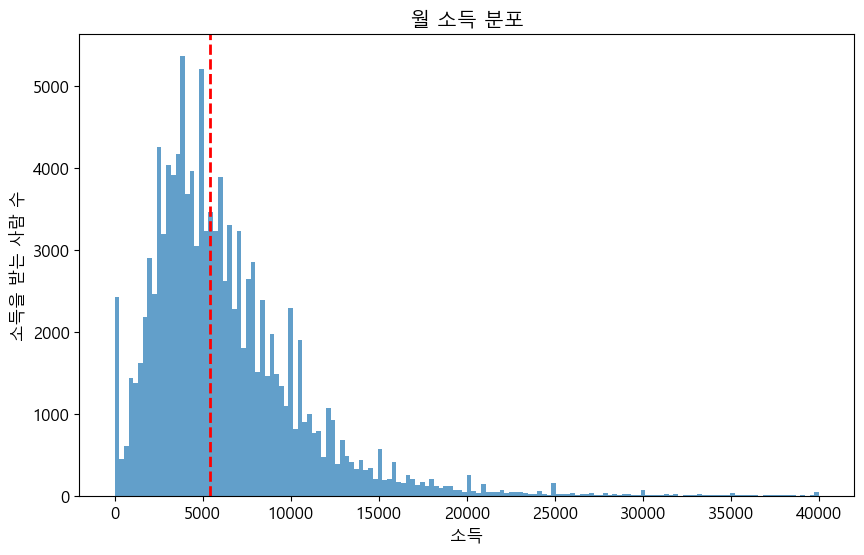

In [8]:
# monthlyincome 분포 히스토그램
# 점선으로 중앙값 표기

plt.rcParams.update({'font.size': 12})

print("월 소득 평균값:", df["monthlyincome"].mean())
print("월 소득 중앙값:", df["monthlyincome"].median())
print("월 소득 최댓값:", df["monthlyincome"].max())
print("월 소득 데이터 수:", df["monthlyincome"].count())
print("월 소득 결측치 수:", df["monthlyincome"].isnull().sum())
print("월 소득 전체 데이터 수", len(df["monthlyincome"]))

plt.figure(figsize=(10, 6))
plt.hist(df["monthlyincome"].dropna(), bins=150, alpha =0.7, range = [0, 0.04e6])
plt.title('월 소득 분포')
plt.xlabel('소득')
plt.ylabel('소득을 받는 사람 수')
plt.axvline(df["monthlyincome"].median(), color='red', linestyle='--', linewidth=2)
plt.show()

### 🔍**히스토그램 분석**
- 왼쪽으로 치우쳐 꼬리가 오른쪽으로 길게 늘어지는 분포 
- 단순히 중앙값으로 채우기에는 너무 단순한 처리

**월 소득은 다른 요소와 관련이 있는 컬럼 (대표적으로 나이)**
> Ex) 2-30대: 사회활동 시작  
> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;4-50대: 커리어 하이  
> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;60대-: 은퇴  

👉 **보다 정확한 전처리를 위해 나이대별로 그룹을 나누고, 각 그룹별 중앙값을 구해 해당 결측치를 나이대에 맞는 중앙값으로 대체**

### 📌 **나이와 소득의 연관성 파악**
- 나이대별 그룹으로 `monthlyincome`의 결측치를 채우려면 우선 나이와 월 소득이 정말로 연관성이 있는지 파악 필요
- 정확한 그룹 분류를 위해 `age`의 이상치 처리

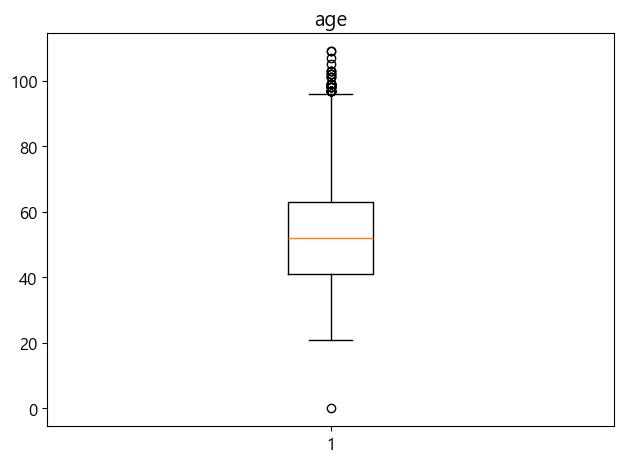

In [9]:
# 이상치 파악을 위한 박스플롯 시각화

plt.boxplot(df['age'])
plt.title('age')

plt.tight_layout()
plt.show()

In [10]:
# age 이상치 개수 및 비율

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 이상치 개수 계산
outliers_lower = (df['age'] < lower).sum()
outliers_upper = (df['age'] > upper).sum()
outliers_total = outliers_lower + outliers_upper

print(f"Lower bound({lower}) 미만 수: {outliers_lower}")
print(f"Upper bound({upper}) 초과 수: {outliers_upper}")
print(f"총 이상치 수: {outliers_total} ({outliers_total/len(df)*100:.2f}%)")

Lower bound(8.0) 미만 수: 1
Upper bound(96.0) 초과 수: 45
총 이상치 수: 46 (0.03%)


#### 📌**Upper bound 처리**
- Upper bound = 96
- 현실적으로 매우 많은 나이
- 그 이상은 극히 드문 케이스  

👉 **Upper bound에 통합**

In [11]:
# 이상치 초과값은 Q3 + 1.5 * IQR으로 통합

df.loc[df['age'] > upper, 'age'] = upper

In [12]:
# Lower bound 값 확인

df[df['age'] == 0]

,seriousdlqin2yrs,revolvingutilizationofunsecuredlines,age,numberoftime30-59dayspastduenotworse,debtratio,monthlyincome,numberofopencreditlinesandloans,numberoftimes90dayslate,numberrealestateloansorlines,numberoftime60-89dayspastduenotworse,numberofdependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


#### 📌**Lower bound 처리**
- 월 소득 6000, 부양 가족 수 2
- 다른 컬럼에서 유의미한 값 존재

👉 **단순 대체보다는 비슷한 값을 가진 행들의 평균(or 중앙값)을 내어 해당 값으로 처리**

In [13]:
# 월 소득이 5000~7000이고 부양 가족 수가 2인 행의 나이 평균

print(df[(df['monthlyincome'] >= 5000) & (df['monthlyincome'] <= 7000) & (df['numberofdependents'] == 2.0)].mean())
print("----------------------------------------------")

# 월 소득이 5000~7000이고 부양 가족 수가 2인 행의 나이 중앙값
print(df[(df['monthlyincome'] >= 5000) & (df['monthlyincome'] <= 7000) & (df['numberofdependents'] == 2.0)].median())

seriousdlqin2yrs                           0.079811
revolvingutilizationofunsecuredlines       5.850153
age                                       45.761039
numberoftime30-59dayspastduenotworse       0.370956
debtratio                                  0.391029
monthlyincome                           5939.203542
numberofopencreditlinesandloans            9.018890
numberoftimes90dayslate                    0.130106
numberrealestateloansorlines               1.172845
numberoftime60-89dayspastduenotworse       0.112633
numberofdependents                         2.000000
dtype: float64
----------------------------------------------
seriousdlqin2yrs                           0.000000
revolvingutilizationofunsecuredlines       0.244854
age                                       45.000000
numberoftime30-59dayspastduenotworse       0.000000
debtratio                                  0.354915
monthlyincome                           6000.000000
numberofopencreditlinesandloans            8.000000
nu

In [14]:
# 나이의 평균과 중앙값이 동일
# 45로 대체

df.loc[df['age'] == 0, 'age'] = 45

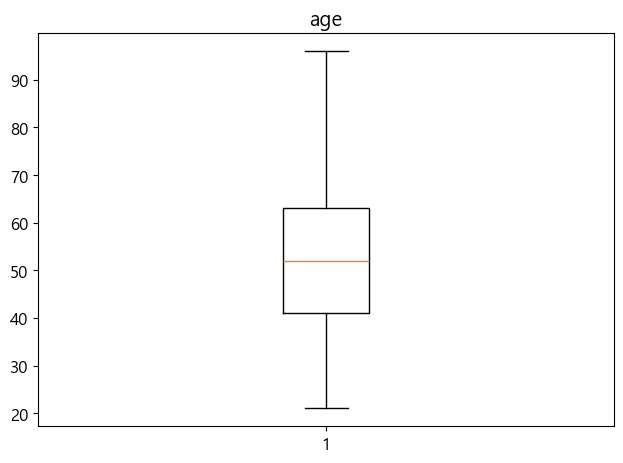

In [15]:
# agd 컬럼 이상치 처리 확인

plt.boxplot(df['age'])
plt.title('age')

plt.tight_layout()
plt.show()

### 📌**나이와 월 소득의 연관성 시각화**

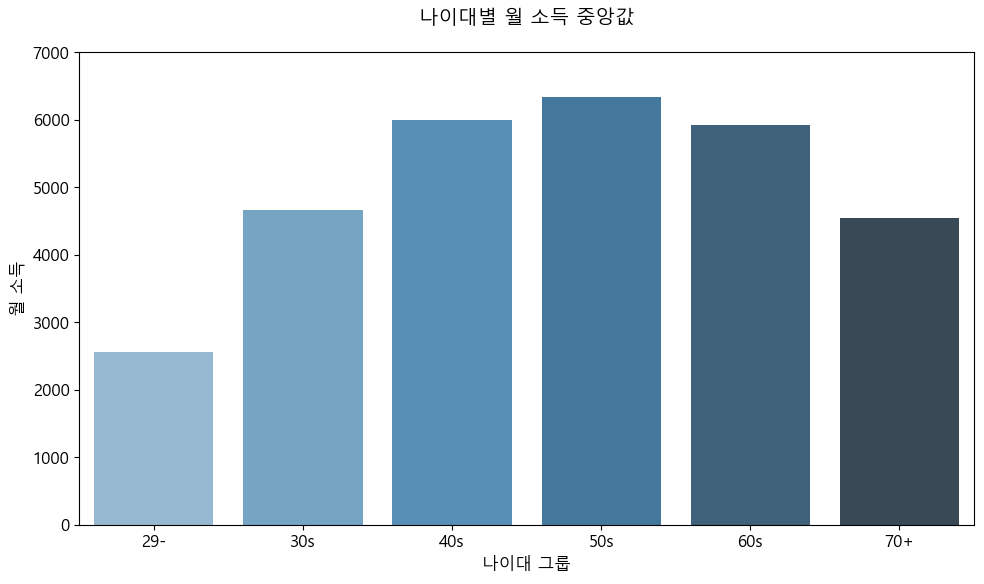

In [16]:
# 나이대 구간화
bins = [0, 29, 39, 49, 59, 69, 120]
labels = ['29-', '30s', '40s', '50s', '60s', '70+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels) # age_group 컬럼 생성

# 나이대별 월 소득 중앙값 계산
median_income = (
    df.groupby('age_group', observed=True)['monthlyincome'].median().reset_index())

# 시각화
plt.figure(figsize=(10, 6))

# 그래프 설정
ax = sns.barplot(
    x='age_group',
    y='monthlyincome',
    hue='age_group',
    data=median_income,
    palette='Blues_d',
    legend=False
)

# 타이틀 및 라벨 설정
plt.title('나이대별 월 소득 중앙값', fontsize=14, pad=20)
plt.xlabel('나이대 그룹', fontsize=12)
plt.ylabel('월 소득', fontsize=12)
plt.ylim(0, 7000)  # y축 여유

plt.tight_layout()
plt.show()

### 🔍**히스토그램 분석**
- 나이와 월 소득은 역U자형 관계임을 확인
- 나이대별 중앙값으로 `monthlyincom` 결측치 처리

In [17]:
# 결측치인 행의 age_group 중앙값으로 채우기

df['monthlyincome'] = df['monthlyincome'].fillna(
    df.groupby('age_group', observed=True)['monthlyincome'].transform('median'))

print("✨ monthlyincom 결측치 처리 완료!")

✨ monthlyincom 결측치 처리 완료!


### 🔍**결측치 처리 방식 결정을 위한 분포 살펴보기**
#### `numberofdependents`

부양가족 수 평균값: 0.7572222678605657
부양가족 수 중앙값: 0.0
부양가족 수 최댓값: 20.0
부양가족 수 데이터 수: 146076
부양가족 수 결측치 수: 3924
부양가족 수 전체 데이터 수 150000


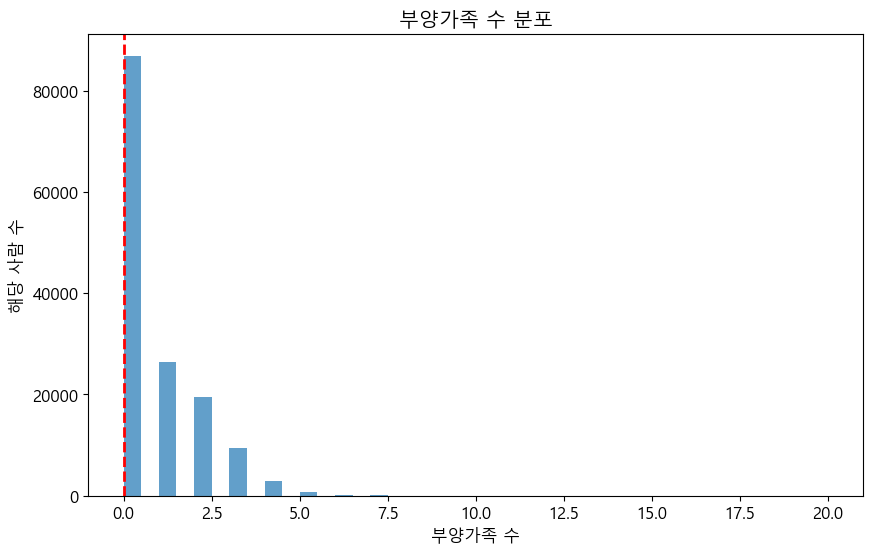

In [18]:
# 부양가족 수 분포 시각화
# 중앙값에 점선 표기

plt.rcParams.update({'font.size': 12})

print("부양가족 수 평균값:", df["numberofdependents"].mean())
print("부양가족 수 중앙값:", df["numberofdependents"].median())
print("부양가족 수 최댓값:", df["numberofdependents"].max())
print("부양가족 수 데이터 수:", df["numberofdependents"].count())
print("부양가족 수 결측치 수:", df["numberofdependents"].isnull().sum())
print("부양가족 수 전체 데이터 수", len(df["numberofdependents"]))

plt.figure(figsize=(10, 6))
plt.hist(df["numberofdependents"].dropna(), bins=40, alpha =0.7, range = [0, df["numberofdependents"].max()])
plt.title('부양가족 수 분포')
plt.xlabel('부양가족 수')
plt.ylabel('해당 사람 수')
plt.axvline(df["numberofdependents"].median(), color='red', linestyle='--', linewidth=2)
plt.show()

### 🔍**히스토그램 분석**
- 왼쪽으로 치우쳐 꼬리가 오른쪽으로 길게 늘어지는 분포 
- 중앙값은 0
- 단순히 중앙값으로 채울 시 데이터 왜곡이 발생할 가능성 O

**부양 가족 수 또한 나이와 관련이 있는 컬럼**
> Ex) 3-40대: 결혼 및 출산(부양 가족 증가)  
> &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;5-60대: 자녀 독립(부양 가족 감소)  

👉 **보다 정확한 전처리를 위해 나이대별로 그룹을 나누고, 각 그룹별 중앙값을 구해 해당 결측치를 나이대에 맞는 중앙값으로 대체**

### 📌 **나이와 부양 가족 수의 연관성 파악**
- 나이대별 그룹으로 `numberofdependents`의 결측치를 채우려면 우선 나이와 월 소득이 정말로 연관성이 있는지 파악 필요

### 📌 **나이와 부양 가족 수의 연관성 시각화**

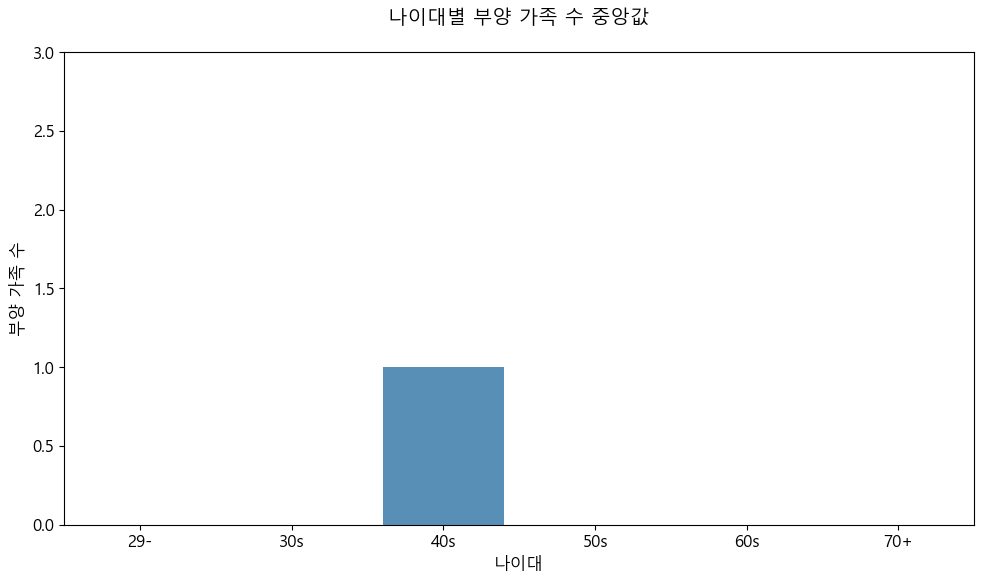

In [19]:
# 나이대별 부양 가족 수 중앙값 계산
median_numberofdependents = (
    df.groupby('age_group', observed=True)['numberofdependents'].median().reset_index())

# 시각화
plt.figure(figsize=(10, 6))

# 그래프 설정
ax = sns.barplot(
    x='age_group',
    y='numberofdependents',
    hue='age_group',
    data=median_numberofdependents,
    palette='Blues_d',
    legend=False
)

# 타이틀 및 라벨 설정
plt.title('나이대별 부양 가족 수 중앙값', fontsize=14, pad=20)
plt.xlabel('나이대', fontsize=12)
plt.ylabel('부양 가족 수', fontsize=12)
plt.ylim(0, 3)

plt.tight_layout()
plt.show()

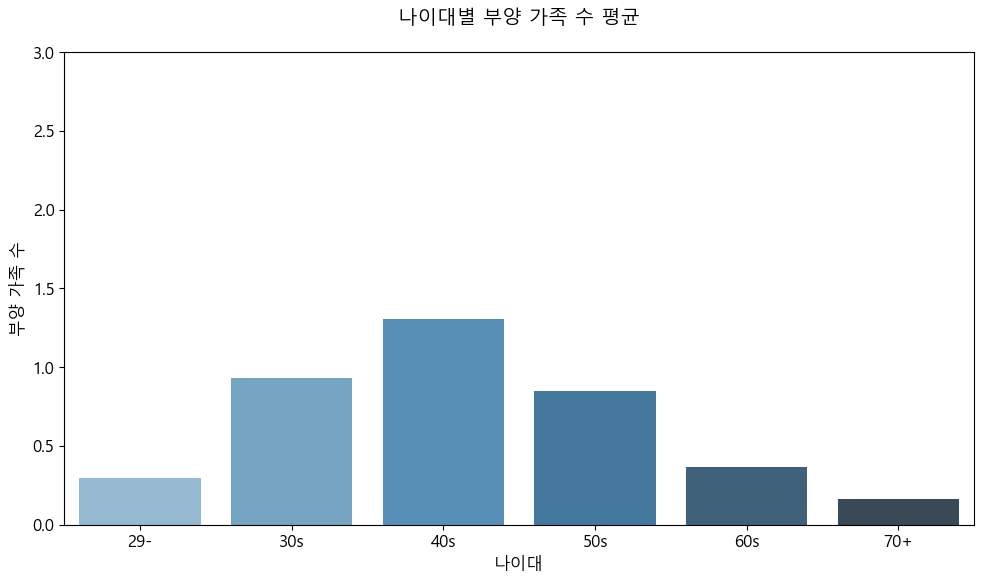

In [20]:
# 예상치 못한 히스토그램 분포
# 평균으로 나타내기

mean_numberofdependents = (
    df.groupby('age_group', observed=True)['numberofdependents'].mean().reset_index())

# 시각화
plt.figure(figsize=(10, 6))

# 그래프 설정
ax = sns.barplot(
    x='age_group',
    y='numberofdependents',
    hue='age_group',
    data=mean_numberofdependents,
    palette='Blues_d',
    legend=False
)

# 타이틀 및 라벨 설정
plt.title('나이대별 부양 가족 수 평균', fontsize=14, pad=20)
plt.xlabel('나이대', fontsize=12)
plt.ylabel('부양 가족 수', fontsize=12)
plt.ylim(0, 3)

plt.tight_layout()
plt.show()

### 🔍**히스토그램 분석**
- 나이와 부양 가족 수가 역U자형 관계임을 확인
- 나이대별 평균으로 `numberofdependents` 결측치 처리
- 중앙값을 사용할 경우 40대를 제외한 모든 그룹에 0 대입 → 데이터 왜곡이 발생할 수 있다.

In [21]:
# 결측치인 행의 age_group 평균으로 채우기
# 실수형 값이 포함되면 안 되므로(인원 수) round 반올림

df['numberofdependents'] = df['numberofdependents'].fillna(
    df.groupby('age_group', observed=True)['numberofdependents'].transform('mean').round())

print("✨ numberofdependents 결측치 처리 완료!")

✨ numberofdependents 결측치 처리 완료!


### 📌**결측치 처리 완료**

In [22]:
# 결측치 처리 확인

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   seriousdlqin2yrs                      150000 non-null  int64   
 1   revolvingutilizationofunsecuredlines  150000 non-null  float64 
 2   age                                   150000 non-null  int64   
 3   numberoftime30-59dayspastduenotworse  150000 non-null  int64   
 4   debtratio                             150000 non-null  float64 
 5   monthlyincome                         150000 non-null  float64 
 6   numberofopencreditlinesandloans       150000 non-null  int64   
 7   numberoftimes90dayslate               150000 non-null  int64   
 8   numberrealestateloansorlines          150000 non-null  int64   
 9   numberoftime60-89dayspastduenotworse  150000 non-null  int64   
 10  numberofdependents                    150000 non-null  f

---

### 📌**이상치 처리**

### 🔍**이상치 파악하기**
- 컬럼별 이상치 개수 및 비율 확인
- 타깃변수와 앞서 전처리한 `age` 제외

In [23]:
# 타깃변수와 나이 컬럼 제외
cols = ['revolvingutilizationofunsecuredlines', 'numberoftime30-59dayspastduenotworse', 'debtratio', 'monthlyincome',
        'numberofopencreditlinesandloans', 'numberoftimes90dayslate', 'numberrealestateloansorlines', 'numberoftime60-89dayspastduenotworse',
        'numberofdependents']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # 이상치 개수 계산
    outliers_lower = (df[col] < lower).sum()
    outliers_upper = (df[col] > upper).sum()
    outliers_total = outliers_lower + outliers_upper

    print(f"\n{col}")
    print(f"Lower bound 미만: {outliers_lower}")
    print(f"Upper bound 초과: {outliers_upper}")
    print(f"총 이상치 수: {outliers_total} ({outliers_total/len(df)*100:.2f}%)")


revolvingutilizationofunsecuredlines
Lower bound 미만: 0
Upper bound 초과: 763
총 이상치 수: 763 (0.51%)

numberoftime30-59dayspastduenotworse
Lower bound 미만: 0
Upper bound 초과: 23982
총 이상치 수: 23982 (15.99%)

debtratio
Lower bound 미만: 0
Upper bound 초과: 31311
총 이상치 수: 31311 (20.87%)

monthlyincome
Lower bound 미만: 0
Upper bound 초과: 8882
총 이상치 수: 8882 (5.92%)

numberofopencreditlinesandloans
Lower bound 미만: 0
Upper bound 초과: 3980
총 이상치 수: 3980 (2.65%)

numberoftimes90dayslate
Lower bound 미만: 0
Upper bound 초과: 8338
총 이상치 수: 8338 (5.56%)

numberrealestateloansorlines
Lower bound 미만: 0
Upper bound 초과: 793
총 이상치 수: 793 (0.53%)

numberoftime60-89dayspastduenotworse
Lower bound 미만: 0
Upper bound 초과: 7604
총 이상치 수: 7604 (5.07%)

numberofdependents
Lower bound 미만: 0
Upper bound 초과: 13336
총 이상치 수: 13336 (8.89%)


#### **출력한 모든 컬럼의 이상치 처리 필요**

### 📌**대출 건수 변수**

#### `numberrealestateloansorlines`
#### `numberofopencreditlinesandloans`

### 📌**더미 변수 생성**
- 부동산 보유 여부
- 집 X - 집 1채의 차이가 집 1채 - n채의 차이보다 크기 때문
- 부동산 보유자 = 주택 담보 대출 가능자/용의자

In [24]:
# 더미 변수 생성
df['realestate_owner'] = (df['numberrealestateloansorlines'] > 0).astype(int)


### 🔍**이상치 처리 방식 결정을 위한 분포 살펴보기**

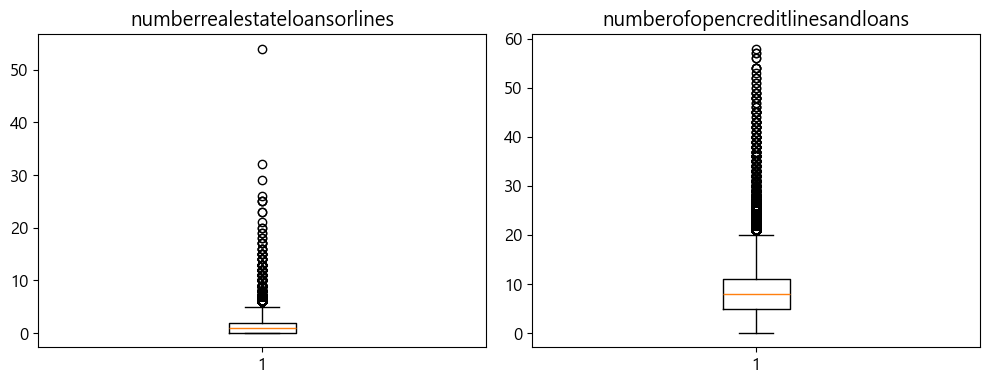

In [25]:
# 대출 건수 변수들 이상치 박스플롯 시각화
# 부동산 대출, 신용 대출

cols = ['numberrealestateloansorlines', 'numberofopencreditlinesandloans']

# 박스플롯 시각화: 한 줄에 3개씩
n = len(cols)
rows = (n + 2) // 3

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

### 🔍**박스플롯 분석**
- 왼쪽으로 치우쳐 꼬리가 오른쪽으로 길게 늘어지는 형태
- 단순 중앙값/평균/최빈값 대체나 상/하한선 대체는 데이터 왜곡을 일으킬 가능성 O

👉 **타깃변수와의 관계 파악 후 처리 방식 결정**

### 📌 **대출 건수별 장기 연체 경험률 시각화**

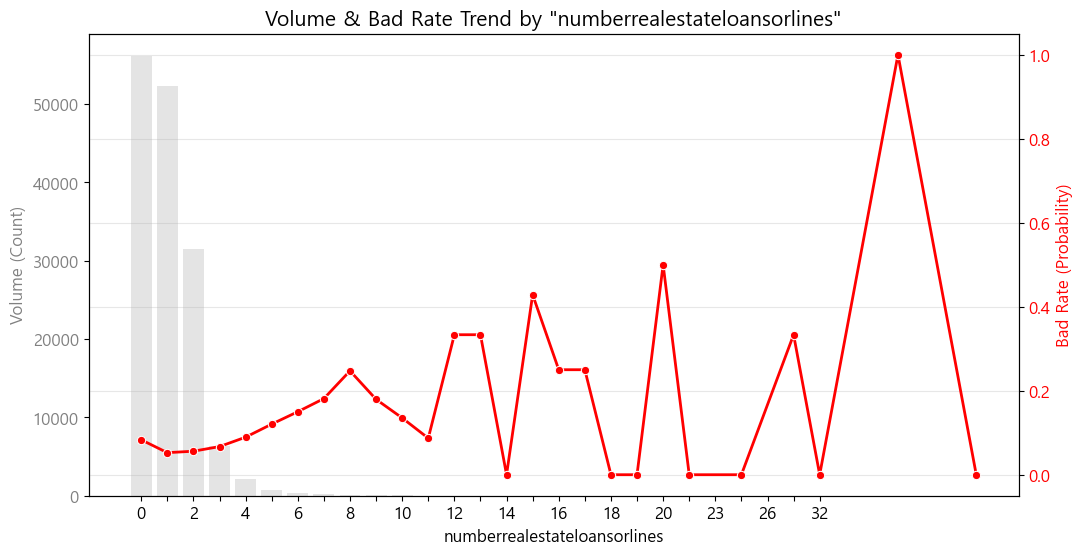

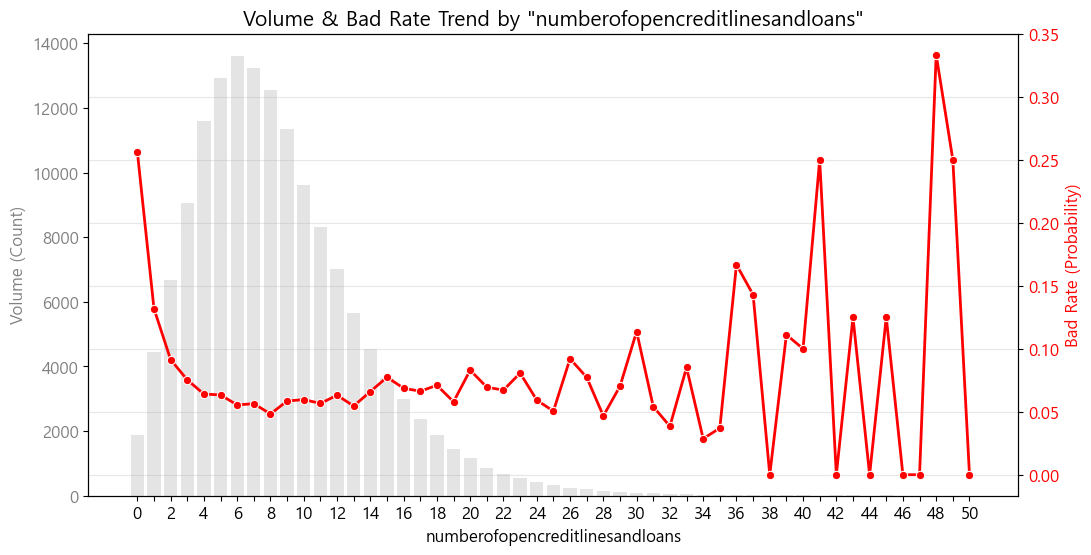

In [26]:
# 타깃과 대출 건수 컬럼의 관계(건수별 장기 연체 경험률)

def plot_bad_rate_trend(df, feature, target='seriousdlqin2yrs', limit=50):
    """
    feature의 값에 따른 데이터 빈도(Bar)와 2년간 90일 이상 연체를 경험할 확률(Line)을 시각화
    Parameters
    - df: 데이터프레임
    - feature: 분석할 변수명
    - target: 타겟 변수명
    - limit: x축 값이 너무 클 경우를 대비해 시각화할 최대값 (기본 50)
    """
    
    # 1. 값별 빈도와 부도율 계산
    stats = df.groupby(feature)[target].agg(['count', 'mean']).reset_index()
    stats.columns = [feature, 'Volume', 'Bad_Rate']
    
    # 시각화 가독성을 위해 limit 이상의 값은 잘라서 보거나, 데이터가 있는 부분만 필터링
    # 여기서는 전체 분포를 보되, 너무 긴 꼬리는 limit으로 자름 (필요시 조정)
    stats = stats[stats[feature] <= limit]

    # 2. 시각화 (이중축 사용)
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Bar plot: 빈도 (Volume)
    sns.barplot(data=stats, x=feature, y='Volume', color='lightgray', alpha=0.6, ax=ax1)
    ax1.set_ylabel('Volume (Count)', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')
    
    # Line plot: 부도율 (Bad Rate)
    ax2 = ax1.twinx()
    sns.lineplot(data=stats, x=feature, y='Bad_Rate', marker='o', color='red', linewidth=2, ax=ax2)
    ax2.set_ylabel('Bad Rate (Probability)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 타이틀 설정
    plt.title(f'Volume & Bad Rate Trend by "{feature}"', fontsize=15)
    plt.grid(True, alpha=0.3)
    
    # X축 레이블이 너무 빽빽하면 조정
    if len(stats) > 20:
        for index, label in enumerate(ax1.get_xticklabels()):
            if index % 2 != 0: # 홀수번째 레이블 숨김
                label.set_visible(False)
                
    plt.show()


# 부동산 대출 건수 확인
plot_bad_rate_trend(df, 'numberrealestateloansorlines')

# 신용 대출 건수 확인
plot_bad_rate_trend(df, 'numberofopencreditlinesandloans')

### 🔍**시각화 분석**
`numberrealestateloansorlines`
- 0에서 8까지 장기 연체 경험률(빨간 선)이 우상향 → 대출이 많을수록 위험함을 의미  

👉 **로그 변환 적용**  
👉 **건수별 순서 차이는 유지하되 간격을 좁혀주므로, 꼬리 부분의 영향력을 줄이면서 많을수록 위험하다는 정보는 보존**

`numberofopencreditlinesandloans`
- 0일 때 부도율이 오히려 높고 10 근처까지 안정적
- 20 이후부터 장기 연체 경험률(빨간 선)이 널뛰기 시작  

👉 **캡핑(Capping) 적용**  
👉 **빨간 선이 널뛰기 시작하는 지점에서 상한선을 설정해 묶기 → 모델이 노이즈에 과적합되는 것을 방지**  

### 📌**이상치 처리**

In [27]:
# numberrealestateloansorlines - 로그 변환
# 로그 변환하는 값에 0이 포함되어 있으므로 log1p 사용

df['numberrealestateloansorlines'] = np.log1p(df['numberrealestateloansorlines'])

# numberofopencreditlinesandloans - 20에서 캡핑
df['numberofopencreditlinesandloans'] = df['numberofopencreditlinesandloans'].clip(upper = 20)

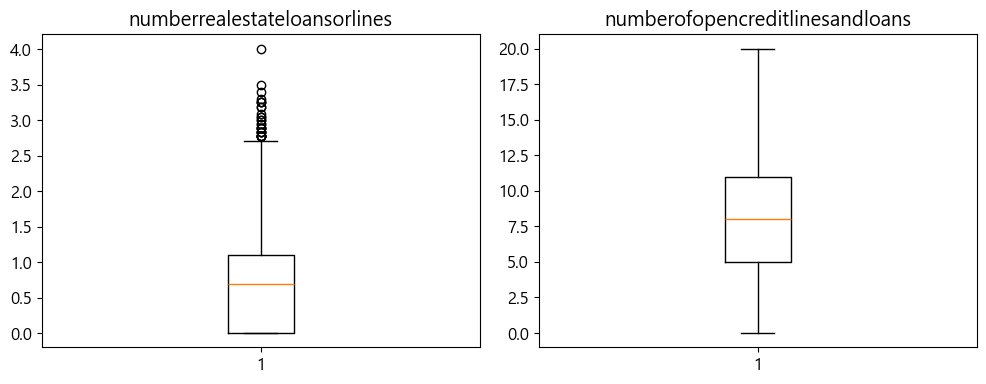

In [28]:
# 대출 건수 변수들 이상치 처리 확인

cols = ['numberrealestateloansorlines', 'numberofopencreditlinesandloans']

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

---

### 📌**연체 횟수 변수**

#### `numberoftimes90dayslate`
#### `numberoftime60-89dayspastduenotworse`
#### `numberoftime30-59dayspastduenotworse`

### 🔍**이상치 처리 방식 결정을 위한 분포 살펴보기**

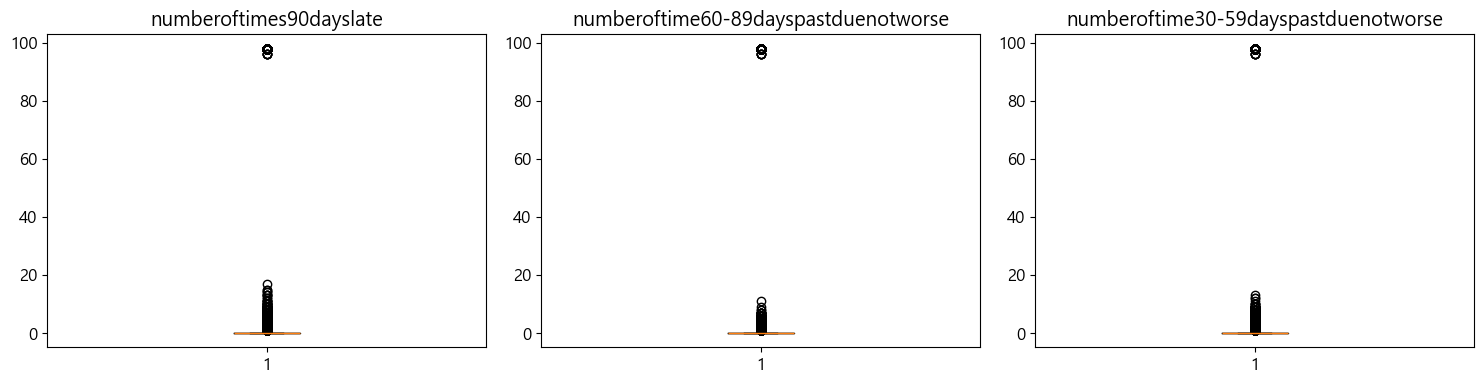

In [29]:
# 연체 횟수 변수들 이상치 박스플롯 시각화
# 90일 이상 연체 횟수, 최근 2년간 60-89일 연체 횟수, 최근 2년간 30-59일 연체 횟수

cols = [
    'numberoftimes90dayslate',
    'numberoftime60-89dayspastduenotworse',
    'numberoftime30-59dayspastduenotworse']

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

### 🔍**박스플롯 분석**
- 세 연체 변수 모두 대부분의 값이 20회 이내로 모여 있으며, 100에 가깝게 떠있는 값들이 존재
- 단순한 오류와 이상치라기엔 세 변수에서 공통적으로 나타나는 분포

👉 **극단값 정체 파악 후 이상치 처리**

In [30]:
# 연체 변수 횟수 값 확인

display(df['numberoftimes90dayslate'].value_counts().sort_index())
display(df['numberoftime60-89dayspastduenotworse'].value_counts().sort_index())
display(df['numberoftime30-59dayspastduenotworse'].value_counts().sort_index())

numberoftimes90dayslate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

numberoftime60-89dayspastduenotworse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

numberoftime30-59dayspastduenotworse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

### 📌 **96, 98이 공통적으로 존재**
- 과연 단순 오류일까?
- 아니면 무언가를 나타내는 표시일까?

### 🔍**이상치 파악하기**
- 타깃변수와의 관계 확인
- 진짜로 연체를 많이 한 사람들(5~20회)과 96, 98 값을 가진 사람들의 2년간 90일 이상 연체를 경험할 확률(장기연체 경험률) 비교

In [31]:
# 함수 생성

def check_special_codes(df, target='seriousdlqin2yrs'):
    # 분석할 연체 관련 변수 3개
    delinq_cols = [
        'numberoftimes90dayslate', 
        'numberoftime60-89dayspastduenotworse', 
        'numberoftime30-59dayspastduenotworse'
    ]
    
    for col in delinq_cols:
        print(f"\n[{col}] 분석 결과:")
        print("-" * 50)
        
        # 그룹 정의
        # 1. 정상 범위 내 고위험군 (5회 ~ 19회 사이)
        normal_high = df[(df[col] >= 5) & (df[col] < 20)]
        
        # 2. 특수 값 96
        code_96 = df[df[col] == 96]
        
        # 3. 특수 값 98
        code_98 = df[df[col] == 98]
        
        # 결과 출력용 데이터 프레임 생성
        summary = pd.DataFrame({
            'Group': ['Normal High (5~19)', 'Code 96', 'Code 98'],
            'Count': [len(normal_high), len(code_96), len(code_98)],
            'Bad_Rate': [
                normal_high[target].mean(), 
                code_96[target].mean(), 
                code_98[target].mean()
            ]
        })
        
        # 소수점 4째자리까지 나오게 포매팅
        pd.options.display.float_format = '{:.4f}'.format
        print(summary)
        print("-" * 50)

check_special_codes(df)


[numberoftimes90dayslate] 분석 결과:
--------------------------------------------------
                Group  Count  Bad_Rate
0  Normal High (5~19)    313    0.6518
1             Code 96      5    0.8000
2             Code 98    264    0.5417
--------------------------------------------------

[numberoftime60-89dayspastduenotworse] 분석 결과:
--------------------------------------------------
                Group  Count  Bad_Rate
0  Normal High (5~19)     63    0.6349
1             Code 96      5    0.8000
2             Code 98    264    0.5417
--------------------------------------------------

[numberoftime30-59dayspastduenotworse] 분석 결과:
--------------------------------------------------
                Group  Count  Bad_Rate
0  Normal High (5~19)    581    0.4716
1             Code 96      5    0.8000
2             Code 98    264    0.5417
--------------------------------------------------


### 🔍**결과 분석**
- Code 96 (N = 5): 표본은 적지만 부도율 80%. 사실상 부도 확정에 가까운 초고위험군
- Code 98 (N = 264): 부도율 약 54%

👉**더미변수 생성 후 캡핑**  
👉**위 변수들은 단순한 오류가 아닌 숫자 정보 + 상태 코드가 섞여 있는 형태로 결론**  
👉**따라서 더미 변수로 정보를 분리한 후 이상치 처리**

### 📌**이상치 처리**
- 96: 표본이 매우 적어 더미로 바꿀 시 왜곡 가능성 O  
&nbsp;&nbsp;&nbsp;→ 장기 연체 경험률 80%로 매우 높으므로 최대값으로 변환(최대값과 동일한 결과를 내는 값으로 판단)  
- 98: 데이터가 264개로 충분하므로 `Is_98` 더미 변수 생성  
&nbsp;&nbsp;&nbsp;→ 최대값으로 변환  
👉 **연체 횟수 변수의 중앙값이 모두 0**  
👉 **98을 중앙값으로 바꾸면 더미 변수의 의미가 틀어질 수 있음**  
👉 **일단 고위험군으로 두고 더미 변수가 조정하게 만드는 쪽이 나음**  

In [32]:
# 연체 횟수 변수 이상치 처리
# 함수 생성

def process_special_codes(df):
    # 처리할 3개의 변수 리스트
    cols = [
        'numberoftimes90dayslate', 
        'numberoftime60-89dayspastduenotworse', 
        'numberoftime30-59dayspastduenotworse'
    ]
    
    for col in cols:
        # 더미 변수 생성 (Code 98 여부)
        # 98인 경우 1, 아니면 0. 컬럼명은 'is_98_원본컬럼명' 형태
        df[f'is_98_{col}'] = (df[col] == 98).astype(int)
        
        # 캡핑을 위한 96, 98 제외한 데이터 중 최대값 구하기
        normal_max = df.loc[df[col] < 90, col].max()
        
        # 값 변환
        # 96과 98을 모두 normal_max로 변환
        df[col] = df[col].apply(lambda x: normal_max if x >= 96 else x)
        
    return df

df = process_special_codes(df)

# 확인: 96, 98이 사라지고 정상 범위 내로 들어왔는지, 더미변수는 잘 생성됐는지 확인
print("처리 완료 후 통계:")
check_cols = ['numberoftimes90dayslate', 'numberoftime60-89dayspastduenotworse', 
        'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate']
print(df[check_cols].describe())

처리 완료 후 통계:
       numberoftimes90dayslate  numberoftime60-89dayspastduenotworse  \
count              150000.0000                           150000.0000   
mean                    0.1208                                0.0844   
std                     0.8644                                0.5682   
min                     0.0000                                0.0000   
25%                     0.0000                                0.0000   
50%                     0.0000                                0.0000   
75%                     0.0000                                0.0000   
max                    17.0000                               11.0000   

       numberoftime30-59dayspastduenotworse  is_98_numberoftimes90dayslate  
count                           150000.0000                    150000.0000  
mean                                 0.2687                         0.0018  
std                                  0.8816                         0.0419  
min                            

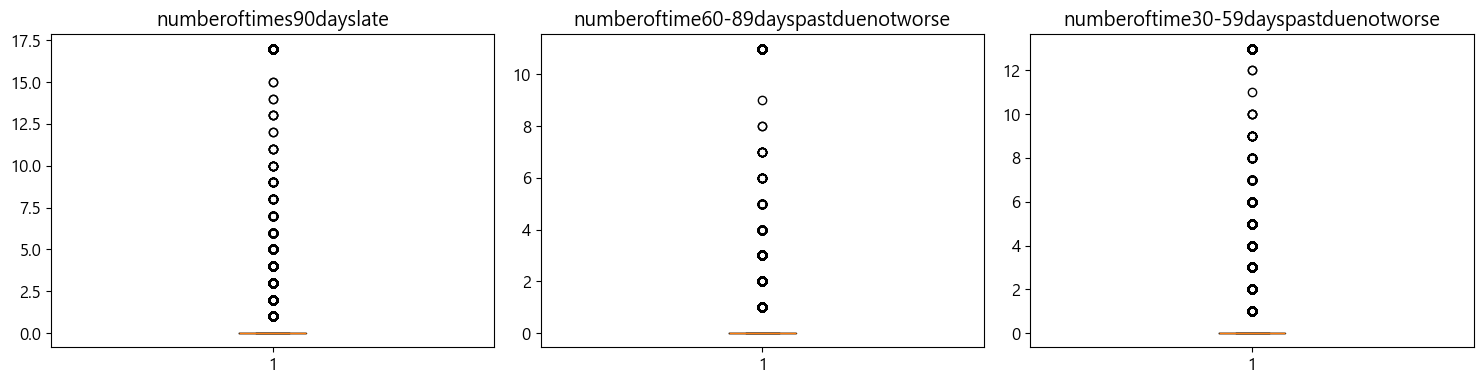

In [33]:
# 연체 횟수 변수들 이상치 처리 확인

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

---

### 📌**월 소득**
#### `monthlyincome`

### 🔍**이상치 처리 방식 결정을 위한 분포 살펴보기**

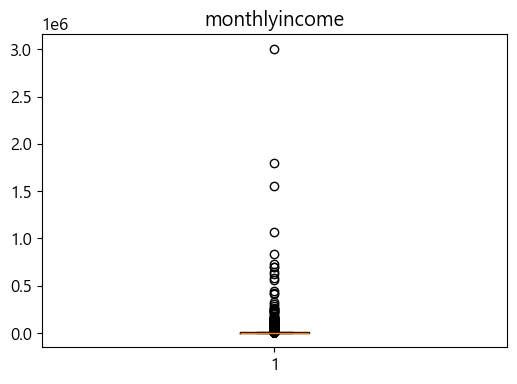

In [34]:
# monthlyincome 이상치 확인
cols = ['monthlyincome']

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

### 🔍**박스플롯 분석**
- 왼쪽으로 치우쳐 꼬리가 오른쪽으로 길게 늘어지는 형태
- 중앙값과 상/하한선값이 0이기 때문에 단순 대체는 데이터 왜곡을 일으킬 가능성 O

👉 **Winsorising 또는 로그 변환**
- **Winsorising**: 극값을 자름으로써 소득이라는 극값에 민감한 변수 성질을 완화
- **로그 변환**: 분포는 그대로 살리면서 값의 크기만 줄여 원본대로 파악하기 용이

### 📌 **Winsorising과 로그 변환의 경우 `monthlyincome` 분포 비교**

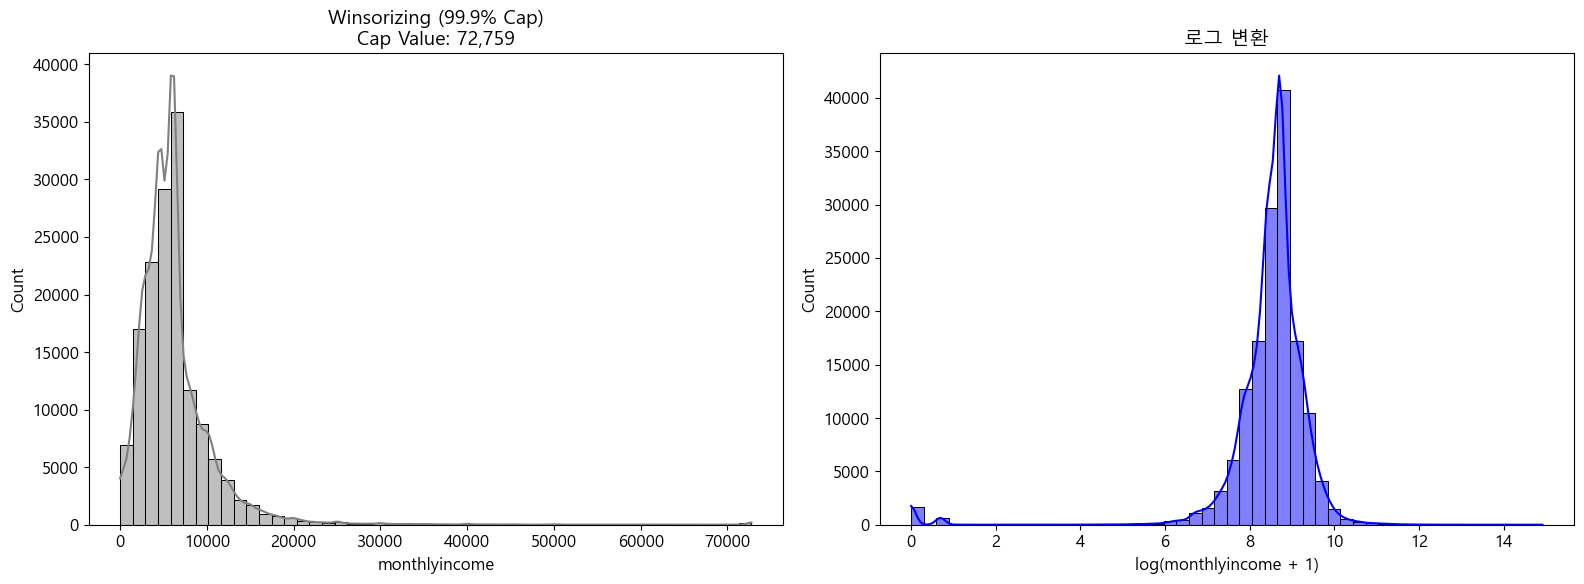

In [35]:
# 함수 생성

def compare_income_transformations(df, col='monthlyincome'):
    # 원본 데이터 추출
    data = df[col].dropna()
    
    # 윈저라이징 (99.9%)
    upper_limit = data.quantile(0.999)
    winsorized_data = data.clip(upper=upper_limit)
    
    # 로그 변환 (0이 있어도 계산 가능하도록 log(x+1) 적용)
    log_data = np.log1p(data)

    # 시각화 설정
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # [왼쪽] 윈저라이징 분포
    sns.histplot(winsorized_data, bins=50, kde=True, ax=axes[0], color='gray')
    axes[0].set_title(f'Winsorizing (99.9% Cap)\nCap Value: {upper_limit:,.0f}', fontsize=14)
    axes[0].set_xlabel('monthlyincome')
    
    # [오른쪽] 로그 변환 분포
    sns.histplot(log_data, bins=50, kde=True, ax=axes[1], color='blue')
    axes[1].set_title('로그 변환', fontsize=14)
    axes[1].set_xlabel('log(monthlyincome + 1)')
    
    plt.tight_layout()
    plt.show()

# 실행
compare_income_transformations(df)

### 🔍**시각화 분석**
- **Winsorising**
    - 0 근처에 대부분의 데이터가 몰려있고 오른쪽으로 꼬리가 긴 형태
    - 여전히 극값에 민감해보임
- **로그 변환**
    - 저소득층-중산층-고소득층의 분포로 잘 나타남

👉 **로그 변환으로 결정**  
**+ 0값의 경우 단순 무소득 또는 특수한 경우일 수 있으므로 더미 변수 생성**

### 📌 **이상치 처리**

In [36]:
# monthlyincome 이상치 처리
# 0 더미 변수 생성
# 로그 변환

def process_income_final(df, col='monthlyincome'):
    # 더미 변수 생성 (무소득 or 특수한 경우의 정보를 남김)
    df[f'is_zero_{col}'] = (df[col] == 0).astype(int)
    
    # 로그 변환 (Log1p)
    df[col] = np.log1p(df[col])
    
    return df

df = process_income_final(df)

# 이상치 처리된 monthlyincome과 더미 변수 값 확인
print(df[['monthlyincome', 'is_zero_monthlyincome']].head())

   monthlyincome  is_zero_monthlyincome
0         9.1183                      0
1         7.8637                      0
2         8.0206                      0
3         8.1020                      0
4        11.0602                      0


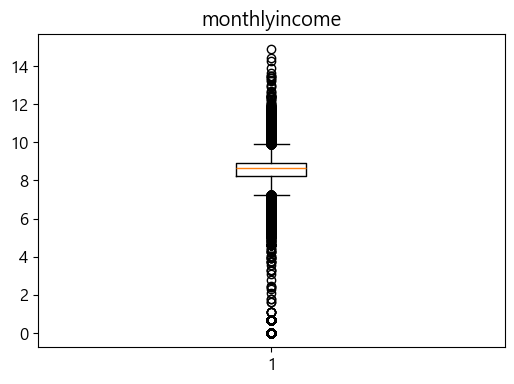

In [37]:
# monthlyincome 이상치 처리 확인

cols = ['monthlyincome']

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

---

### 📌**부양 가족 수**
#### `numberofdependents`

### 🔍**이상치 처리 방식 결정을 위한 분포 살펴보기**

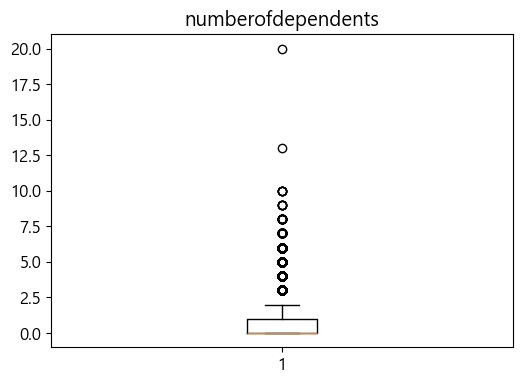

In [38]:
# numberofdependents 이상치 확인

cols = ['numberofdependents']

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

### 🔍**박스플롯 분석**
- 왼쪽으로 치우쳐 꼬리가 오른쪽으로 길게 늘어지는 형태
- 중앙값이 0이기 때문에 단순 대체는 데이터 왜곡을 일으킬 가능성 O

👉 **다인 가정의 현실적 경우의 수 고려**  
👉 **논리적 뒷받침을 위한 타깃변수와의 관계 파악**

### 📌 **부양 가족 수가 이상치인 행들의 값별 개수 확인**
- 이상치 중 입력 오류가 아닌 현실적인 입력값도 존재할 것

In [39]:
# 부양 가족 수가 이상치인 행들의 값별 개수 확인

df[df['numberofdependents'] >= 3]['numberofdependents'].value_counts().sort_index()

numberofdependents
3.0000     9483
4.0000     2862
5.0000      746
6.0000      158
7.0000       51
8.0000       24
9.0000        5
10.0000       5
13.0000       1
20.0000       1
Name: count, dtype: int64

### 📌 **부양 가족 수별 2년간 90일 이상 연체 경험률**

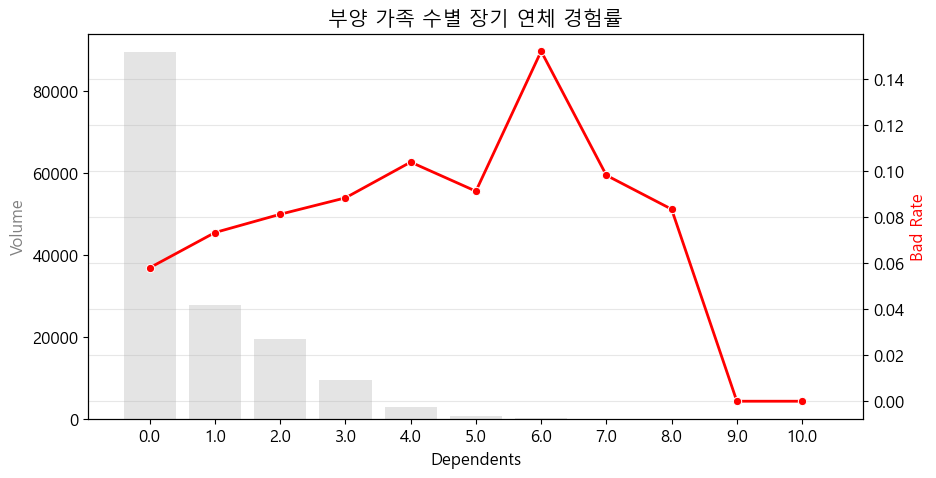

In [40]:
# 함수 생성

def check_dependents_cap(df, target='seriousdlqin2yrs'):
    # 부양가족 수 별 집계 (10명까지 고려. 그 이상은 극히 드문 케이스)
    # 10명 이상은 10으로 묶어서 시각화
    temp_df = df.copy()
    temp_df['dependents_view'] = temp_df['numberofdependents'].clip(upper=10)
    
    stats = temp_df.groupby('dependents_view')[target].agg(['count', 'mean']).reset_index()
    stats.columns = ['Dependents', 'Volume', 'Bad_Rate']
    
    # 2. 시각화
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # 막대: 데이터 개수
    sns.barplot(data=stats, x='Dependents', y='Volume', color='lightgray', alpha=0.6, ax=ax1)
    ax1.set_ylabel('Volume', color='gray')
    
    # 선: 장기 연체 경험률
    ax2 = ax1.twinx()
    sns.lineplot(data=stats, x='Dependents', y='Bad_Rate', marker='o', color='red', linewidth=2, ax=ax2)
    ax2.set_ylabel('Bad Rate', color='red')
    
    plt.title('부양 가족 수별 장기 연체 경험률')
    plt.grid(True, alpha=0.3)
    plt.show()

check_dependents_cap(df)

### 🔍**시각화 분석**
- 4 다음부터 빈도 수가 줄어들고 값이 널뛰기를 함
- 0, 1, 2, 3, 4, 5+ 라는 순서를 보존하여 로짓 모델의 경향성 학습을 가능케 함

👉 **부양 가족 수 3, 4는 그대로(3/4인 가정의 경우)**  
👉 **5 이상은 5로 통합**  

### 📌**이상치 처리**

In [41]:
# 이상치 처리

df.loc[(df['numberofdependents'] >= 5), 'numberofdependents'] = 5

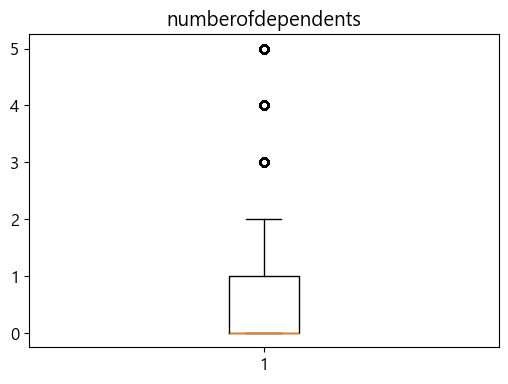

In [42]:
# numberofdependents 이상치 처리 확인
cols = ['numberofdependents']

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

---

### 📌**비율 변수**

#### `revolvingutilizationofunsecuredlines`
#### `debtratio`

### 🔍**이상치 처리 방식 결정을 위한 분포 살펴보기**

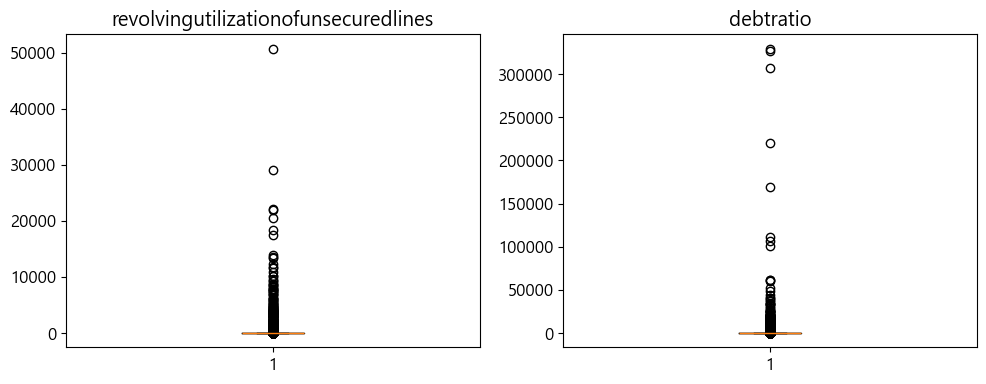

In [43]:
# 비율 변수들 이상치 확인
# 신용한도 대비 사용률, 부채 비율(월간 부채 상환액, 생활비 /월 총수입)

cols = ['revolvingutilizationofunsecuredlines', 'debtratio']

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

### 🔍**박스플롯 분석**
- 확률 변수임에도 불구하고 월 소득처럼 치솟는 이상치
- 이상한 경우
    - `revolvingutilizationofunsecuredlines`  
    한도가 0인 카드를 썼거나 이미 연체가 시작되어 이자가 원금을 덮친 깡통 계좌일 가능성
    - `debtratio`  
    소득이 0이거나 결측인 경우 시스템이 비율을 계산 못 해서 부채 총액을 그대로 집어넣었을 경우

👉 **데이터 성질 파악 후 결정**  

### 📌 **확률 변수의 성질 파악하기**
- `revolvingutilizationofunsecuredlines`  
    - 로그 변환을 적용한 후의 분포 모양  
    - 로그 변환만으로 충분한지, 이상치를 잘라내야 할지 판단  
    👉 **꼬리가 깔끔하게 떨어지면 → 로그 변환**  
    👉 **로그를 해도 꼬리가 긴 경우 → 캡핑 후 로그**

- `debtratio`
    - 소득이 있는 그룹과 소득이 없는 그룹의 부채비율 평균  
    - 이상치들이 정말로 높은 확률인지, 소득이 0으로 찍혀 발생한 현상인지 파악  
    👉 **단순한 극값 자르기가 아닌 로그 변환 + 소득유무 더미 변수를 같이 사용하는 전략을 확정 짓기 위함**

=== 소득 유무에 따른 부채비율(debtratio) 평균 비교 ===
                     mean         max      50%
income_status                                 
Normal Income   1573.5673  60212.0000 930.0000
Zero/NaN Income  339.5627 329664.0000   0.3625


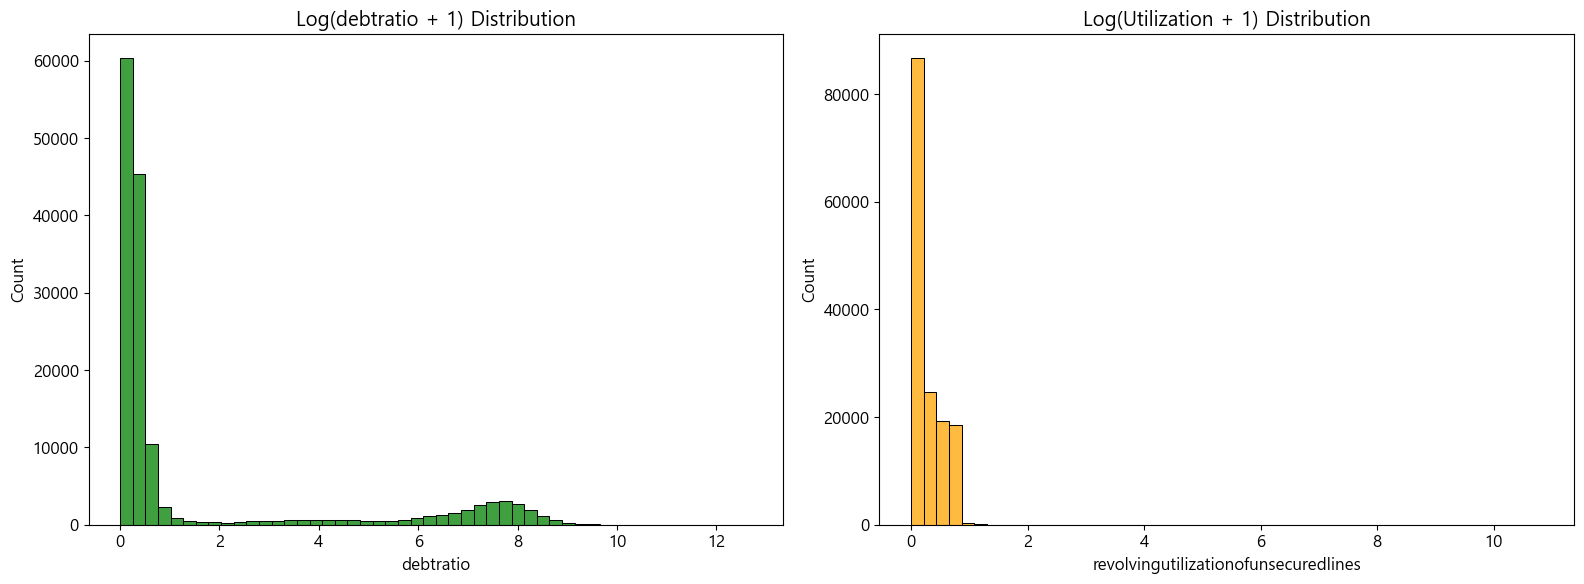

In [44]:
# 함수 생성

def analyze_extreme_variables(df):
    # debtratio
    # 소득이 0(또는 결측)인 사람과 아닌 사람 구분
    # 앞서 만든 소득 0 더미변수 활용
    temp_df = df.copy()
    temp_df['income_status'] = np.where(temp_df['is_zero_monthlyincome'] == 0, 'Zero/NaN Income', 'Normal Income')
    
    print("=== 소득 유무에 따른 부채비율(debtratio) 평균 비교 ===")
    print(temp_df.groupby('income_status')['debtratio'].describe()[['mean', 'max', '50%']])
    
    # 로그 변환 후 분포 시각화 (두 변수 모두)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # debtratio
    # 0이 있을 수 있으므로 log1p 사용
    sns.histplot(np.log1p(temp_df['debtratio']), bins=50, ax=axes[0], color='green')
    axes[0].set_title('Log(debtratio + 1) Distribution')
    
    # Utilization Log
    # 0이 있을 수 있으므로 log1p 사용
    sns.histplot(np.log1p(temp_df['revolvingutilizationofunsecuredlines']), bins=50, ax=axes[1], color='orange')
    axes[1].set_title('Log(Utilization + 1) Distribution')
    
    plt.tight_layout()
    plt.show()

analyze_extreme_variables(df)

### 🔍**시각화 분석**

`debtratio`
- Normal Income: 중앙값 0.29 (소득의 약 30%가 부채. 정상 범주)
- Zero/NaN Income: 중앙값 1,144 (소득의 1100배 부채. 비정상적 수치)  
    → 같은 변수 안에 있는 다른 차원의 데이터
- 시각적 근거
    - 히스토그램상 두 개의 봉우리가 관측
    - 좌측 봉우리: 정상 소득자 그룹
    - 우측 봉우리: 무소득 그룹  

👉 **별도의 캡핑(Capping)이나 데이터 분리 불필요**  
👉 **기존에 생성한 `is_zero_income` 더미 변수와 로그 변환의 조합으로 해결**

`RevolvingUtilization`
- 로그 변환 후에도 극단적인 이상치가 잔존하여 모델 왜곡 가능성 O
- 시각적 근거
    * 대다수 데이터는 $0 \sim 2$ 구간에 밀집
    * 로그 변환 후에도 $x=10$ 근처까지 데이터가 길게 늘어짐
* 통계적 근거
    * 로그 값 $2.5 \sim 3.0$ (원래 값 약 10~20배) 이후로는 데이터 밀도가 희박  

👉 **캡핑 후 로그**  
👉 **원래 값 기준 10 지점에서 캡핑 적용 후 로그 변환을 수행하여 분포 안정화**

### 📌**이상치 처리**

In [45]:
# 함수 생성

def process_ratios_final(df):
    # debtratio 로그 변환만 적용
    df['debtratio'] = np.log1p(df['debtratio'])
    
    # revolvingutilizationofunsecuredlines 극단적 이상치 캡핑 후 로그 변환
    # 원래 값 10 정도면 이미 파산 상태이므로 그 이상은 10으로 퉁침
    limit_val = 10  # 시각적 근거에 의한 상한선
    df['revolvingutilizationofunsecuredlines'] = df['revolvingutilizationofunsecuredlines'].clip(upper=limit_val)
    df['revolvingutilizationofunsecuredlines'] = np.log1p(df['revolvingutilizationofunsecuredlines'])
    
    return df

df = process_ratios_final(df)

# revolvingutilizationofunsecuredlines의 꼬리가 잘렸는지 확인
print(df[['revolvingutilizationofunsecuredlines', 'debtratio']].describe())

       revolvingutilizationofunsecuredlines   debtratio
count                           150000.0000 150000.0000
mean                                 0.2499      1.5252
std                                  0.2644      2.6272
min                                  0.0000      0.0000
25%                                  0.0294      0.1613
50%                                  0.1434      0.3123
75%                                  0.4441      0.6250
max                                  2.3979     12.7058


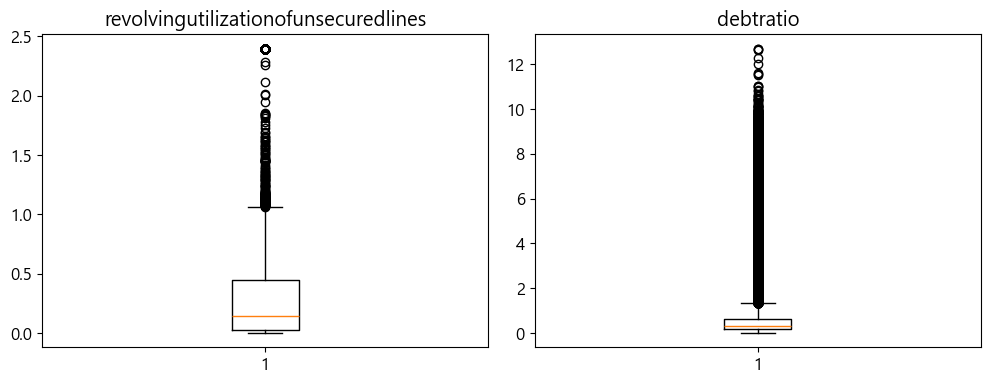

In [46]:
# 확률 변수 이상치 처리 확인

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

---

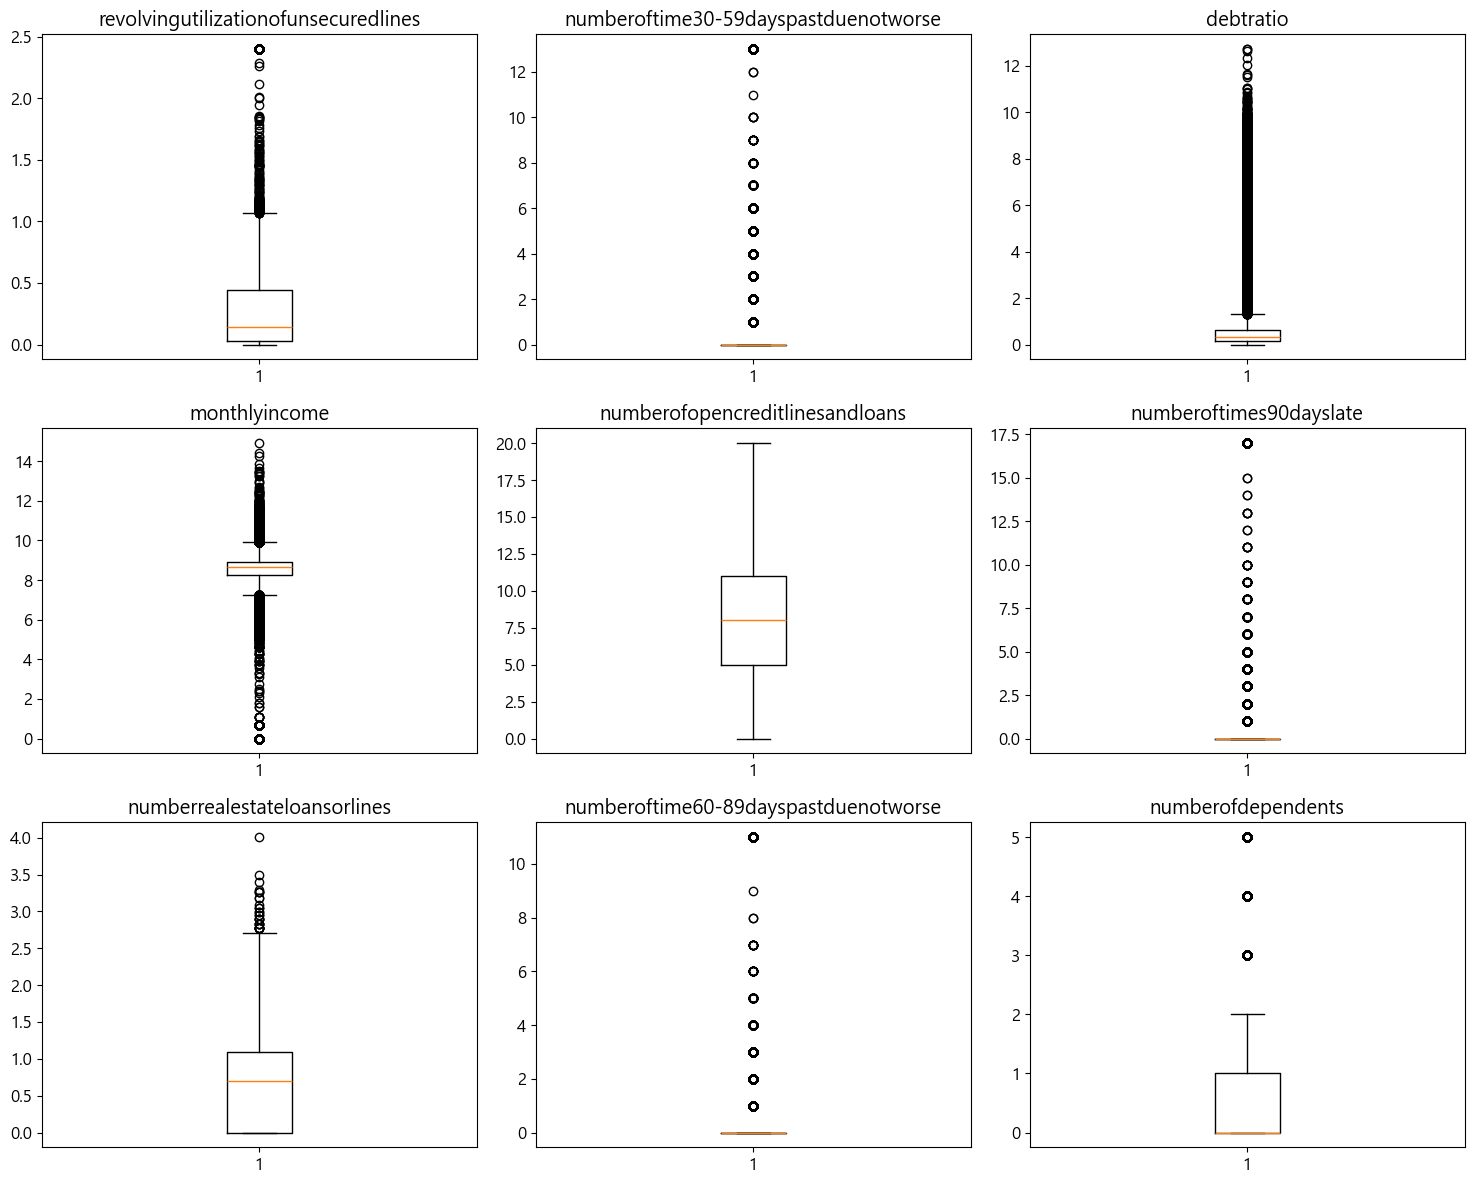

In [47]:
# 이상치 전체 처리 시각화

cols = ['revolvingutilizationofunsecuredlines', 'numberoftime30-59dayspastduenotworse', 'debtratio', 'monthlyincome',
        'numberofopencreditlinesandloans', 'numberoftimes90dayslate', 'numberrealestateloansorlines', 'numberoftime60-89dayspastduenotworse',
        'numberofdependents']

# 한 줄에 3개씩
n = len(cols)
rows = (n + 2) // 3

plt.figure(figsize=(15, rows * 4))
for i, col in enumerate(cols, 1):
    plt.subplot(rows, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(col)

plt.tight_layout()
plt.show()

In [48]:
# 나이대 컬럼 삭제

df = df.drop('age_group', axis=1)

---

## **3. BIC 최적화** 

### 📌**변수 선택 기법 함수 정의**
- stepwise
- forward
- backward

In [49]:
# stepwise 함수 생성

# 함수 생성
def stepwise_bic(X, y, verbose = True):
    # 선택된 변수 담을 리스트
    selected_vars = []
    # 아직 선택 안 된 나머지 변수들
    remaining_vars = list(X.columns)
    # 비교할 BIC 기준값 (처음엔 무조건 작아져야 하므로 무한대에 설정)
    current_bic = float('inf')

    while True:
        # 변수 추가/제거 여부 체크하는 변수
        changed = False

        # 남은 변수 중 하나를 넣었을 때 BIC가 줄어드는지(Forward)
        best_add_bic = current_bic
        best_add_var = None

        for var in remaining_vars:
            try:
                # 기존 선택에 변수(var) 하나 추가하여 테스트
                test_vars = selected_vars + [var]

                # 상수항 추가
                X_test = sm.add_constant(X[test_vars])

                # 로지스틱 회귀
                model = sm.Logit(y, X_test).fit(disp=0)

                # BIC가 더 작게 나오면 갱신
                if model.bic < best_add_bic:
                    best_add_bic = model.bic
                    best_add_var = var
            except:
                pass  # 에러 나면 패스

        # 찾은 변수가 존재하고 BIC가 더 최적화될 경우 리스트에 추가
        if best_add_var is not None and best_add_bic < current_bic:
            selected_vars.append(best_add_var)
            remaining_vars.remove(best_add_var)
            current_bic = best_add_bic
            changed = True

            if verbose:
                print(f"[추가] {best_add_var} (BIC: {current_bic:.3f})")

        # 이미 들어간 것 중 제외했을 때 BIC가 더 줄어드는지 (Backward)
        best_remove_bic = current_bic
        best_remove_var = None

        # 변수가 2개 이상일 때만 추출 가능
        if len(selected_vars) > 1:
            for var in selected_vars:
                try:
                    # var를 빼고 나머지 변수만 사용
                    test_vars = [v for v in selected_vars if v != var]

                    X_test = sm.add_constant(X[test_vars])

                    # 로지스틱 회귀
                    model = sm.Logit(y, X_test).fit(disp=0)

                    # 제외하고 BIC가 더 작아지면 기록
                    if model.bic < best_remove_bic:
                        best_remove_bic = model.bic
                        best_remove_var = var
                except:
                    pass

        # 뺄 변수가 존재하고 BIC가 좋아졌으면 리스트에서 제거
        if best_remove_var is not None and best_remove_bic < current_bic:
            selected_vars.remove(best_remove_var)
            remaining_vars.append(best_remove_var)
            current_bic = best_remove_bic
            changed = True

            if verbose:
                print(f"[제거] {best_remove_var} (BIC: {current_bic:.3f})")

        # 추가도 제거도 없으면 반복문 종료
        if changed == False:
            if verbose:
                print("최적화 종료")
            break

    return selected_vars, current_bic

In [50]:
# forward 함수 생성

def forward_bic(X, y, verbose=True):
    # 선택된 변수 담을 리스트
    selected_vars = []
    # 아직 선택 안 된 나머지 변수들
    remaining_vars = list(X.columns)
    # 비교할 BIC 기준값 (처음엔 무조건 작아져야 하므로 무한대로 설정)
    current_bic = float('inf')

    while True:
        # 변수 추가 여부 체크하는 변수
        changed = False

        # 남은 변수 중 하나를 넣었을 때 BIC가 줄어드는지
        best_add_bic = current_bic
        best_add_var = None

        for var in remaining_vars:
            try:
                # 기존 선택 변수 + 하나 추가
                test_vars = selected_vars + [var]

                # 상수항 포함
                X_test = sm.add_constant(X[test_vars])

                # 로지스틱 회귀
                model = sm.Logit(y, X_test).fit(disp=0)

                # BIC 비교하여 더 낮으면 갱신
                if model.bic < best_add_bic:
                    best_add_bic = model.bic
                    best_add_var = var
            except:
                pass  # 에러 시 패스

        # 추가할 변수가 존재하고 BIC가 개선되었으면 추가
        if best_add_var is not None and best_add_bic < current_bic:
            selected_vars.append(best_add_var)
            remaining_vars.remove(best_add_var)
            current_bic = best_add_bic
            changed = True

            if verbose:
                print(f"[추가] {best_add_var} (BIC: {current_bic:.3f})")

        # 변화 없으면 종료
        if changed == False:
            if verbose:
                print("최적화 종료")
            break

    return selected_vars, current_bic

In [51]:
# backward 함수 생성

def backward_bic(X, y, verbose = True):
    # 시작할 때 모든 변수가 선택된 상태
    selected_vars = list(X.columns)
    # 남은 변수는 비워두기
    remaining_vars = []
    # 현재 BIC는 초기 모델(모든 변수 포함)의 BIC로 시작하도록 inf로
    current_bic = float('inf')

    # 전체 모델을 적합해서 초기 BIC를 잡기
    try:
        X_full = sm.add_constant(X[selected_vars])
        full_model = sm.Logit(y, X_full).fit(disp=0)
        current_bic = full_model.bic
        if verbose:
            print(f"[초기] 전체 모델 BIC = {current_bic:.3f}")
    except:
        # 전체 모델 적합에 실패하면 current_bic은 inf
        if verbose:
            print("초기 전체 모델 적합 실패, 제거 단계부터 진행")

    while True:
        changed = False

        # 1단계: 선택된 변수 중 하나를 제거했을 때 BIC가 더 좋아지는지 확인
        best_remove_bic = current_bic
        best_remove_var = None

        # 변수 개수가 2개 이상일 때에만 제거 시도 (1개일 때는 상수항만 모델)
        if len(selected_vars) > 1:
            for var in selected_vars:
                try:
                    # var를 제거하고 나머지로 테스트
                    test_vars = [v for v in selected_vars if v != var]
                    X_test = sm.add_constant(X[test_vars])
                    model = sm.Logit(y, X_test).fit(disp=0)

                    # 제거하고 BIC가 더 작아지면 후보로 기록
                    if model.bic < best_remove_bic:
                        best_remove_bic = model.bic
                        best_remove_var = var
                except:
                    pass  # 에러 나면 무시하고 다음 변수로

        # 제거 적용
        if best_remove_var is not None and best_remove_bic < current_bic:
            selected_vars.remove(best_remove_var)
            remaining_vars.append(best_remove_var)  # 기록 차원에서 보관
            current_bic = best_remove_bic
            changed = True
            if verbose:
                print(f"[제거] {best_remove_var} (BIC: {current_bic:.3f})")

        # 3단계: 아무 변화가 없으면 종료
        if changed == False:
            if verbose:
                print("최적화 종료 (Backward)")
            break

    return selected_vars, current_bic

### 📌**변수 선택 기법 준비**
- y는 종속 변수인 `seriousdlqin2yrs`로 저장
- X는 종속 변수를 제외한 나머지 변수명으로 저장

In [52]:
X = df.drop(columns='seriousdlqin2yrs', axis=1).copy()
y = df['seriousdlqin2yrs'].copy()

In [53]:
# 각각의 변수가 잘 저장되었는지 확인
print("-"*5, "X 확인", "-"*5)
print(X.columns)

----- X 확인 -----
Index(['revolvingutilizationofunsecuredlines', 'age',
       'numberoftime30-59dayspastduenotworse', 'debtratio', 'monthlyincome',
       'numberofopencreditlinesandloans', 'numberoftimes90dayslate',
       'numberrealestateloansorlines', 'numberoftime60-89dayspastduenotworse',
       'numberofdependents', 'realestate_owner',
       'is_98_numberoftimes90dayslate',
       'is_98_numberoftime60-89dayspastduenotworse',
       'is_98_numberoftime30-59dayspastduenotworse', 'is_zero_monthlyincome'],
      dtype='object')


In [54]:
print("-"*5, "y 확인", "-"*5)
y.head()

----- y 확인 -----


0    1
1    0
2    0
3    0
4    0
Name: seriousdlqin2yrs, dtype: int64

### 📌**변수 선택 기법 적용**
- 'selected_vars_': 최종 선택 변수
- 'final_bic_': 최종 BIC

In [55]:
# stepwise 결과
print('='*5, "stepwise 결과", '='*5)
selected_vars_s, final_bic_s = stepwise_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_s)
print("최종 BIC:", final_bic_s.round(2))

print('\n')
# backward 결과
print('='*5, "backward 결과", '='*5)
selected_vars_b, final_bic_b = backward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_b)
print("최종 BIC:", final_bic_b.round(2))

print('\n')
# forward 결과
print('='*5, "forward 결과", '='*5)
selected_vars_f, final_bic_f = forward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_f)
print("최종 BIC:", final_bic_f.round(2))

===== stepwise 결과 =====
[추가] revolvingutilizationofunsecuredlines (BIC: 65383.533)
[추가] numberoftime30-59dayspastduenotworse (BIC: 62300.576)
[추가] is_98_numberoftimes90dayslate (BIC: 61392.760)
[추가] numberoftimes90dayslate (BIC: 58515.634)
[추가] numberoftime60-89dayspastduenotworse (BIC: 57705.501)
[추가] age (BIC: 57214.292)
[추가] numberofopencreditlinesandloans (BIC: 57131.234)
[추가] realestate_owner (BIC: 57094.060)
[추가] numberrealestateloansorlines (BIC: 56954.738)
[추가] numberofdependents (BIC: 56943.376)
[추가] is_zero_monthlyincome (BIC: 56936.366)
[추가] monthlyincome (BIC: 56893.698)
최적화 종료
최종 선택 변수: ['revolvingutilizationofunsecuredlines', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', 'numberoftimes90dayslate', 'numberoftime60-89dayspastduenotworse', 'age', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines', 'numberofdependents', 'is_zero_monthlyincome', 'monthlyincome']
최종 BIC: 56893.7


===== backward 결과 =====
[초기] 전체 모델 B

### 🔍**결과 분석**
- BIC: 56893.69763792581
- 세 기법 모두 최종 변수 조합, BIC 동일

In [56]:
df = df.drop(columns = 'debtratio', axis = 1)

# 최종 선택 변수로 독립변수 X 재설정(deptratio 제외)

X = df[['revolvingutilizationofunsecuredlines',
         'numberoftime30-59dayspastduenotworse',
         'is_98_numberoftimes90dayslate',
         'numberoftimes90dayslate',
         'numberoftime60-89dayspastduenotworse',
         'age',
         'numberofopencreditlinesandloans',
         'realestate_owner',
         'numberrealestateloansorlines',
         'numberofdependents',
         'is_zero_monthlyincome',
         'monthlyincome']]
y = df['seriousdlqin2yrs']

---

### 🤔**BIC를 더 줄일 수는 없을까?**

- VIF 확인하기
- 상관관계 확인하기
- 산점도 그리기

In [57]:
# 로지스틱 회귀 실행

X_const = sm.add_constant(X)
m = sm.Logit(y, X_const).fit(disp=0)

m.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       seriousdlqin2yrs   No. Observations:               150000
Model:                          Logit   Df Residuals:                   149987
Method:                           MLE   Df Model:                           12
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.2293
Time:                        14:03:53   Log-Likelihood:                -28369.
converged:                       True   LL-Null:                       -36808.
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.2045      0.114    -19.356      0.000      -2.428      -1.981
revolvingutilizationofunsecuredlines     2.0795      0.041     50.987      0.000       2.000       2.159
numberoftime30-59dayspastduenotworse     0.4749      0.011     42.285      0.000       0.453       0.497
is_98_numberoftimes90dayslate          -22.8207      0.359    -63.606      0.000     -23.524     -22.117
numberoftimes90dayslate                  0.7006      0.017     41.857      0.000       0.668       0.733
numberoftime60-89dayspastduenotworse     0.6475      0.023     28.094      0.000       0.602       0.693
age                                     -0.0187      0.001    -20.030      0.000      -0.021      -0.017
numberofopencreditlinesandloans          0.0248      0.003      8.473      0.000       0.019       0.031
realestate_owner                        -0.7690      0.053    -14.628      0.000      -0.872      -0.666
numberrealestateloansorlines             0.6684      0.050     13.252      0.000       0.570       0.767
numberofdependents                       0.0570      0.010      5.618      0.000       0.037       0.077
is_zero_monthlyincome                   -1.4411      0.181     -7.983      0.000      -1.795      -1.087
monthlyincome                           -0.1042      0.013     -7.761      0.000      -0.131      -0.078
========================================================================================================
"""

### 📌**BIC 줄이기 1️⃣단계**
VIF 확인하기

In [58]:
# 다중공선성 해당 변수 찾기
# VIF 계산

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["변수명"] = X_const.columns
vif_values = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
vif_data["VIF"] = vif_values

print(vif_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif_data[vif_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif_val = vif_data[vif_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif_val:.2f}")
else:
    print("다중공선성 문제 변수 없음")

                                 변수명      VIF
                               const 128.2471
revolvingutilizationofunsecuredlines   1.1965
numberoftime30-59dayspastduenotworse   1.8804
       is_98_numberoftimes90dayslate   4.1829
             numberoftimes90dayslate   3.5939
numberoftime60-89dayspastduenotworse   3.4559
                                 age   1.1659
     numberofopencreditlinesandloans   1.3470
                    realestate_owner   4.7928
        numberrealestateloansorlines   5.1817
                  numberofdependents   1.1064
               is_zero_monthlyincome   2.3277
                       monthlyincome   2.4831

다중공선성 문제 변수 (VIF >= 10):
   - const: 128.25


### 📌**BIC 줄이기 2️⃣단계**
상관관계 확인하기(with. 히트맵)

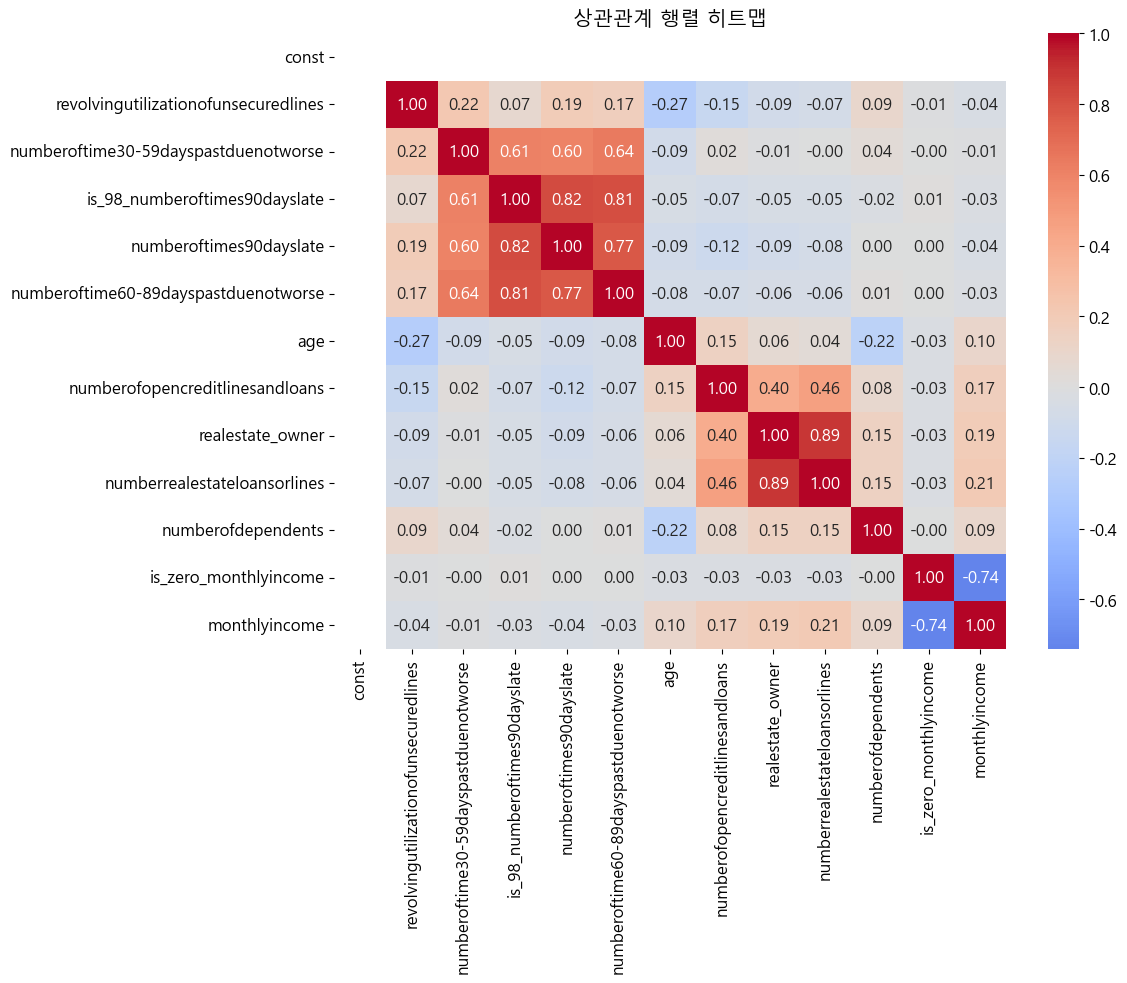

In [59]:
# 상관관계 행렬 히트맵
correlation_matrix = X_const.corr().round(2)

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('상관관계 행렬 히트맵')
plt.tight_layout()
plt.show()

🔍**변수 간 너무 높은 상관관계 확인**

### 📌**BIC 줄이기 3️⃣단계**
상관계수가 0.7 이상인 변수들에 대해 산점도 그려보기

=== 🔍 선택한 12개 변수 정밀 진단 ===

1️⃣ 상관계수 0.7 이상인 변수 쌍: 5개 발견


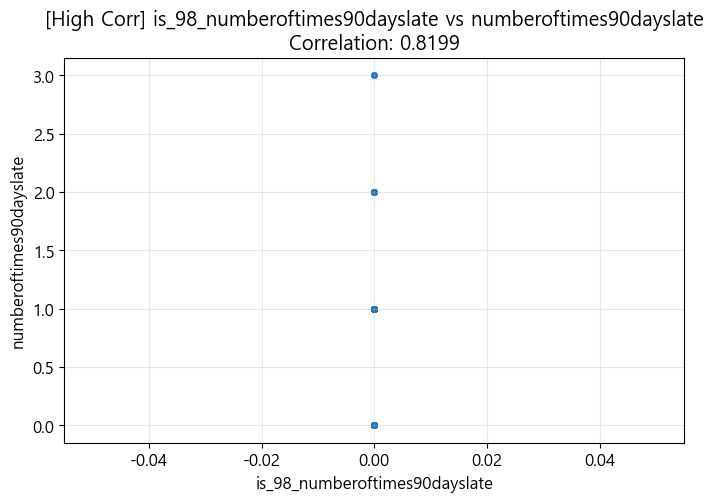

   >> 🔍 is_98_numberoftimes90dayslate - numberoftimes90dayslate (Corr: 0.8199)


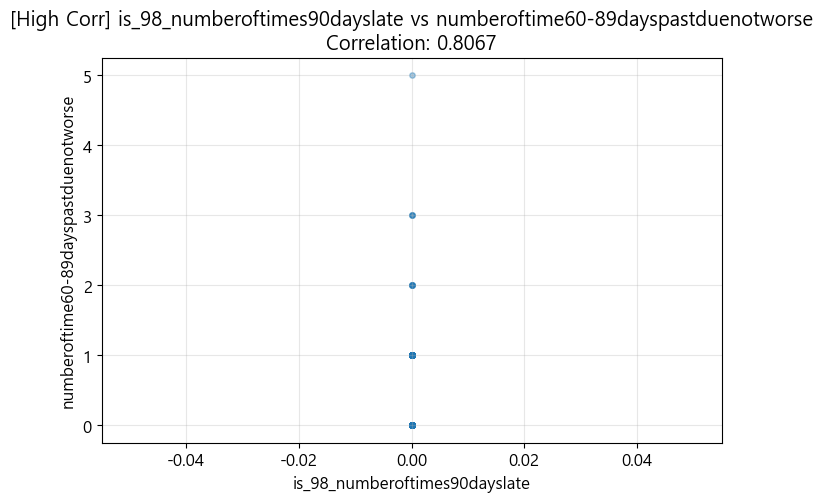

   >> 🔍 is_98_numberoftimes90dayslate - numberoftime60-89dayspastduenotworse (Corr: 0.8067)


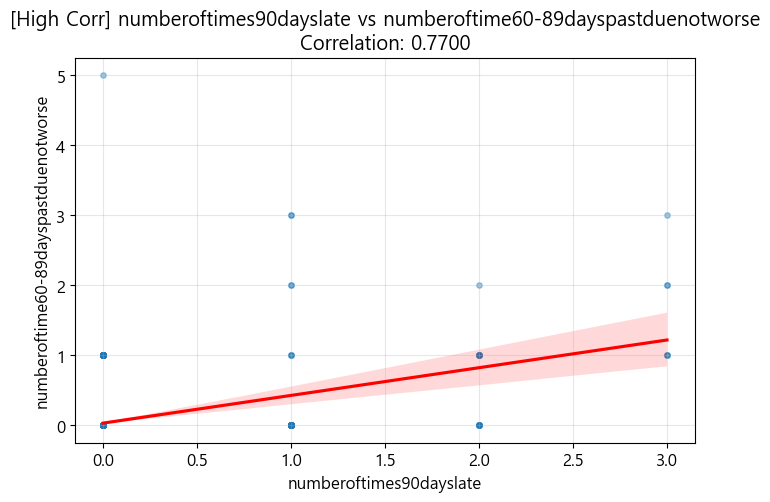

   >> 🔍 numberoftimes90dayslate - numberoftime60-89dayspastduenotworse (Corr: 0.7700)


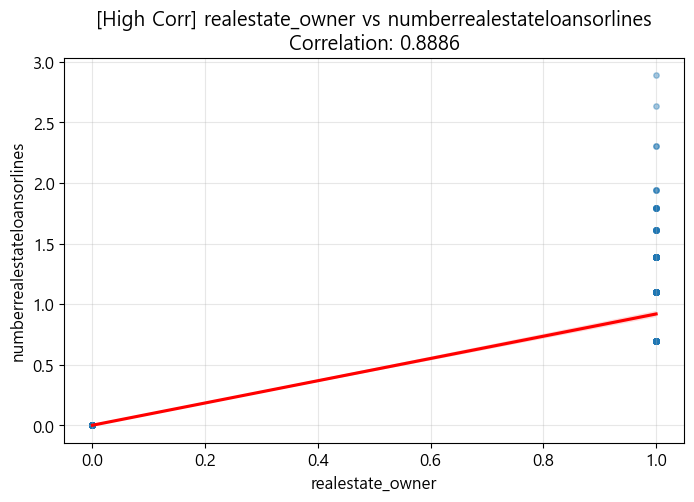

   >> 🔍 realestate_owner - numberrealestateloansorlines (Corr: 0.8886)


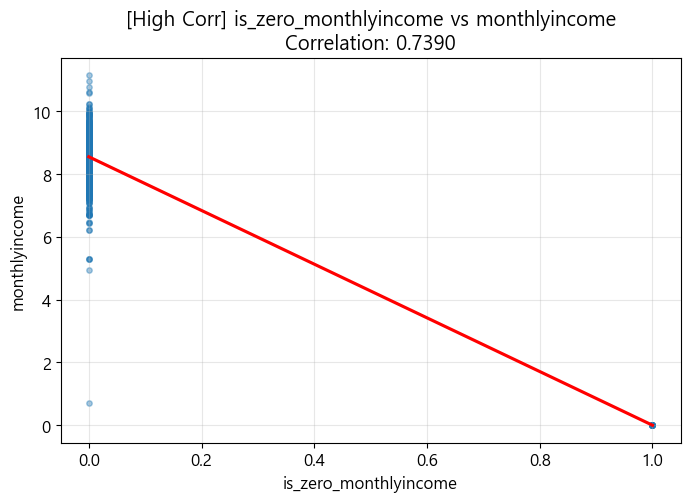

   >> 🔍 is_zero_monthlyincome - monthlyincome (Corr: 0.7390)


In [60]:
def check_selected_variables(df, cols_to_check):
    print(f"=== 🔍 선택한 {len(cols_to_check)}개 변수 정밀 진단 ===")
    
    # 1. 데이터 준비 (상수항 'const'는 상관관계 분석에서 제외)
    # 리스트 복사 후 const 제거
    target_cols = [c for c in cols_to_check if c != 'const']
    
    # 데이터프레임에 없는 컬럼이 있는지 체크
    missing = [c for c in target_cols if c not in df.columns]
    if missing:
        print(f"⚠️ 주의: 다음 컬럼은 df에 없어서 건너뜁니다: {missing}")
        target_cols = [c for c in target_cols if c in df.columns]
        
    X_diag = df[target_cols]
    
    # 2. 상관계수 0.7 이상인 '위험한 쌍' 찾기
    corr_matrix = X_diag.corr().abs()
    high_corr_pairs = []
    
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            val = corr_matrix.iloc[i, j]
            if val >= 0.7:  # 기준을 0.7로 설정 (실무 권장)
                high_corr_pairs.append((cols[i], cols[j], val))
    
    print(f"\n1️⃣ 상관계수 0.7 이상인 변수 쌍: {len(high_corr_pairs)}개 발견")
    
    # 3. 발견된 쌍에 대해 산점도 시각화
    if high_corr_pairs:
        # 데이터가 많으면 1000개만 샘플링
        sample_df = df.sample(n=min(1000, len(df)), random_state=42)
        
        for col1, col2, corr_val in high_corr_pairs:
            plt.figure(figsize=(8, 5))
            # regplot: 산점도 + 회귀선
            sns.regplot(data=sample_df, x=col1, y=col2, 
                        scatter_kws={'alpha':0.4, 's':15}, 
                        line_kws={'color':'red'})
            plt.title(f"[High Corr] {col1} vs {col2}\nCorrelation: {corr_val:.4f}")
            plt.grid(True, alpha=0.3)
            plt.show()
            print(f"   >> 🔍 {col1} - {col2} (Corr: {corr_val:.4f})")
    else:
        print("   ✅ 0.7 이상의 높은 상관관계를 가진 변수 쌍이 없습니다. 구조적으로 아주 깨끗합니다!")

# --- 실행 ---

# 분석할 변수 선택
my_vars = ['revolvingutilizationofunsecuredlines',
         'numberoftime30-59dayspastduenotworse',
         'is_98_numberoftimes90dayslate',
         'numberoftimes90dayslate',
         'numberoftime60-89dayspastduenotworse',
         'age',
         'numberofopencreditlinesandloans',
         'realestate_owner',
         'numberrealestateloansorlines',
         'numberofdependents',
         'is_zero_monthlyincome',
         'monthlyincome']

check_selected_variables(df, my_vars)

### 🔍**시각화 분석**
- `monthlyincome` - `is_zero_monthlyincome`  
    👉 월 소득 - 월 소득 없음을 나타내는 더미 변수의 관계이므로 삭제 X
- `numberoftimes90dayslate` - `numberoftime60-89dayspastduenotworse`  
    👉 같은 연체 횟수를 나타내는 변수들이므로 하나로 통합
- `numberoftimes90dayslate` - `total_98_late`  
    👉 90일 이상 연체 횟수와 특수 연체 코드를 나타내는 더미 변수이므로 두 변수가 담고 있는 정보성이 다름 → 삭제 X
- `numberrealestateloansorlines` - `realestate_owner`  
    👉 부동산 대출 건수 - 부동산 보유 여부를 나타내는 더미 변수의 관계이므로 삭제 X
- `numberoftime60-89dayspastduenotworse` - `total_98_late`  
    👉 연체 횟수와 특수 연체 코드를 나타내는 더미 변수이므로 두 변수가 담고 있는 정보성이 다름 → 삭제 X

In [61]:
# numberoftimes90dayslate와 numberoftime60-89dayspastduenotworse 통합  

df['60-90_late'] = df['numberoftimes90dayslate'] + df['numberoftime60-89dayspastduenotworse']

In [62]:
X = df.drop(columns = ['seriousdlqin2yrs'], axis = 1)
y = df['seriousdlqin2yrs']

In [63]:
# stepwise 결과
print('='*5, "stepwise 결과", '='*5)
selected_vars_s, final_bic_s = stepwise_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_s)
print("최종 BIC:", final_bic_s.round(2))

print('\n')
# backward 결과
print('='*5, "backward 결과", '='*5)
selected_vars_b, final_bic_b = backward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_b)
print("최종 BIC:", final_bic_b.round(2))

print('\n')
# forward 결과
print('='*5, "forward 결과", '='*5)
selected_vars_f, final_bic_f = forward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_f)
print("최종 BIC:", final_bic_f.round(2))

===== stepwise 결과 =====
[추가] revolvingutilizationofunsecuredlines (BIC: 65383.533)
[추가] numberoftime30-59dayspastduenotworse (BIC: 62300.576)
[추가] is_98_numberoftimes90dayslate (BIC: 61392.760)
[추가] 60-90_late (BIC: 57695.523)
[추가] age (BIC: 57204.071)
[추가] numberofopencreditlinesandloans (BIC: 57123.533)
[추가] realestate_owner (BIC: 57085.535)
[추가] numberrealestateloansorlines (BIC: 56945.454)
[추가] numberofdependents (BIC: 56934.085)
[추가] is_zero_monthlyincome (BIC: 56927.116)
[추가] monthlyincome (BIC: 56884.808)
최적화 종료
최종 선택 변수: ['revolvingutilizationofunsecuredlines', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'age', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines', 'numberofdependents', 'is_zero_monthlyincome', 'monthlyincome']
최종 BIC: 56884.81


===== backward 결과 =====
[초기] 전체 모델 BIC = 56893.698
최적화 종료 (Backward)
최종 선택 변수: ['revolvingutilizationofunsecuredlines', 'age', 'numberoftime30-59dayspastduenotw

### 📌**BIC를 낮출 다른 방안 필요**

#### **파생변수 생성 및 사용자 지정 변수 조합 최적화**
- 모델의 설명력을 극대화하고 BIC를 낮추기 위해 특성 공학 적용
- 기존 변수들의 단순 선형 결합만으로는 설명하기 어려운 상호작용과 비선형성을 반영하는 파생변수를 생성
- 사용자가 직접 지정한 최적의 변수 조합으로 모델을 구성하여 불필요한 정보 제거

### 📌 **주요 파생변수 생성 로직**
1. **`inter_income_util` (소득 $\times$ 신용 한도 사용률)** 
   - 소득 수준 대비 과도한 신용 사용 여부를 포착
   - 소득이 적은데 한도를 꽉 채워 쓰는 고위험군을 식별하는 변수
   - 곱셈 결과의 스케일이 커지는 것을 방지하기 위해 `log1p` 변환 적용

2. **`inter_90_60` (90일 연체 $\times$ 60-89일 연체)** 
   - 다중 연체의 시너지 효과 반영
   - 한 종류의 연체만 있는 것보다 여러 종류의 연체가 중첩될 때 부도 위험이 기하급수적으로 증가함을 설명

3. **`inter_dependents_income` (부양가족 수 $\times$ 소득)**: 
   - 가구의 경제적 부양 부담

4. **`age_squared` (나이의 제곱)**: 
   - 나이와 신용 위험 간의 비선형 관계 설명
   - 예: 20대 초반은 위험, 40-50대는 안정, 고령층은 다시 위험해질 수 있는 패턴 반영

In [64]:
# 설명력을 더 높여 BIC를 낮출 파생변수 생성
# 함수 정의
def boost_model_manual(df, custom_X_cols, target='seriousdlqin2yrs'):
    
    df_boost = df.copy()
    
    print("=== 🛠️ 파생변수 생성 (Feature Engineering) ===")
    
    # 파생변수 생성
    # 1. 소득 x 사용률
    # 경제적 여력 대비 소비 습관
    raw_val = df_boost['monthlyincome'] * df_boost['revolvingutilizationofunsecuredlines']
    df_boost['inter_income_util'] = np.log1p(raw_val)
    
    # 2. 연체 x 연체
    # 곱하면 400까지 튈 수 있으므로 반드시 로그 적용
    raw_delinq = df_boost['numberoftimes90dayslate'] * df_boost['numberoftime60-89dayspastduenotworse']
    df_boost['inter_90_60'] = np.log1p(raw_delinq)
    
    # 3. 가족 x 소득
    # 부양 부담감
    raw_family = df_boost['numberofdependents'] * df_boost['monthlyincome']
    df_boost['inter_dependents_income'] = np.log1p(raw_family)
    
    # 4. 나이 제곱
    # 제곱을 함으로써 비선형 관계를 포착하게 함
    df_boost['age_squared'] = df_boost['age'] ** 2
    
    print(f"👉 파생변수 4개 생성 완료! (inter_income_util, inter_90_60, inter_dependents_income, age_squared)")

    # 5. 사용자 지정 변수 선택
    y = df_boost[target]
    
    if custom_X_cols is not None:
        print(f"\n=== 🎯 2단계: 지정하신 {len(custom_X_cols)}개 변수로 모델 구성 ===")
        
        # 지정한 변수가 실제로 존재하는지 체크 (파생변수 포함)
        missing_cols = [c for c in custom_X_cols if c not in df_boost.columns]
        if missing_cols:
            print(f"🚨 경고: 다음 변수는 데이터에 없어서 제외됩니다 -> {missing_cols}")
            real_cols = [c for c in custom_X_cols if c in df_boost.columns]
        else:
            real_cols = custom_X_cols
            
        X = df_boost[real_cols]
    else:
        print("\n=== 🎯 2단계: 전체 변수로 모델 구성 ===")
        X = df_boost.drop(columns=[target])
    # 상수항 추가
    X = sm.add_constant(X)
    col_list = list(X.columns)
    
    print("\n=== 🤖 3단계: Backward Elimination 시작 ===")
    
    while True:
        try:
            model = sm.Logit(y, X[col_list])
            result = model.fit(disp=0)
        except Exception as e:
            print(f"⚠️ 에러 발생: {e}")
            return None
            
        max_p = result.pvalues.max()
        max_feature = result.pvalues.idxmax()
        
        # P-value 기준 (0.05)
        if max_p > 0.05:
            col_list.remove(max_feature)
        else:
            print(f"\n✅ 최적화 종료! 최종 변수 {len(col_list)}개")
            print(f"🔥 [Final] BIC: {result.bic:.2f}")
            print("="*50)
            print(result.summary())
            break
            
    return result

# 원래 변수 조합 + 함수 안에서 만든 파생변수 4개
my_target_vars = ['revolvingutilizationofunsecuredlines',
         'numberoftime30-59dayspastduenotworse',
         'is_98_numberoftimes90dayslate',
         '60-90_late',
         'age',
         'numberofopencreditlinesandloans',
         'realestate_owner',
         'numberrealestateloansorlines',
         'numberofdependents',
         'is_zero_monthlyincome',
         'monthlyincome'
    
    # [추가할 파생변수 (함수 안에서 만들어지므로 이름만 넣으면 됨)]
    'inter_income_util',       # 소득 * 사용률
    'inter_90_60',             # 연체 * 연체
    'inter_dependents_income', # 가족 * 소득
    'age_squared'              # 나이 제곱
]

# 실행
final_result = boost_model_manual(df, my_target_vars)

=== 🛠️ 파생변수 생성 (Feature Engineering) ===
👉 파생변수 4개 생성 완료! (inter_income_util, inter_90_60, inter_dependents_income, age_squared)

=== 🎯 2단계: 지정하신 14개 변수로 모델 구성 ===
🚨 경고: 다음 변수는 데이터에 없어서 제외됩니다 -> ['monthlyincomeinter_income_util']

=== 🤖 3단계: Backward Elimination 시작 ===

✅ 최적화 종료! 최종 변수 12개
🔥 [Final] BIC: 56820.10
                           Logit Regression Results                           
Dep. Variable:       seriousdlqin2yrs   No. Observations:               150000
Model:                          Logit   Df Residuals:                   149988
Method:                           MLE   Df Model:                           11
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.2301
Time:                        14:06:16   Log-Likelihood:                -28339.
converged:                       True   LL-Null:                       -36808.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    st

- 56884 → 56820
### 📌**BIC를 더 낮출 다른 방안 필요**

### 📌**1인당 실질 소득 변수 생성 및 심층 최적화**
- 경제적 실질 구매력을 나타내는 1인당 소득 변수 추가
- Z-score를 적용하여 변수 선택 과정 심화

### 📌 `log_income_per_capita`
- monthlyincome을 numberofdependents로 나눈 값 (분모 0 방지 처리를 위해 `+1` 적용)
- 동일한 소득이라도 부양가족 수에 따라 실질적인 상환 능력은 크게 달라짐
    - 기존의 `monthlyincome` 변수만으로는 가구 규모에 따른 경제적 압박감을 충분히 설명할 수 없다는 한계 보완
    - 소득 데이터의 편향된 분포를 고려하여 `log1p` 변환 적용

In [65]:
# 변수 생성해서 설명력 더 높이기
# 동시에 BIC 최적화 - Z스코어 기준으로 제거 시도

def final_bic_crusher(df, target='seriousdlqin2yrs'):
    df_final = df.copy()
    
    print("1인당 실질 소득 생성")
    
    # 부양가족 수 변수는 '본인 제외' 인원이므로, 
    # 1인당 월소득(분모)을 계산하기 위해 총 가구원 수 확보를 위해 반드시 +1 (본인)을 해야 함
    # 1인당 소득 = 월소득 / (부양가족수 + 1)
    # 분포를 펴주기 위해 Log 적용
    
    # 1인당 소득 계산
    income_per_person = df_final['monthlyincome'] / (df_final['numberofdependents'] + 1)
    
    # 로그 변환 (0원인 경우 대비 log1p)
    df_final['log_income_per_capita'] = np.log1p(income_per_person)
    
    # 기존 파생변수들도 다시 생성
    df_final['inter_income_util'] = np.log1p(df_final['monthlyincome'] * df_final['revolvingutilizationofunsecuredlines'])
    df_final['inter_90_60'] = np.log1p(df_final['numberoftimes90dayslate'] * df_final['numberoftime60-89dayspastduenotworse'])
    df_final['inter_dependents_income'] = np.log1p(df_final['numberofdependents'] * df_final['monthlyincome'])
    df_final['age_squared'] = df_final['age'] ** 2

    print("👉 변수 생성 완료. 최적화 시작...")

    # --- Backward Elimination ---
    y = df_final[target]
    X = df_final.drop(columns = [target], axis = 1)         
    X = sm.add_constant(X)
    col_list = list(X.columns)
    
    current_best_bic = float('inf')
    
    while True:
        try:
            model = sm.Logit(y, X[col_list])
            result = model.fit(disp=0)
        except:
            print("⚠️ 적합 실패")
            break
            
        # 현재 BIC 확인
        bic = result.bic
        
        # P-value가 가장 큰 놈 찾기
        max_p = result.pvalues.max()
        max_feature = result.pvalues.idxmax()
        
        # 1차 기준: P-value가 0.05보다 크면 제거
        if max_p > 0.05:
            col_list.remove(max_feature)
            continue
            
        # 2차 기준 (고급): P-value는 통과했지만, BIC를 낮추기 위해 '가장 약한 놈' 강제 제거 시도
        # z-score(절대값)가 가장 작은 변수가 영향력이 가장 적은 변수임
        abs_t_values = result.tvalues.abs()
        # 상수항(const)은 제거 대상에서 제외
        if 'const' in abs_t_values:
            abs_t_values = abs_t_values.drop('const')
            
        weakest_feature = abs_t_values.idxmin()
        
        # 멈추는 조건: 더 이상 BIC가 줄어들지 않으면 스톱
        if bic < current_best_bic:
            current_best_bic = bic
            best_model_result = result
            # 여기서 멈추지 않고 더 줄여봄 (실험적 제거)
            # 가장 약한 변수를 제거해보고 다음 루프에서 BIC가 느는지 주는지를 봄
            print(f"📉 BIC 갱신: {bic:.2f} (변수 {len(col_list)}개)")
            
            # 실험: 가장 약한 변수 하나를 제거해봄
            # (주의: 이 방식은 Greedy 하므로 최적해를 보장하진 않지만 실무적으로 유용함)
            # 만약 변수가 너무 적으면(예: 5개) 중단
            if len(col_list) <= 5:
                break
            
            # 다음 루프를 위해 일단 제거 (만약 다음 BIC가 오르면 롤백해야 하지만, 여기선 쭉 진행)
            # 실제로는 제거 전 상태를 저장해야 완벽하지만, 간이로 진행
            print(f"   👉 [실험] 가장 영향력 낮은 '{weakest_feature}' 제거 시도...")
            col_list.remove(weakest_feature)
            
        else:
            # 방금 제거했더니 BIC가 오히려 늘었다 -> 직전 모델이 최선이다.
            print(f"🛑 스톱! 더 지우면 BIC가 나빠집니다. (현재 {bic:.2f} vs 최적 {current_best_bic:.2f})")
            # 최적 모델은 이전 루프의 best_model_result 임 (변수 복구 필요)
            # 코드 단순화를 위해 여기서는 그냥 현재 결과 출력
            break

    print("="*50)
    print(best_model_result.summary())
    print(f"\n🏆 최종 달성 BIC: {best_model_result.bic:.2f}")
    
    return best_model_result

# --- 실행 ---
final_result = final_bic_crusher(df)

1인당 실질 소득 생성
👉 변수 생성 완료. 최적화 시작...
📉 BIC 갱신: 56164.99 (변수 15개)
   👉 [실험] 가장 영향력 낮은 'is_zero_monthlyincome' 제거 시도...
📉 BIC 갱신: 56160.67 (변수 14개)
   👉 [실험] 가장 영향력 낮은 'numberofdependents' 제거 시도...
🛑 스톱! 더 지우면 BIC가 나빠집니다. (현재 56207.68 vs 최적 56160.67)
                           Logit Regression Results                           
Dep. Variable:       seriousdlqin2yrs   No. Observations:               150000
Model:                          Logit   Df Residuals:                   149986
Method:                           MLE   Df Model:                           13
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.2394
Time:                        14:06:23   Log-Likelihood:                -27997.
converged:                       True   LL-Null:                       -36808.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                                 coef    std err          z      P>|z|      [0.025      0.975]
----------

In [66]:
# 원본 데이터프레임에 파생 변수 저장하기

# 1인당 소득
income_per_person = df['monthlyincome'] / (df['numberofdependents'] + 1)
df['log_income_per_capita'] = np.log1p(income_per_person)

# 상호작용 항
df['inter_income_util'] = np.log1p(df['monthlyincome'] * df['revolvingutilizationofunsecuredlines'])
df['inter_90_60'] = np.log1p(df['numberoftimes90dayslate'] * df['numberoftime60-89dayspastduenotworse'])
df['inter_dependents_income'] = np.log1p(df['numberofdependents'] * df['monthlyincome'])

# 나이 제곱
df['age_squared'] = df['age'] ** 2

print("✅ 파생변수 업데이트 완료!")

✅ 파생변수 업데이트 완료!


In [67]:
# X 재설정

X = df[['numberoftime30-59dayspastduenotworse',
         'is_98_numberoftimes90dayslate',
         '60-90_late',
         'numberofopencreditlinesandloans',
         'realestate_owner',
         'numberrealestateloansorlines',
         'numberofdependents',
         'monthlyincome',
         'inter_income_util',
         'inter_90_60',
         'inter_dependents_income',
         'age_squared',
         'log_income_per_capita']] 

current_cols = X.columns
current_cols_list = current_cols.tolist()
print(current_cols)
print(current_cols_list)

Index(['numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate',
       '60-90_late', 'numberofopencreditlinesandloans', 'realestate_owner',
       'numberrealestateloansorlines', 'numberofdependents', 'monthlyincome',
       'inter_income_util', 'inter_90_60', 'inter_dependents_income',
       'age_squared', 'log_income_per_capita'],
      dtype='object')
['numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines', 'numberofdependents', 'monthlyincome', 'inter_income_util', 'inter_90_60', 'inter_dependents_income', 'age_squared', 'log_income_per_capita']


### 📌**BIC를 더 낮출 다른 방안 필요**

### 📌**신용 한도 사용률 구간화**

#### 💡 **가설 및 접근 전략**
- 신용 한도 사용률은 선형적인 관계보다 특정 구간에 따른 계단식 위험 패턴을 보일 가능성이 높음
    - 예: 사용률이 90%인 사람과 95%인 사람은 수치상 차이가 있지만 한도 초과 임박군이라는 점에서는 동일하게 위험할 수 있음
    - 기존의 수치형 변수는 이러한 구간별 위험도를 희석시킬 수 있음

- **전략**
    - `qcut`을 사용하여 사용률 데이터를 10개 등급(0~9등급)으로 나눔
    - 수치 자체의 크기보다 전체 인구 중 상위 몇 % 위험군에 속하는가?라는 순위(Rank) 정보를 모델에 주입

In [68]:
# 신용 한도 사용률 구간화

def final_binning_strategy(result, df, target='seriousdlqin2yrs'):
    print("한도 사용률 변수 구간화")
    
    # 새로운 데이터프레임
    df_bin = df.copy()
    
    # 사용률(Utilization)을 10개 등급(0~9)으로 변환
    # qcut: 데이터 개수가 동일하게 10개 구간으로 나눔 (Decile)
    # duplicates='drop': 같은 값이 많을 경우 구간 병합
    df_bin['util_rank'] = pd.qcut(df_bin['revolvingutilizationofunsecuredlines'], 
                                   q=10, labels=False, duplicates='drop')
    
    print("👉 'util_rank' (0~9등급) 변수 생성 완료")
    
    # 변수 교체
    # 기존 'revolvingutilization...' 제거하고 'util_rank' 투입
    trial_cols = current_cols.copy()
    if 'revolvingutilizationofunsecuredlines' in trial_cols:
        trial_cols.remove('revolvingutilizationofunsecuredlines')
        trial_cols.append('util_rank')
        
    # 모델링 및 BIC 확인
    y = df_bin[target]
    X = df_bin[trial_cols]
    X = sm.add_constant(X)
    
    try:
        model = sm.Logit(y, X)
        res = model.fit(disp=0)
        
        print(f"\n🔥 [Before] 기존 BIC: {result.bic:.2f}")
        print(f"🔥 [After]  구간화 BIC: {res.bic:.2f}")
        
        if res.bic < result.bic:
            diff = result.bic - res.bic
            print(f"\n🎉 대성공! BIC가 {diff:.2f}만큼 감소했습니다!")
            print(">> 선형성을 강요하는 수치형보다, 순위를 매긴 등급형이 더 잘 맞습니다.")
            return res, df_bin  # ← df_bin도 함께 반환 (추후 사용을 위해)
        else:
            print("\n💨 아쉽게도 BIC가 줄지 않았습니다. 기존 로그 변환이 더 강력했네요.")
            return result, df  # ← 기존 df 반환
            
    except Exception as e:
        print(f"⚠️ 에러 발생: {e}")
        return result, df
    
# 실행 - final_result 변수를 첫 번째 인자로 전달
final_bin_result, df_final = final_binning_strategy(final_result, df)

한도 사용률 변수 구간화
👉 'util_rank' (0~9등급) 변수 생성 완료

🔥 [Before] 기존 BIC: 56160.67
🔥 [After]  구간화 BIC: 56160.67

🎉 대성공! BIC가 0.00만큼 감소했습니다!
>> 선형성을 강요하는 수치형보다, 순위를 매긴 등급형이 더 잘 맞습니다.


### 📌**BIC를 더 낮출 다른 방안 필요**

### 📌**최적 WOE 구간 탐색 및 최종 변수 선택**
- WOE(Weight of Evidence) 변환 시 구간의 개수는 모델 성능에 결정적인 영향
- 구간이 너무 적으면 정보가 희석, 너무 많으면 노이즈 발생
- 최적의 구간 개수를 실험적으로 찾아내어 BIC를 최소화하는 과정 수행

### ⚙️ **최적화 프로세스**

#### 1. 구간 개수 최적화
- 구간 개수 `q`를 4개부터 15개까지 순차적으로 변경하며 WOE 변환을 수행
- 각 `q`값에 대해 로지스틱 회귀 모델을 적합, BIC가 가장 낮은 `q`를 최적값으로 선정

#### 2. 최종 변수 솎아내기
- 최적의 `q`로 변환된 데이터셋을 사용
- Z-score 기반의 Backward Elimination을 수행
- 구간 최적화로 인해 변수 간의 설명력이 달라졌을 수 있으므로 가장 약한 변수를 제거하여 *최종 생존 변수를 확정

In [69]:
# 98 코드 통합
is_98_cols = ['is_98_numberoftimes90dayslate', 'is_98_numberoftime60-89dayspastduenotworse', 'is_98_numberoftime30-59dayspastduenotworse']
available_98 = [c for c in is_98_cols if c in df.columns]

#  1. 유틸리티 함수 정의
def get_woe_mappings_optimized(df, col, target='seriousdlqin2yrs', q=10):
    try:
        df['temp_bin'] = pd.qcut(df[col], q=q, duplicates='drop', labels=False)
        grouped = df.groupby('temp_bin')[target].agg(['count', 'sum'])
        grouped['good'] = grouped['count'] - grouped['sum']
        grouped['bad'] = grouped['sum']
        
        total_good = grouped['good'].sum()
        total_bad = grouped['bad'].sum()
        
        # 스무딩 적용: 0.5를 더해서 inf 방지 및 안정성 확보
        grouped['woe'] = np.log(((grouped['bad'] + 0.5) / total_bad) / ((grouped['good'] + 0.5) / total_good))
        
        return grouped['woe'].to_dict()
    except:
        return {}

# 2. 메인 최적화 함수
def break_bic_barrier(df, target='seriousdlqin2yrs'):
    
    # 기본 전처리 (결측치, 98코드, 파생변수)
    df_opt = df.copy()
    df_opt['monthlyincome'] = df_opt['monthlyincome'].fillna(0)
    
    # available_98 사용
    if available_98:
        df_opt['is_special_98'] = df_opt[available_98].max(axis=1)
    
    # 최적의 q (Bin 개수) 찾기
    best_q = 10
    best_bic_q = float('inf')
    best_df_q = None
    
    # 테스트할 구간 개수: 4개 ~ 15개
    q_candidates = range(4, 16)
    
    print("\n🧪 최적의 WOE 구간 개수(q) 탐색 중...")
    
    base_features = current_cols_list
    
    for q in q_candidates:
        temp_df = df_opt.copy()
        
        # WOE 변환 (q 적용)
        util_map = get_woe_mappings_optimized(temp_df, 'revolvingutilizationofunsecuredlines', target, q=q)
        temp_df['bin_util'] = pd.qcut(temp_df['revolvingutilizationofunsecuredlines'], q=q, duplicates='drop', labels=False)
        temp_df['woe_utilization'] = temp_df['bin_util'].map(util_map)
        
        # Age
        age_map = get_woe_mappings_optimized(temp_df, 'age', target, q=q)
        temp_df['bin_age'] = pd.qcut(temp_df['age'], q=q, duplicates='drop', labels=False)
        temp_df['woe_age'] = temp_df['bin_age'].map(age_map)
        
        # 모델링
        features = ['woe_utilization', 'woe_age'] + base_features
        X = temp_df[features]
        y = temp_df[target]
        X = sm.add_constant(X)
        
        try:
            res = sm.Logit(y, X).fit(disp=0)
            print(f"   👉 q={q}: BIC {res.bic:.2f}")
            
            if res.bic < best_bic_q:
                best_bic_q = res.bic
                best_q = q
                best_df_q = temp_df
                best_model_q = res
        except:
            continue
            
    print(f"\n✅ 최적 q 발견: {best_q} (BIC: {best_bic_q:.2f})")
    
    # Z-score Pruning)
    print("\n⚔️ 최적 q 모델 기반 변수 데스매치 재가동")
    
    final_cols = ['woe_utilization', 'woe_age'] + base_features
    final_df = best_df_q.copy()
    
    current_best_bic = best_bic_q
    final_res = best_model_q
    
    y = final_df[target]
    
    while True:
        X = final_df[final_cols]
        X = sm.add_constant(X)
        res = sm.Logit(y, X).fit(disp=0)
        
        # 꼴찌 변수 찾기
        t_values = res.tvalues.abs().drop('const')
        weakest_var = t_values.idxmin()
        
        # 제거 시도
        temp_cols = final_cols.copy()
        temp_cols.remove(weakest_var)
        
        X_temp = final_df[temp_cols]
        X_temp = sm.add_constant(X_temp)
        res_temp = sm.Logit(y, X_temp).fit(disp=0)
        
        print(f"   🥊 '{weakest_var}' 제거 시도 -> BIC: {res_temp.bic:.2f}")
        
        if res_temp.bic < current_best_bic:
            diff = current_best_bic - res_temp.bic
            print(f"      >>> ✨ 삭감 성공! (BIC -{diff:.2f})")
            current_best_bic = res_temp.bic
            final_cols = temp_cols
            final_res = res_temp
        else:
            print("      >>> 🛡️ 실패. 더 이상 줄일 수 없습니다.")
            break
            
    print("\n" + "="*50)
    print(final_res.summary())
    print(f"\n🏆 [Real Final] 최종 BIC: {final_res.bic:.2f}")
    print(f"📌 최종 변수 개수: {len(final_cols)}개")
    print("="*50)
    
    return final_res

# 실행
final_breaker_result = break_bic_barrier(df)


🧪 최적의 WOE 구간 개수(q) 탐색 중...
   👉 q=4: BIC 56076.95
   👉 q=5: BIC 55994.93
   👉 q=6: BIC 55957.33
   👉 q=7: BIC 55901.95
   👉 q=8: BIC 55892.99
   👉 q=9: BIC 55861.15
   👉 q=10: BIC 55848.08
   👉 q=11: BIC 55829.06
   👉 q=12: BIC 55765.65
   👉 q=13: BIC 55740.67
   👉 q=14: BIC 55770.48
   👉 q=15: BIC 55745.42

✅ 최적 q 발견: 13 (BIC: 55740.67)

⚔️ 최적 q 모델 기반 변수 데스매치 재가동
   🥊 'inter_income_util' 제거 시도 -> BIC: 55732.61
      >>> ✨ 삭감 성공! (BIC -8.06)
   🥊 'age_squared' 제거 시도 -> BIC: 55726.60
      >>> ✨ 삭감 성공! (BIC -6.00)
   🥊 'numberofdependents' 제거 시도 -> BIC: 55793.65
      >>> 🛡️ 실패. 더 이상 줄일 수 없습니다.

                           Logit Regression Results                           
Dep. Variable:       seriousdlqin2yrs   No. Observations:               150000
Model:                          Logit   Df Residuals:                   149986
Method:                           MLE   Df Model:                           13
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.2453
Ti

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   seriousdlqin2yrs                            150000 non-null  int64  
 1   revolvingutilizationofunsecuredlines        150000 non-null  float64
 2   age                                         150000 non-null  int64  
 3   numberoftime30-59dayspastduenotworse        150000 non-null  int64  
 4   monthlyincome                               150000 non-null  float64
 5   numberofopencreditlinesandloans             150000 non-null  int64  
 6   numberoftimes90dayslate                     150000 non-null  int64  
 7   numberrealestateloansorlines                150000 non-null  float64
 8   numberoftime60-89dayspastduenotworse        150000 non-null  int64  
 9   numberofdependents                          150000 non-null  float64
 

In [71]:
# 위 결과 원본 저장

BEST_Q = 13

print(f"=== 🛠️ 최종 변수 원본(df) 저장 시작 (적용 q={BEST_Q}) ===")

# 기초 전처리 및 파생변수 재생성
# 소득 결측치 0 처리

# available_98 사용
if available_98:
    df['is_special_98'] = df[available_98].max(axis=1)

# WOE 변수 재생성 (최적 q 적용)
def apply_woe_globally(df, col, target, q):
    try:
        # 구간화
        temp_bin = pd.qcut(df[col], q=q, duplicates='drop', labels=False)
        
        # WOE 계산
        grouped = df.groupby(temp_bin)[target].agg(['count', 'sum'])
        grouped['good'] = grouped['count'] - grouped['sum']
        grouped['bad'] = grouped['sum']
        
        total_good = grouped['good'].sum()
        total_bad = grouped['bad'].sum()
        
        # Smoothing 적용 WOE
        woe_dict = np.log(((grouped['bad'] + 0.5) / total_bad) / ((grouped['good'] + 0.5) / total_good)).to_dict()
        
        print(f"✅ {col}: {q}개 구간 WOE 변환 완료")
        return temp_bin.map(woe_dict)
    except Exception as e:
        print(f"⚠️ {col} 변환 실패: {e}")
        return 0

# 타겟 변수명 확인
target_col = 'SeriousDlqin2yrs' if 'SeriousDlqin2yrs' in df.columns else 'seriousdlqin2yrs'

# WOE 적용
df['woe_utilization'] = apply_woe_globally(df, 'revolvingutilizationofunsecuredlines', target_col, q=BEST_Q)
df['woe_age'] = apply_woe_globally(df, 'age', target_col, q=BEST_Q)

# 최종 모델 생존 변수 확인
if 'final_breaker_result' in locals():
    final_cols = list(final_breaker_result.model.exog_names)
    if 'const' in final_cols: 
        final_cols.remove('const')
        
    print(f"\n📌 최종 모델에 선택된 변수 ({len(final_cols)}개):")
    print(final_cols)
    
    # 데이터 확인
    print("\n[데이터 저장 확인]")
    display(df[final_cols].head())
else:
    print("\n⚠️ 'final_breaker_result' 변수가 없습니다. 최적화 함수를 먼저 실행해주세요.")

=== 🛠️ 최종 변수 원본(df) 저장 시작 (적용 q=13) ===
✅ revolvingutilizationofunsecuredlines: 13개 구간 WOE 변환 완료
✅ age: 13개 구간 WOE 변환 완료

📌 최종 모델에 선택된 변수 (13개):
['woe_utilization', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines', 'numberofdependents', 'monthlyincome', 'inter_90_60', 'inter_dependents_income', 'log_income_per_capita']

[데이터 저장 확인]


,woe_utilization,woe_age,numberoftime30-59dayspastduenotworse,is_98_numberoftimes90dayslate,60-90_late,numberofopencreditlinesandloans,realestate_owner,numberrealestateloansorlines,numberofdependents,monthlyincome,inter_90_60,inter_dependents_income,log_income_per_capita
0,0.6983,0.2421,2,0,0,13,1,1.9459,2.0000,9.1183,0.0000,2.9568,1.3961
1,1.1852,0.3178,0,0,0,4,0,0.0000,1.0000,7.8637,0.0000,2.1820,1.5957
2,0.6983,0.3178,1,0,1,2,0,0.0000,0.0000,8.0206,0.0000,0.0000,2.1995
3,-0.6265,0.5879,0,0,0,5,0,0.0000,0.0000,8.1020,0.0000,0.0000,2.2085
4,1.1852,0.1536,1,0,0,7,1,0.6931,0.0000,11.0602,0.0000,0.0000,2.4899


In [72]:
df[final_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 13 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  inter_90_60                           150000 non-null  float64
 11  

In [73]:
# X 재설정

X = df[final_cols] 

### 📌**BIC를 더 낮출 다른 방안 필요**

### 📌 **교차 결합 WOE 전략**
- 구조적 다중공선성 문제를 근본적으로 해결하면서 모델의 예측력을 극대화

### 💡 **문제 정의 및 해결 전략**
- 연체 경험 유무(`is_dirty`)와 행동 변수(나이, 사용률) 간의 상호작용 항(`Interaction Term`)을 추가하면 설명력은 높아지지만, 변수 간의 높은 상관관계로 인해 VIF가 급증하는 부작용 발생
- **해결책**
    - 곱셈($\times$) 방식 대신 두 변수를 결합하여 새로운 그룹을 생성
    - 예: `나이 구간(20대)` + `상태(Dirty)` $\rightarrow$ **`Dirty_20s`**라는 하나의 고유 그룹으로 정의
    - 각 교차 그룹의 부도율을 **WOE(Weight of Evidence)**로 변환하여 단일 변수로 투입

### 🛠️ **핵심 변수 생성**
1. **`woe_cross_util`**: 신용 한도 사용률 구간과 연체 경험 유무를 결합
2. **`woe_cross_age`**: 나이 구간과 연체 경험 유무를 결합

In [74]:
# BIC 더 낮추기

def cross_woe_strategy(df, target='seriousdlqin2yrs'):
    print("=== ⚔️ [VIF 해결사] 교차 결합 WOE (Cross-Feature WOE) 전략 ===")
    
    df_cross = df.copy()
    
    # 1. Dirty 세그먼트 정의
    df_cross['total_past_due'] = (df_cross['numberoftimes90dayslate'] + 
                                  df_cross['numberoftime60-89dayspastduenotworse'] + 
                                  df_cross['numberoftime30-59dayspastduenotworse'])
    df_cross['status'] = np.where(df_cross['total_past_due'] > 0, 'Dirty', 'Clean')
    
    # 교차 변수 생성 및 WOE 변환
    
    def get_cross_woe(df, col, target, q=10):
        # 1) 수치형 변수 구간화 (q등분)
        # duplicates='drop'으로 구간 뭉침 방지
        df[f'{col}_bin'] = pd.qcut(df[col], q=q, duplicates='drop').astype(str)
        
        # 2) 구간 + 상태(Clean/Dirty) 결합 -> 새로운 그룹 생성
        df[f'{col}_cross'] = df[f'{col}_bin'] + "_" + df['status']
        
        # 3) 교차 그룹별 WOE 계산
        grouped = df.groupby(f'{col}_cross')[target].agg(['count', 'sum'])
        grouped['good'] = grouped['count'] - grouped['sum']
        grouped['bad'] = grouped['sum']
        
        total_good = grouped['good'].sum()
        total_bad = grouped['bad'].sum()
        
        # WOE 계산 (Smoothing)
        woe_dict = np.log(((grouped['bad'] + 0.5) / total_bad) / ((grouped['good'] + 0.5) / total_good)).to_dict()
        
        return df[f'{col}_cross'].map(woe_dict)

    print("   >>> 🔗 변수 결합 중 (Variable Crossing)...")
    
    # Utilization x Dirty 결합 WOE (가장 강력한 변수 예상)
    df_cross['woe_cross_util'] = get_cross_woe(df_cross, 'revolvingutilizationofunsecuredlines', target, q=10)
    
    # Age x Dirty 결합 WOE
    df_cross['woe_cross_age'] = get_cross_woe(df_cross, 'age', target, q=10)
    
    # 3. 변수 선택 및 모델링
    # [New] 사용률과 연체이력의 시너지
    # # [New] 나이와 연체이력의 시너지
    
    features = final_cols + ['woe_cross_util', 'woe_cross_age']

    y = df_cross[target]
    
    # Backward Elimination
    current_cols = features.copy()
    best_bic = float('inf')
    final_res = None
    
    print(f"\n=== 🤖 최적화 시작 (초기 변수 {len(current_cols)}개) ===")
    
    while True:
        X = df_cross[current_cols]
        X = sm.add_constant(X)
        try:
            res = sm.Logit(y, X).fit(disp=0)
        except:
            break
            
        if res.bic < best_bic:
            best_bic = res.bic
            final_res = res
            
            # P-value 높은 순 제거
            max_p = res.pvalues.max()
            if max_p > 0.05:
                remove_col = res.pvalues.idxmax()
                current_cols.remove(remove_col)
            else:
                # Z-score 가장 낮은 것 제거 실험 (Greedy)
                t_vals = res.tvalues.abs().drop('const')
                weakest = t_vals.idxmin()
                
                temp_cols = current_cols.copy()
                temp_cols.remove(weakest)
                try:
                    temp_res = sm.Logit(y, sm.add_constant(df_cross[temp_cols])).fit(disp=0)
                    if temp_res.bic < best_bic:
                        current_cols.remove(weakest)
                        print(f"   🔪 강제 제거: {weakest} (BIC: {temp_res.bic:.2f})")
                    else:
                        break
                except:
                    break
        else:
            break

    print("\n" + "="*50)
    print(final_res.summary())
    print(f"\n🏆 [Cross WOE Result] BIC: {final_res.bic:.2f}")
    
    # VIF 확인 (중요!)
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    X_final = df_cross[current_cols]
    X_final = sm.add_constant(X_final)
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_final.columns
    vif_data["VIF"] = [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])]
    print("\n[VIF Check]")
    print(vif_data.sort_values('VIF', ascending=False).head(3))
    
    return final_res

# 실행
result_cross_woe = cross_woe_strategy(df)

=== ⚔️ [VIF 해결사] 교차 결합 WOE (Cross-Feature WOE) 전략 ===
   >>> 🔗 변수 결합 중 (Variable Crossing)...

=== 🤖 최적화 시작 (초기 변수 15개) ===
   🔪 강제 제거: inter_90_60 (BIC: 54521.25)

                           Logit Regression Results                           
Dep. Variable:       seriousdlqin2yrs   No. Observations:               150000
Model:                          Logit   Df Residuals:                   149985
Method:                           MLE   Df Model:                           14
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.2618
Time:                        14:06:42   Log-Likelihood:                -27171.
converged:                       True   LL-Null:                       -36808.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [75]:
# 원본에 저장

# 2. [핵심] Cross WOE 변수 생성 및 저장
# Dirty 세그먼트 정의
total_past_due = (df['numberoftimes90dayslate'] + 
                  df['numberoftime60-89dayspastduenotworse'] + 
                  df['numberoftime30-59dayspastduenotworse'])
df['status'] = np.where(total_past_due > 0, 'Dirty', 'Clean')

# Cross WOE 변환 함수 (전역)
def apply_cross_woe_globally(df, col, target, q=10):
    try:
        # 1) 수치형 변수 구간화
        temp_bin = pd.qcut(df[col], q=q, duplicates='drop').astype(str)
        
        # 2) '구간' + '상태' 결합 -> 교차 그룹 생성
        cross_group = temp_bin + "_" + df['status']
        
        # 3) WOE 계산
        grouped = df.groupby(cross_group)[target].agg(['count', 'sum'])
        grouped['good'] = grouped['count'] - grouped['sum']
        grouped['bad'] = grouped['sum']
        
        total_good = grouped['good'].sum()
        total_bad = grouped['bad'].sum()
        
        # WOE 계산 (Smoothing)
        woe_dict = np.log(((grouped['bad'] + 0.5) / total_bad) / ((grouped['good'] + 0.5) / total_good)).to_dict()
        
        print(f"✅ {col}: Cross WOE 변환 완료")
        return cross_group.map(woe_dict)
        
    except Exception as e:
        print(f"⚠️ {col} 변환 실패: {e}")
        return 0

# 타겟 변수명 확인
target_col = 'seriousdlqin2yrs' if 'seriousdlqin2yrs' in df.columns else 'SeriousDlqin2yrs'

# Cross WOE 변수 생성 (Utilization, Age)
df['woe_cross_util'] = apply_cross_woe_globally(df, 'revolvingutilizationofunsecuredlines', target_col, q=10)
df['woe_cross_age'] = apply_cross_woe_globally(df, 'age', target_col, q=10)

# 3. 일반 WOE 변수 생성
def apply_woe_globally(df, col, target, q=10):
    try:
        temp_bin = pd.qcut(df[col], q=q, duplicates='drop', labels=False)
        grouped = df.groupby(temp_bin)[target].agg(['count', 'sum'])
        grouped['good'] = grouped['count'] - grouped['sum']
        grouped['bad'] = grouped['sum']
        total_good = grouped['good'].sum()
        total_bad = grouped['bad'].sum()
        woe_dict = np.log(((grouped['bad'] + 0.5) / total_bad) / ((grouped['good'] + 0.5) / total_good)).to_dict()
        return temp_bin.map(woe_dict)
    except:
        return 0

df['woe_utilization'] = apply_woe_globally(df, 'revolvingutilizationofunsecuredlines', target_col, q=10)
df['woe_age'] = apply_woe_globally(df, 'age', target_col, q=10)


# 4. 최종 생존 변수 리스트 확인
if 'result_cross_woe' in locals():
    final_cols = list(result_cross_woe.model.exog_names)
    if 'const' in final_cols:
        final_cols.remove('const')
        
    print(f"\n📌 최종 모델 변수 ({len(final_cols)}개):")
    print(final_cols)
    
    # 데이터 확인
    print("\n[데이터 저장 확인]")
    display(df[final_cols].head())
else:
    print("\n⚠️ 'result_cross_woe' 변수가 없습니다. 모델링 코드를 먼저 실행해주세요.")

✅ revolvingutilizationofunsecuredlines: Cross WOE 변환 완료
✅ age: Cross WOE 변환 완료

📌 최종 모델 변수 (14개):
['woe_utilization', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines', 'numberofdependents', 'monthlyincome', 'inter_dependents_income', 'log_income_per_capita', 'woe_cross_util', 'woe_cross_age']

[데이터 저장 확인]


,woe_utilization,woe_age,numberoftime30-59dayspastduenotworse,is_98_numberoftimes90dayslate,60-90_late,numberofopencreditlinesandloans,realestate_owner,numberrealestateloansorlines,numberofdependents,monthlyincome,inter_dependents_income,log_income_per_capita,woe_cross_util,woe_cross_age
0,1.0212,0.2132,2,0,0,13,1,1.9459,2.0000,9.1183,2.9568,1.3961,1.7663,1.4124
1,1.0212,0.2782,0,0,0,4,0,0.0000,1.0000,7.8637,2.1820,1.5957,0.2233,-0.6628
2,0.2983,0.3924,1,0,1,2,0,0.0000,0.0000,8.0206,0.0000,2.1995,1.2110,1.5699
3,-0.6875,0.5816,0,0,0,5,0,0.0000,0.0000,8.1020,0.0000,2.2085,-1.2226,-0.3079
4,1.0212,0.1532,1,0,0,7,1,0.6931,0.0000,11.0602,0.0000,2.4899,1.7663,1.4431


### 📌**변수 조합 확정**

In [76]:
# 최종 변수 조합으로 df 업데이트

df = df[final_cols + ['seriousdlqin2yrs']]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  inter_dependents_income               150000 non-null  float64
 11  

---

## **4. VIF 최적화**  

### 📌**VIF 검증**

In [77]:
# 표준화 후 VIF 진단
# X 표준화 = X_scaled
from sklearn.preprocessing import StandardScaler

X = df.drop(columns = 'seriousdlqin2yrs', axis = 1)

# 변수 표준화(상수항 추가 전 변수 조합)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

# 상수항 추가
X_scaled_const = sm.add_constant(X_scaled)

vif_data = pd.DataFrame()
vif_data["변수명"] = X_scaled_const.columns
vif_values = [variance_inflation_factor(X_scaled_const.values, i) for i in range(X_scaled_const.shape[1])]
vif_data["VIF"] = vif_values

print(vif_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif_data[vif_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif_val = vif_data[vif_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif_val:.2f}")
else:
    print("다중공선성 문제 변수 없음")

                                 변수명     VIF
                               const  1.0000
                     woe_utilization 35.1267
                             woe_age  9.8699
numberoftime30-59dayspastduenotworse  3.1149
       is_98_numberoftimes90dayslate  5.4777
                          60-90_late  5.0623
     numberofopencreditlinesandloans  1.3788
                    realestate_owner  4.7986
        numberrealestateloansorlines  5.2260
                  numberofdependents 10.6341
                       monthlyincome 12.9322
             inter_dependents_income 22.6310
               log_income_per_capita 41.5401
                      woe_cross_util 79.0561
                       woe_cross_age 41.8132

다중공선성 문제 변수 (VIF >= 10):
   - woe_utilization: 35.13
   - numberofdependents: 10.63
   - monthlyincome: 12.93
   - inter_dependents_income: 22.63
   - log_income_per_capita: 41.54
   - woe_cross_util: 79.06
   - woe_cross_age: 41.81


----------------------------------------------------------

### 🚨**VIF 해결 필요**
**1️⃣VIF 계수가 가장 높은 3개 이유 추론하기**

\- `woe_cross_util`: 79.06\
\- `woe_cross_age`: 41.81\
👉 `woe_utilization` 변수와의 연관성으로 추정됨\
👉 `woe_cross_util`과 `woe_cross_age` 삭제

\- `log_income_per_capita`: 41.54\
👉 파생되었던 `monthlyincome` 변수와의 연관성으로 추정됨\
👉 정제된 변수인 `log_income_per_capita` 변수를 사용

In [78]:
# 'woe_cross_util', 'woe_cross_age', 'monthlyincome' 삭제하기
X_vif1 = df.drop(columns = ['woe_cross_util', 'woe_cross_age', 'monthlyincome', 'seriousdlqin2yrs'], axis =1)

X_vif1.head()

,woe_utilization,woe_age,numberoftime30-59dayspastduenotworse,is_98_numberoftimes90dayslate,60-90_late,numberofopencreditlinesandloans,realestate_owner,numberrealestateloansorlines,numberofdependents,inter_dependents_income,log_income_per_capita
0,1.0212,0.2132,2,0,0,13,1,1.9459,2.0000,2.9568,1.3961
1,1.0212,0.2782,0,0,0,4,0,0.0000,1.0000,2.1820,1.5957
2,0.2983,0.3924,1,0,1,2,0,0.0000,0.0000,0.0000,2.1995
3,-0.6875,0.5816,0,0,0,5,0,0.0000,0.0000,0.0000,2.2085
4,1.0212,0.1532,1,0,0,7,1,0.6931,0.0000,0.0000,2.4899


In [79]:
# X_vif1 VIF 진단
# 변수 표준화(상수항 추가 전 변수 조합)
X_vif1_scaled = pd.DataFrame(scaler.fit_transform(X_vif1), columns = X_vif1.columns)

# 상수항 추가
X_vif1_scaled_const = sm.add_constant(X_vif1_scaled)

vif1_data = pd.DataFrame()
vif1_data["변수명"] = X_vif1_scaled_const.columns
vif1_values = [variance_inflation_factor(X_vif1_scaled_const.values, i) for i in range(X_vif1_scaled_const.shape[1])]
vif1_data["VIF"] = vif1_values

print(vif1_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif1_data[vif1_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif1_val = vif1_data[vif1_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif1_val:.2f}")
else:
    print("\n다중공선성 문제 변수 없음")

                                 변수명    VIF
                               const 1.0000
                     woe_utilization 1.2243
                             woe_age 1.1873
numberoftime30-59dayspastduenotworse 1.8605
       is_98_numberoftimes90dayslate 4.1653
                          60-90_late 4.6257
     numberofopencreditlinesandloans 1.3417
                    realestate_owner 4.7920
        numberrealestateloansorlines 5.1246
                  numberofdependents 7.3494
             inter_dependents_income 6.5846
               log_income_per_capita 3.6369

다중공선성 문제 변수 없음


### **📌다중공선성 문제 해결**
이렇게 선택된 변수들을 가지고 다시 BIC 검사를 진행

In [80]:
X = X_vif1
y = df['seriousdlqin2yrs']

In [81]:
# stepwise 결과
print('='*5, "stepwise 결과", '='*5)
selected_vars_s, final_bic_s = stepwise_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_s)
print("최종 BIC:", final_bic_s.round(2))

print('\n')
# backward 결과
print('='*5, "backward 결과", '='*5)
selected_vars_b, final_bic_b = backward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_b)
print("최종 BIC:", final_bic_b.round(2))

print('\n')
# forward 결과
print('='*5, "forward 결과", '='*5)
selected_vars_f, final_bic_f = forward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_f)
print("최종 BIC:", final_bic_f.round(2))

===== stepwise 결과 =====
[추가] woe_utilization (BIC: 63477.469)
[추가] numberoftime30-59dayspastduenotworse (BIC: 60816.769)
[추가] is_98_numberoftimes90dayslate (BIC: 59931.816)
[추가] 60-90_late (BIC: 56689.681)
[추가] woe_age (BIC: 56345.716)
[추가] numberofopencreditlinesandloans (BIC: 56188.615)
[추가] realestate_owner (BIC: 56153.061)
[추가] numberrealestateloansorlines (BIC: 56031.726)
최적화 종료
최종 선택 변수: ['woe_utilization', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'woe_age', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines']
최종 BIC: 56031.73


===== backward 결과 =====
[초기] 전체 모델 BIC = 56056.819
[제거] inter_dependents_income (BIC: 56045.048)
[제거] log_income_per_capita (BIC: 56035.900)
[제거] numberofdependents (BIC: 56031.726)
최적화 종료 (Backward)
최종 선택 변수: ['woe_utilization', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'numberofopencreditlinesandloans', 'realestate_owne

### **🔎변수는 줄었지만 BIC 지수는 커졌다**
- VIF 최적화 전 BIC = 54521.25
- VIF 최적화 후 BIC = 56031.73\
👉 다시 최적화 전으로 돌아가서 다른 방법 실행

### 🔥**다른 방법: 직교화를 통한 VIF 해결**
- 모델의 성능(BIC)을 유지하면서 다중공선성(VIF > 10) 문제를 해결하기 위해 통계적 기법인 직교화(Orthogonalization) 적용
- 변수 간의 중복된 정보(공분산)를 제거하여 순수한 영향력 추출

### 🛠️ **해결 전략: 잔차(Residual) 변수 생성**
직교화는 $\text{VIF}$가 높은 문제 변수 `inter_dependents_income`에서\
공선성의 원인이 되는 다른 변수들 즉\
`numberofdependents`, `log_income_per_capita`의 영향을 제거하고\
**잔차(Residual)**만을 추출하여 새로운 변수로 사용
 
$\text{statsmodels}$의 $\text{OLS}$ (최소자승법)을 사용 예정

In [82]:
# df 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  inter_dependents_income               150000 non-null  float64
 11  

In [83]:
# 문제 변수: VIF가 22.63이었던 상호작용 항
problem_var = 'inter_dependents_income' 

# 공선성 원인 변수 (부모 변수들)
parent_vars = ['numberofdependents', 'log_income_per_capita']

df_opt = df.copy()

In [84]:
# 1. 보조 회귀분석을 위한 독립/종속 변수 정의
#    - 종속 변수 (Y_aux): VIF 문제가 있는 변수
Y_aux = df_opt[problem_var] 

#    - 독립 변수 (X_aux): VIF 문제의 원인이 되는 부모 변수들
X_aux = df_opt[parent_vars]
X_aux_const = sm.add_constant(X_aux) # OLS 모델에는 상수항이 필요

# 2. OLS (최소자승법) 보조 회귀분석 실행
#    (이 모델은 VIF 문제를 해결하기 위한 도구일 뿐, 최종 모델이 아닙니다.)
aux_model = sm.OLS(Y_aux, X_aux_const).fit()

# 3. 잔차(Residuals) 추출 및 새 변수로 정의
#    - 잔차: PROBLEM_VAR에서 PARENT_VARS가 설명하고 남은 순수한 정보
new_resid_var = f"resid_{problem_var}"
df_opt[new_resid_var] = aux_model.resid

print(f"✅ 직교화 변수 '{new_resid_var}' 생성이 완료되었습니다.")
print(f"잔차 변수의 평균: {df_opt[new_resid_var].mean():.2e} (0에 가까워야 함)")

✅ 직교화 변수 'resid_inter_dependents_income' 생성이 완료되었습니다.
잔차 변수의 평균: 3.10e-15 (0에 가까워야 함)


In [85]:
# 기존 변수 목록에서 PROBLEM_VAR를 NEW_RESID_VAR로 교체하는 예시
# (final_cols는 최종 모델에 사용되는 변수 리스트라고 가정합니다.)

final_cols = df_opt.columns.tolist()

df_opt = df_opt.drop(columns = problem_var, axis = 1)
    
if new_resid_var not in final_cols:
    final_cols.append(new_resid_var) # 잔차 변수 추가

In [86]:
df_opt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  log_income_per_capita                 150000 non-null  float64
 11  

In [87]:
X = X_vif2 = df_opt.drop(columns = 'seriousdlqin2yrs', axis = 1)
y = df_opt['seriousdlqin2yrs']

### 📌**VIF 측정**

In [88]:
# X_vif2
# 상수항 추가 X_scaled_const

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

# 상수항 추가
X_scaled_const = sm.add_constant(X_scaled)

vif_data = pd.DataFrame()
vif_data["변수명"] = X_scaled_const.columns
vif_values = [variance_inflation_factor(X_scaled_const.values, i) for i in range(X_scaled_const.shape[1])]
vif_data["VIF"] = vif_values

print(vif_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif_data[vif_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif_val = vif_data[vif_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif_val:.2f}")
else:
    print("다중공선성 문제 변수 없음")

                                 변수명     VIF
                               const  1.0000
                     woe_utilization 35.1267
                             woe_age  9.8699
numberoftime30-59dayspastduenotworse  3.1149
       is_98_numberoftimes90dayslate  5.4777
                          60-90_late  5.0623
     numberofopencreditlinesandloans  1.3788
                    realestate_owner  4.7986
        numberrealestateloansorlines  5.2260
                  numberofdependents 27.8219
                       monthlyincome 12.9322
               log_income_per_capita 33.7201
                      woe_cross_util 79.0561
                       woe_cross_age 41.8132
       resid_inter_dependents_income  3.4902

다중공선성 문제 변수 (VIF >= 10):
   - woe_utilization: 35.13
   - numberofdependents: 27.82
   - monthlyincome: 12.93
   - log_income_per_capita: 33.72
   - woe_cross_util: 79.06
   - woe_cross_age: 41.81


### **🔎직교화를 했는데도 다중공선성 문제 변수 존재**
우선 BIC를 기준으로 변수 선택 기법을 사용해 변수 조합을 다시 확인

In [89]:
# stepwise 결과
print('='*5, "stepwise 결과", '='*5)
selected_vars_s, final_bic_s = stepwise_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_s)
print("최종 BIC:", final_bic_s.round(2))

print('\n')
# backward 결과
print('='*5, "backward 결과", '='*5)
selected_vars_b, final_bic_b = backward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_b)
print("최종 BIC:", round(final_bic_b, 2))

print('\n')
# forward 결과
print('='*5, "forward 결과", '='*5)
selected_vars_f, final_bic_f = forward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_f)
print("최종 BIC:", final_bic_f.round(2))

===== stepwise 결과 =====
[추가] woe_cross_util (BIC: 57084.272)
[추가] 60-90_late (BIC: 56625.980)
[추가] is_98_numberoftimes90dayslate (BIC: 55542.166)
[추가] woe_age (BIC: 55297.257)
[추가] numberoftime30-59dayspastduenotworse (BIC: 55070.978)
[추가] numberofopencreditlinesandloans (BIC: 54955.223)
[추가] woe_utilization (BIC: 54871.012)
[추가] realestate_owner (BIC: 54853.080)
[추가] numberrealestateloansorlines (BIC: 54733.171)
최적화 종료
최종 선택 변수: ['woe_cross_util', '60-90_late', 'is_98_numberoftimes90dayslate', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'numberofopencreditlinesandloans', 'woe_utilization', 'realestate_owner', 'numberrealestateloansorlines']
최종 BIC: 54733.17


===== backward 결과 =====
[초기] 전체 모델 BIC = 54637.820
[제거] woe_cross_age (BIC: 54628.896)
최적화 종료 (Backward)
최종 선택 변수: ['woe_utilization', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines', 'num

In [90]:
# 다음 검사를 위한 최소 BIC 값 저장
min_bic = final_bic_b.round(2)
print("이번 검사의 BIC 최소값:", min_bic)
print("이번 검사에서 선택된 변수\n", selected_vars_b)

이번 검사의 BIC 최소값: 54628.9
이번 검사에서 선택된 변수
 ['woe_utilization', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines', 'numberofdependents', 'monthlyincome', 'log_income_per_capita', 'woe_cross_util', 'resid_inter_dependents_income']


In [91]:
# 제일 낮은 BIC가 나온 변수 조합으로 다시 VIF 검사

X = X_vif3 = X_vif2.drop(columns = 'woe_cross_age', axis = 1)

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

# 상수항 추가
X_scaled_const = sm.add_constant(X_scaled)

vif_data = pd.DataFrame()
vif_data["변수명"] = X_scaled_const.columns
vif_values = [variance_inflation_factor(X_scaled_const.values, i) for i in range(X_scaled_const.shape[1])]
vif_data["VIF"] = vif_values

print(vif_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif_data[vif_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif_val = vif_data[vif_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif_val:.2f}")
else:
    print("다중공선성 문제 변수 없음")

                                 변수명     VIF
                               const  1.0000
                     woe_utilization  4.3458
                             woe_age  1.1947
numberoftime30-59dayspastduenotworse  2.9738
       is_98_numberoftimes90dayslate  5.3246
                          60-90_late  5.0200
     numberofopencreditlinesandloans  1.3578
                    realestate_owner  4.7962
        numberrealestateloansorlines  5.2260
                  numberofdependents 27.8101
                       monthlyincome 12.9182
               log_income_per_capita 33.6950
                      woe_cross_util  6.1981
       resid_inter_dependents_income  3.4893

다중공선성 문제 변수 (VIF >= 10):
   - numberofdependents: 27.81
   - monthlyincome: 12.92
   - log_income_per_capita: 33.70


### **📌다중공선성 문제 변수가 많이 감소**
VIF 지수가 가장 높은 변수인 `log_income_per_capita`\
👉 제거하면 나머지 변수의 VIF 지수도 안정화될 가능성이 높음


In [92]:
# log_income_per_capita 제거
X = X_vif4 = X_vif3.drop(columns = 'log_income_per_capita', axis = 1)

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

# 상수항 추가
X_scaled_const = sm.add_constant(X_scaled)

vif_data = pd.DataFrame()
vif_data["변수명"] = X_scaled_const.columns
vif_values = [variance_inflation_factor(X_scaled_const.values, i) for i in range(X_scaled_const.shape[1])]
vif_data["VIF"] = vif_values

print(vif_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif_data[vif_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif_val = vif_data[vif_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif_val:.2f}")
else:
    print("다중공선성 문제 변수 없음")

                                 변수명    VIF
                               const 1.0000
                     woe_utilization 4.3450
                             woe_age 1.1939
numberoftime30-59dayspastduenotworse 2.9738
       is_98_numberoftimes90dayslate 5.3245
                          60-90_late 5.0197
     numberofopencreditlinesandloans 1.3487
                    realestate_owner 4.7933
        numberrealestateloansorlines 5.1510
                  numberofdependents 1.1283
                       monthlyincome 1.3225
                      woe_cross_util 6.1965
       resid_inter_dependents_income 1.2615
다중공선성 문제 변수 없음


In [93]:
# stepwise 결과
print('='*5, "stepwise 결과", '='*5)
selected_vars_s, final_bic_s = stepwise_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_s)
print("최종 BIC:", final_bic_s.round(2))

print('\n')
# backward 결과
print('='*5, "backward 결과", '='*5)
selected_vars_b, final_bic_b = backward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_b)
print("최종 BIC:", round(final_bic_b, 2))

print('\n')
# forward 결과
print('='*5, "forward 결과", '='*5)
selected_vars_f, final_bic_f = forward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_f)
print("최종 BIC:", final_bic_f.round(2))

===== stepwise 결과 =====
[추가] woe_cross_util (BIC: 57084.272)
[추가] 60-90_late (BIC: 56625.980)
[추가] is_98_numberoftimes90dayslate (BIC: 55542.166)
[추가] woe_age (BIC: 55297.257)
[추가] numberoftime30-59dayspastduenotworse (BIC: 55070.978)
[추가] numberofopencreditlinesandloans (BIC: 54955.223)
[추가] woe_utilization (BIC: 54871.012)
[추가] realestate_owner (BIC: 54853.080)
[추가] numberrealestateloansorlines (BIC: 54733.171)
최적화 종료
최종 선택 변수: ['woe_cross_util', '60-90_late', 'is_98_numberoftimes90dayslate', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'numberofopencreditlinesandloans', 'woe_utilization', 'realestate_owner', 'numberrealestateloansorlines']
최종 BIC: 54733.17


===== backward 결과 =====
[초기] 전체 모델 BIC = 54756.889
[제거] resid_inter_dependents_income (BIC: 54746.031)
[제거] numberofdependents (BIC: 54738.907)
[제거] monthlyincome (BIC: 54733.171)
최적화 종료 (Backward)
최종 선택 변수: ['woe_utilization', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late'

In [94]:
after_bic = ['woe_utilization', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', 'numberofopencreditlinesandloans', 'realestate_owner', 'numberrealestateloansorlines', 'woe_cross_util']

# 변수의 수 비교
print("BIC 검사 이전 변수의 수:", len(X_vif4.columns))
print("BIC 검사 이후 변수의 수:", len(after_bic))
print("\n")

# 이전 모델과의 BIC 비교
if min_bic > final_bic_s:
    min_bic = final_bic_s
    print("BIC 최소값이 갱신되었습니다. 현재 BIC 최소값:", min_bic)
elif min_bic < final_bic_s:
    print("BIC 최소값이 갱신되지 않았습니다. 현재 BIC 최소값:", min_bic)
else:
    print("BIC 최소값에 변화가 없습니다. 현재 BIC 최소값:")

BIC 검사 이전 변수의 수: 12
BIC 검사 이후 변수의 수: 9


BIC 최소값이 갱신되지 않았습니다. 현재 BIC 최소값: 54628.9


### **🔎BIC 검사 후 변수의 수가 줄었는데도 BIC가 더 크다**
아직 최적의 변수 조합을 찾아내지 못 했다.

👉 이번 BIC 검사에서 최종 선택된 변수에는\
&emsp;VIF 값이 높았던 `log_income_per_capita`, `numberofdependents`\
&emsp;`monthlyincome` 이 모두 제거 되어 있기 때문에\
&emsp;이 방법은 옳지 않다.

👉 직교화 후 VIF 값이 높은 변수가 있는 상태에서 BIC 검정을 한 것이 이유일 수 있다.

👉 직교화 직후로 돌아가 이번에는 다중공선성 문제 변수가 없는 상태에서 BIC 값을 도출한다.

In [95]:
# 직교화 직후 X, y
X = X_vif2 = df_opt.drop(columns = 'seriousdlqin2yrs', axis = 1)
y = df_opt['seriousdlqin2yrs']

# vif 확인

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

# 상수항 추가
X_scaled_const = sm.add_constant(X_scaled)

vif_data = pd.DataFrame()
vif_data["변수명"] = X_scaled_const.columns
vif_values = [variance_inflation_factor(X_scaled_const.values, i) for i in range(X_scaled_const.shape[1])]
vif_data["VIF"] = vif_values

print(vif_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif_data[vif_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif_val = vif_data[vif_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif_val:.2f}")
else:
    print("다중공선성 문제 변수 없음")

                                 변수명     VIF
                               const  1.0000
                     woe_utilization 35.1267
                             woe_age  9.8699
numberoftime30-59dayspastduenotworse  3.1149
       is_98_numberoftimes90dayslate  5.4777
                          60-90_late  5.0623
     numberofopencreditlinesandloans  1.3788
                    realestate_owner  4.7986
        numberrealestateloansorlines  5.2260
                  numberofdependents 27.8219
                       monthlyincome 12.9322
               log_income_per_capita 33.7201
                      woe_cross_util 79.0561
                       woe_cross_age 41.8132
       resid_inter_dependents_income  3.4902

다중공선성 문제 변수 (VIF >= 10):
   - woe_utilization: 35.13
   - numberofdependents: 27.82
   - monthlyincome: 12.93
   - log_income_per_capita: 33.72
   - woe_cross_util: 79.06
   - woe_cross_age: 41.81


In [96]:
df_opt2 = df_opt.copy()

# woe 변수: 직교화, VIF가 가장 높은 woe_cross_util이 문제 변수
problem_var = 'woe_cross_util' 

# 공선성 원인 변수 (부모 변수들)
parent_vars = ['woe_cross_age', 'woe_utilization']

In [97]:
# 1. 보조 회귀분석을 위한 독립/종속 변수 정의
#    - 종속 변수 (Y_aux): VIF 문제가 있는 변수
Y_aux = df_opt2[problem_var] 

#    - 독립 변수 (X_aux): VIF 문제의 원인이 되는 부모 변수들
X_aux = df_opt2[parent_vars]
X_aux_const = sm.add_constant(X_aux) # OLS 모델에는 상수항이 필요

# 2. OLS (최소자승법) 보조 회귀분석 실행
#    (이 모델은 VIF 문제를 해결하기 위한 도구일 뿐, 최종 모델이 아닙니다.)
aux_model = sm.OLS(Y_aux, X_aux_const).fit()

# 3. 잔차(Residuals) 추출 및 새 변수로 정의
#    - 잔차: PROBLEM_VAR에서 PARENT_VARS가 설명하고 남은 순수한 정보
new_resid_var = f"resid_{problem_var}"
df_opt2[new_resid_var] = aux_model.resid

print(f"✅ 직교화 변수 '{new_resid_var}' 생성이 완료되었습니다.")
print(f"잔차 변수의 평균: {df_opt2[new_resid_var].mean():.2e} (0에 가까워야 함)")

✅ 직교화 변수 'resid_woe_cross_util' 생성이 완료되었습니다.
잔차 변수의 평균: -1.52e-15 (0에 가까워야 함)


In [98]:
# 기존 변수 목록에서 PROBLEM_VAR를 NEW_RESID_VAR로 교체하는 예시
# (final_cols는 최종 모델에 사용되는 변수 리스트라고 가정합니다.)

final_cols = df_opt2.columns.tolist()

df_opt2 = df_opt2.drop(columns = problem_var, axis = 1)
    
if new_resid_var not in final_cols:
    final_cols.append(new_resid_var) # 잔차 변수 추가

In [99]:
# 직교화 여부 확인
df_opt2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  log_income_per_capita                 150000 non-null  float64
 11  

In [100]:
# 잘 되었으므로 VIF 측정

n_X_vif = df_opt2.drop(columns = 'seriousdlqin2yrs', axis = 1)
n_X_vif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  log_income_per_capita                 150000 non-null  float64
 11  

### **🔎다중공선성은 해결되었으나 BIC 지수가 이전보다 높다.**
👉 `woe_cross_util` 제거 후 VIF가 높았던 변수 3개에 대하여 직교화 실시

In [101]:
# 제외된 woe_cross_util 을 제거한 데이터프레임 정의
df_opt2 = df_opt.drop(columns = 'woe_cross_util', axis=1)
df_opt2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  log_income_per_capita                 150000 non-null  float64
 11  

In [102]:
X = n_X_vif
y = df_opt2['seriousdlqin2yrs']

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

# 상수항 추가
X_scaled_const = sm.add_constant(X_scaled)

vif_data = pd.DataFrame()
vif_data["변수명"] = X_scaled_const.columns
vif_values = [variance_inflation_factor(X_scaled_const.values, i) for i in range(X_scaled_const.shape[1])]
vif_data["VIF"] = vif_values

print(vif_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif_data[vif_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif_val = vif_data[vif_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif_val:.2f}")
else:
    print("다중공선성 문제 변수 없음")

                                 변수명     VIF
                               const  1.0000
                     woe_utilization  1.3066
                             woe_age  9.8699
numberoftime30-59dayspastduenotworse  3.1149
       is_98_numberoftimes90dayslate  5.4777
                          60-90_late  5.0623
     numberofopencreditlinesandloans  1.3788
                    realestate_owner  4.7986
        numberrealestateloansorlines  5.2260
                  numberofdependents 27.8219
                       monthlyincome 12.9322
               log_income_per_capita 33.7201
                       woe_cross_age  5.7111
       resid_inter_dependents_income  3.4902
                resid_woe_cross_util  6.2338

다중공선성 문제 변수 (VIF >= 10):
   - numberofdependents: 27.82
   - monthlyincome: 12.93
   - log_income_per_capita: 33.72


경계

In [103]:
# 문제 변수: VIF가 33.70이었던 상호작용 항
problem_var = 'log_income_per_capita'

# 공선성 원인 변수 (부모 변수들)
parent_vars = ['numberofdependents', 'monthlyincome']

In [104]:
# 1. 보조 회귀분석을 위한 독립/종속 변수 정의
#    - 종속 변수 (Y_aux): VIF 문제가 있는 변수
Y_aux = df_opt2[problem_var] 

#    - 독립 변수 (X_aux): VIF 문제의 원인이 되는 부모 변수들
X_aux = df_opt2[parent_vars]
X_aux_const = sm.add_constant(X_aux) # OLS 모델에는 상수항이 필요

# 2. OLS (최소자승법) 보조 회귀분석 실행
#    (이 모델은 VIF 문제를 해결하기 위한 도구일 뿐, 최종 모델이 아닙니다.)
aux_model = sm.OLS(Y_aux, X_aux_const).fit()

# 3. 잔차(Residuals) 추출 및 새 변수로 정의
#    - 잔차: PROBLEM_VAR에서 PARENT_VARS가 설명하고 남은 순수한 정보
new_resid_var = f"resid_{problem_var}"
df_opt2[new_resid_var] = aux_model.resid

print(f"✅ 직교화 변수 '{new_resid_var}' 생성이 완료되었습니다.")
print(f"잔차 변수의 평균: {df_opt2[new_resid_var].mean():.2e} (0에 가까워야 함)")

✅ 직교화 변수 'resid_log_income_per_capita' 생성이 완료되었습니다.
잔차 변수의 평균: -5.12e-15 (0에 가까워야 함)


In [105]:
# 기존 변수 목록에서 PROBLEM_VAR를 NEW_RESID_VAR로 교체하는 예시
# (final_cols는 최종 모델에 사용되는 변수 리스트라고 가정합니다.)

final_cols = df_opt2.columns.tolist()

df_opt2 = df_opt2.drop(columns = problem_var, axis = 1)
    
if new_resid_var not in final_cols:
    final_cols.append(new_resid_var) # 잔차 변수 추가

In [106]:
# 직교화가 제대로 되었는지 변수 확인
df_opt2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 14 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  woe_cross_age                         150000 non-null  float64
 11  

In [107]:
X = n_X_vif = df_opt2.drop(columns = 'seriousdlqin2yrs', axis = 1)
y = df_opt2['seriousdlqin2yrs']

In [108]:
# n_X_vif
# 상수항 추가 X_scaled_const

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns = X.columns)

# 상수항 추가
X_scaled_const = sm.add_constant(X_scaled)

vif_data = pd.DataFrame()
vif_data["변수명"] = X_scaled_const.columns
vif_values = [variance_inflation_factor(X_scaled_const.values, i) for i in range(X_scaled_const.shape[1])]
vif_data["VIF"] = vif_values

print(vif_data.to_string(index=False))

# VIF >= 10인 변수 찾기
high_vif_vars = vif_data[vif_data["VIF"] >= 10]["변수명"].tolist()

if high_vif_vars:
    print("\n다중공선성 문제 변수 (VIF >= 10):")
    for var in high_vif_vars:
        vif_val = vif_data[vif_data["변수명"] == var]["VIF"].values[0]
        print(f"   - {var}: {vif_val:.2f}")
else:
    print("다중공선성 문제 변수 없음")

                                 변수명    VIF
                               const 1.0000
                     woe_utilization 1.2482
                             woe_age 1.9768
numberoftime30-59dayspastduenotworse 3.1107
       is_98_numberoftimes90dayslate 5.4722
                          60-90_late 5.0618
     numberofopencreditlinesandloans 1.3541
                    realestate_owner 4.7967
        numberrealestateloansorlines 5.2260
                  numberofdependents 1.1297
                       monthlyincome 1.8713
                       woe_cross_age 3.2782
       resid_inter_dependents_income 3.4898
         resid_log_income_per_capita 2.8640
다중공선성 문제 변수 없음


In [109]:
# vif가 안정된 변수들을 가지고 BIC 검사
# stepwise 결과
print('='*5, "stepwise 결과", '='*5)
selected_vars_s, final_bic_s = stepwise_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_s)
print("최종 BIC:", final_bic_s.round(2))

print('\n')
# backward 결과
print('='*5, "backward 결과", '='*5)
selected_vars_b, final_bic_b = backward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_b)
print("최종 BIC:", final_bic_b.round(2))

print('\n')
# forward 결과
print('='*5, "forward 결과", '='*5)
selected_vars_f, final_bic_f = forward_bic(X, y, verbose = True)
print("최종 선택 변수:", selected_vars_f)
print("최종 BIC:", final_bic_f.round(2))

===== stepwise 결과 =====
[추가] woe_cross_age (BIC: 60964.178)
[추가] woe_utilization (BIC: 56957.175)
[추가] 60-90_late (BIC: 56484.635)
[추가] is_98_numberoftimes90dayslate (BIC: 55336.221)
[추가] numberofopencreditlinesandloans (BIC: 55057.511)
[추가] numberoftime30-59dayspastduenotworse (BIC: 54900.347)
[추가] resid_log_income_per_capita (BIC: 54877.818)
[추가] resid_inter_dependents_income (BIC: 54842.338)
[추가] monthlyincome (BIC: 54815.021)
[추가] numberrealestateloansorlines (BIC: 54812.058)
[추가] realestate_owner (BIC: 54654.566)
최적화 종료
최종 선택 변수: ['woe_cross_age', 'woe_utilization', '60-90_late', 'is_98_numberoftimes90dayslate', 'numberofopencreditlinesandloans', 'numberoftime30-59dayspastduenotworse', 'resid_log_income_per_capita', 'resid_inter_dependents_income', 'monthlyincome', 'numberrealestateloansorlines', 'realestate_owner']
최종 BIC: 54654.57


===== backward 결과 =====
[초기] 전체 모델 BIC = 54670.076
[제거] woe_age (BIC: 54658.428)
[제거] numberofdependents (BIC: 54654.566)
최적화 종료 (Backward)
최종 선택 변수

In [110]:
after_bic = selected_vars_b

# 변수의 수 비교
print("BIC 검사 이전 변수의 수:", len(X_vif4.columns))
print("BIC 검사 이후 변수의 수:", len(after_bic))
print("\n")

# 이전 모델과의 BIC 비교
if min_bic > final_bic_s:
    min_bic = final_bic_s
    print("BIC 최소값이 갱신되었습니다. 현재 BIC 최소값:", min_bic)
elif min_bic < final_bic_s:
    print("BIC 최소값이 갱신되지 않았습니다. 현재 BIC 최소값:", min_bic)
else:
    print("BIC 최소값에 변화가 없습니다. 현재 BIC 최소값:")

BIC 검사 이전 변수의 수: 12
BIC 검사 이후 변수의 수: 11


BIC 최소값이 갱신되지 않았습니다. 현재 BIC 최소값: 54628.9


In [111]:
# 최소 BIC 변수 조합이 저장된 데이터프레임 확인
df_opt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 15 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   woe_utilization                       150000 non-null  float64
 1   woe_age                               150000 non-null  float64
 2   numberoftime30-59dayspastduenotworse  150000 non-null  int64  
 3   is_98_numberoftimes90dayslate         150000 non-null  int64  
 4   60-90_late                            150000 non-null  int64  
 5   numberofopencreditlinesandloans       150000 non-null  int64  
 6   realestate_owner                      150000 non-null  int64  
 7   numberrealestateloansorlines          150000 non-null  float64
 8   numberofdependents                    150000 non-null  float64
 9   monthlyincome                         150000 non-null  float64
 10  log_income_per_capita                 150000 non-null  float64
 11  

#### **🌟해결🌟** 
> 첫 BIC 지수 = 54521.25\
> VIF 안정화 후 BIC 지수 = 54628.9
>
>VIF 안정화 후 BIC 지수가 더 높아졌지만\
>다중공선성을 위해 BIC 54628.9의 조합으로 로짓 적합

>최종 변수 = 
['woe_utilization', 'woe_age', 'numberoftime30-59dayspastduenotworse', 'is_98_numberoftimes90dayslate', '60-90_late', .'numberofopencreditlinesandloans', 'realestate_owner', .'numberrealestateloansorlines', 'numberofdependents', 'monthlyincome', 'log_income_per_capita', 'woe_cross_util', 'resid_inter_dependents_income']

## **5. Logit 모델 적합 및 계수/오즈비 확인**

In [112]:
# 종속변수 (y) 및 독립변수 리스트 (X) 설정
# VIF 안정화 및 BIC 최적화 후 확정된 최종 변수 리스트
final_vars = [
    'woe_utilization', 
    'woe_age', 
    'numberoftime30-59dayspastduenotworse', 
    'is_98_numberoftimes90dayslate', 
    '60-90_late', 
    'numberofopencreditlinesandloans', 
    'realestate_owner', 
    'numberrealestateloansorlines', 
    'numberofdependents', 
    'monthlyincome', 
    'log_income_per_capita', 
    'woe_cross_util', 
    'resid_inter_dependents_income'
]

target = 'seriousdlqin2yrs'
y = df_opt[target]
X = df_opt[final_vars]

In [113]:
X_const = sm.add_constant(X)

print("🔍 최종 로지스틱 모델 적합 시작...")
final_model = sm.Logit(y, X_const).fit(disp=0)
final_model.summary()

🔍 최종 로지스틱 모델 적합 시작...


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:       seriousdlqin2yrs   No. Observations:               150000
Model:                          Logit   Df Residuals:                   149986
Method:                           MLE   Df Model:                           13
Date:                Tue, 02 Dec 2025   Pseudo R-squ.:                  0.2602
Time:                        14:14:12   Log-Likelihood:                -27231.
converged:                       True   LL-Null:                       -36808.
Covariance Type:            nonrobust   LLR p-value:                     0.000
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -3.4668      0.127    -27.233      0.000      -3.716      -3.217
woe_utilization                          0.1787      0.019      9.328      0.000       0.141       0.216
woe_age                                  0.4144      0.027     15.272      0.000       0.361       0.468
numberoftime30-59dayspastduenotworse     0.1806      0.013     14.403      0.000       0.156       0.205
is_98_numberoftimes90dayslate          -13.5689      0.382    -35.528      0.000     -14.317     -12.820
60-90_late                               0.4504      0.012     37.088      0.000       0.427       0.474
numberofopencreditlinesandloans          0.0343      0.003     11.717      0.000       0.029       0.040
realestate_owner                        -0.6858      0.052    -13.164      0.000      -0.788      -0.584
numberrealestateloansorlines             0.6715      0.050     13.307      0.000       0.573       0.770
numberofdependents                       0.7192      0.062     11.515      0.000       0.597       0.842
monthlyincome                           -0.4346      0.036    -11.959      0.000      -0.506      -0.363
log_income_per_capita                    1.8118      0.161     11.269      0.000       1.497       2.127
woe_cross_util                           0.6309      0.017     37.071      0.000       0.598       0.664
resid_inter_dependents_income            0.4401      0.043     10.151      0.000       0.355       0.525
========================================================================================================
"""

In [114]:
# BIC 출력

print(final_model.bic)

54628.89604142496


### 📌**계수와 오즈비 출력**

In [115]:
odds_ratio = np.exp(final_model.params)
odds_ratio_df = pd.DataFrame(
    {'Coefficient': final_model.params, 'Odds Ratio': odds_ratio,}
).sort_values(by='Odds Ratio', ascending=False)

print("\n---  최종 모델 계수 및 오즈비 ---")
print(odds_ratio_df.drop('const', errors='ignore'))


---  최종 모델 계수 및 오즈비 ---
                                      Coefficient  Odds Ratio
log_income_per_capita                      1.8118      6.1216
numberofdependents                         0.7192      2.0528
numberrealestateloansorlines               0.6715      1.9572
woe_cross_util                             0.6309      1.8794
60-90_late                                 0.4504      1.5689
resid_inter_dependents_income              0.4401      1.5529
woe_age                                    0.4144      1.5135
numberoftime30-59dayspastduenotworse       0.1806      1.1979
woe_utilization                            0.1787      1.1957
numberofopencreditlinesandloans            0.0343      1.0349
monthlyincome                             -0.4346      0.6475
realestate_owner                          -0.6858      0.5037
is_98_numberoftimes90dayslate            -13.5689      0.0000


#### 🔍**계수 (Coefficient) 해석**
- 계수는 독립변수가 1단위 증가할 때 연체 위험($Y=1$)의 로그 오즈(Log Odds)가 얼마나 변하는지 나타냄
- 계수의 부호는 위험 증가/감소 방향을, 절댓값은 로그 오즈 스케일에서의 영향력 크기를 의미

| 변수명 | 계수 ($\beta$) | 해석 (로그 오즈 변화) |
| :--- | :--- | :--- |
| **log\_income\_per\_capita** | **1.8118** | 가구당 소득 로그 변환값 1단위 증가 → 연체 로그 오즈 1.8118 증가<br>위험 증가에 가장 큰 영향 |
| **numberofdependents** | 0.7192 | 부양 가족 수 1단위 증가 → 연체 로그 오즈 0.7192 증가 |
| **numberrealestateloansorlines** | 0.6715 | 부동산 대출 건수 1단위 증가 → 연체 로그 오즈 0.6715 증가 |
| **woe\_cross\_util** | 0.6309 | 신용 한도 사용률 위험 점수 1단위 증가 → 연체 로그 오즈 0.6309 증가 |
| **60-90\_late** | 0.4504 | 최근 2년간 60-90일 이상 연체 횟수 1단위 증가 → 연체 로그 오즈 0.4504 증가 |
| **resid\_inter\_dependents\_income** | 0.4401 | 부양가족 수와 월소득의 교차항에 대한 잔차 1단위 증가 →  연체 로그 오즈 0.4401 증가 |
| **woe\_age** | 0.4144 | 나이의 WOE 값 1단위 증가 →  연체 로그 오즈 0.4144 증가|
| **numberoftime30-59dayspastduenotworse** | 0.1806 | 30-59일 연체 횟수 1단위 증가 → 연체 로그 오즈 0.1806 증가 |
| **woe\_utilization** | 0.1787 | 신용한도 사용율의 WOE 값 1단위 증가 → 연체 로그 오즈 0.1787 증가 |
| **numberofopencreditlinesandloans** | 0.0343 | 총 신용대출 및 대출 건수 1단위 증가 → 연체 로그 오즈 0.0343 증가 |
| **monthlyincome** | **-0.4346** | 월 소득 1단위 증가 → 연체 로그 오즈 **0.4346 감소**<br>(연체 위험 감소) |
| **realestate\_owner** | **-0.6858** | 부동산 소유주인 경우 → 연체 로그 오즈 **0.6858 감소**<br>(두 번째로 강력한 위험 감소 요인) |
| **is\_98\_numberoftimes90dayslate** | **-13.5689** | 90일 이상 연체 횟수 (98 기반 더미) 1단위 증가 → 연체 로그 오즈 **13.5689 감소**<br>(가장 강력한 위험 감소 요인) |

#### 🔍**오즈비 해석**

- 오즈비($e^\beta$)는 독립변수가 1단위 증가할 때 오즈(Odds)가 몇 배 변화하는지를 나타냄
- OR이 1보다 크면 위험 증가, 1보다 작으면 위험 감소를 의미하여 상대적인 위험 변화율을 해석하는 데 사용

| 변수명 | OR (Odds Ratio) | 해석 (오즈 변화율) |
| :--- | :--- | :--- |
| **log\_income\_per\_capita** | **6.1216** | 가구당 소득 로그 변환값 1단위 증가 → 연체 오즈 약 6.12배(약 512.16%) 증가<br>(가장 큰 상대적 위험 증가) |
| **numberofdependents** | 2.0528 | 부양 가족 수 1단위 증가 → 연체 오즈 약 2.05배(약 105.28%) 증가 |
| **numberrealestateloansorlines** | 1.9572 | 부동산 대출 건수 1단위 증가 → 연체 오즈 약 1.96배(약 95.72%) 증가 |
| **woe\_cross\_util** | 1.8794 | 신용 한도 사용률 위험 점수 1단위 증가 → 연체 오즈 약 1.88배(약 87.94%) 증가 |
| **60-90\_late** | 1.5689 | 최근 2년간 60-90일 이상 연체 횟수 1단위 증가 → 연체 오즈 약 1.57배(약 56.89%) 증가 |
| **resid\_inter\_dependents\_income** | 1.5529 | 부양가족 수와 월소득의 교차항에 대한 잔차 1단위 증가 → 연체 오즈 약 1.55배(약 55.29%) 증가 |
| **woe\_age** | 1.5135 | 나이의 WOE 값 1단위 증가 → 연체 오즈 약 1.51배(약 51.35%) 증가 |
| **numberoftime30-59dayspastduenotworse** | 1.1979 | 30-59일 연체 횟수 1단위 증가 → 연체 오즈 약 1.20배(약 19.79%) 증가 |
| **woe\_utilization** | 1.1957 | 신용한도 사용율의 WOE 값 1단위 증가 → 연체 오즈 약 1.20배(약 19.57%) 증가 |
| **numberofopencreditlinesandloans** | 1.0349 | 총 신용대출 및 대출 건수가 1단위 증가 → 연체 오즈 약 1.03배(약 3.49%) 증가 |
| **monthlyincome** | **0.6475** | 월 소득이 1단위 증가 → 연체 오즈 약 0.65배(약 35.25%) 감소 |
| **realestate\_owner** | **0.5037** | 부동산 소유주인 경우 연체 오즈 약 0.50배(약 49.63%) 감소<br>(가장 강력한 보호 효과) |
| **is\_98\_numberoftimes90dayslate** | **0.0000** | 90일 이상 연체 횟수 (98 기반 더미) 1인 경우 → 연체 오즈를 거의 0으로 만들 정도로 극단적인 위험 감소 효과 |


## **6. 95% Ci Bootstrap**

### 📌**부트스트랩을 통한 95% 신뢰구간 검정**

In [116]:
# 데이터 준비
from tqdm import tqdm # 진행률 표시를 위한 라이브러리

# 데이터 준비
X = df_opt[[
    'woe_utilization', 
    'woe_age', 
    'numberoftime30-59dayspastduenotworse', 
    'is_98_numberoftimes90dayslate', 
    '60-90_late', 
    'numberofopencreditlinesandloans', 
    'realestate_owner', 
    'numberrealestateloansorlines', 
    'numberofdependents', 
    'monthlyincome', 
    'log_income_per_capita', 
    'woe_cross_util', 
    'resid_inter_dependents_income'
]]
y = df_opt['seriousdlqin2yrs']
X_const = sm.add_constant(X)

iterations_list = [1000, 5000, 10000]
final_dfs = {}

# 부트스트랩 루프 시작
for n_iter in iterations_list:
    print(f"\n=== {n_iter}회 부트스트랩 시작 ===")
    
    coef_list = []
    
    for i in tqdm(range(n_iter)): 
        
        # 인덱스 리샘플링
        sample_indices = np.random.choice(X_const.index, size=len(X_const), replace=True)
        
        X_sample = X_const.loc[sample_indices]
        y_sample = y.loc[sample_indices]
        
        try:
            # 모델 적합
            model = sm.Logit(y_sample, X_sample).fit(disp=0)
            
            # 계수 저장
            coef_list.append(model.params)
            
        except Exception:
            # 에러 발생 시 건너뜀
            continue

    # 신뢰구간 계산
    if len(coef_list) > 0:
        coef_df = pd.DataFrame(coef_list)
        
        lower = coef_df.quantile(0.025)
        upper = coef_df.quantile(0.975)
        
        result_df = pd.DataFrame({
            f"lower_2.5%_{n_iter}": lower,
            f"upper_97.5%_{n_iter}": upper
        })
        
        final_dfs[n_iter] = result_df
    else:
        print(f"Error: {n_iter}회 실행 중 성공한 케이스가 없습니다.")

# 결과 변수 할당
ci_df_1000 = final_dfs[1000]
ci_df_5000 = final_dfs[5000]
ci_df_10000 = final_dfs[10000]


=== 1000회 부트스트랩 시작 ===


100%|██████████| 1000/1000 [10:02<00:00,  1.66it/s]



=== 5000회 부트스트랩 시작 ===


100%|██████████| 5000/5000 [2:30:38<00:00,  1.81s/it]     



=== 10000회 부트스트랩 시작 ===


100%|██████████| 10000/10000 [18:45:23<00:00,  6.75s/it]      


In [117]:
# 최종 출력
spacer = pd.DataFrame('', index=ci_df_1000.index, columns=[' | '])
final_view = pd.concat([ci_df_1000, spacer, ci_df_5000, spacer, ci_df_10000], axis=1)

print("\n=== 부트스트랩 회귀계수 신뢰구간 결과 ===")
print(final_view)


=== 부트스트랩 회귀계수 신뢰구간 결과 ===
                                      lower_2.5%_1000  upper_97.5%_1000  |   \
const                                         -3.7398           -3.2239       
woe_utilization                                0.1397            0.2196       
woe_age                                        0.3620            0.4658       
numberoftime30-59dayspastduenotworse           0.1556            0.2063       
is_98_numberoftimes90dayslate                -14.4920          -12.6698       
60-90_late                                     0.4216            0.4814       
numberofopencreditlinesandloans                0.0283            0.0401       
realestate_owner                              -0.7899           -0.5718       
numberrealestateloansorlines                   0.5599            0.7707       
numberofdependents                             0.5886            0.8452       
monthlyincome                                 -0.5069           -0.3600       
log_income_per_capita   

In [118]:
# 가장 큰 반복수 결과를 사용해 CI와 유의성 판정
best_iter = max(final_dfs.keys())
ci_table = final_dfs[best_iter]

# lower/upper 컬럼 자동 검색
lower_col = [c for c in ci_table.columns if 'lower' in c.lower()][0]
upper_col = [c for c in ci_table.columns if 'upper' in c.lower()][0]

ci_results = []
for name in ci_table.index:
    lower = ci_table.loc[name, lower_col]
    upper = ci_table.loc[name, upper_col]
    significant = "유의함" if (lower > 0 or upper < 0) else "유의하지 않음"
    ci_results.append([name, lower, upper, significant])

ci_df = pd.DataFrame(ci_results, columns=["변수명", "2.5% CI", "97.5% CI", "유의성"]).set_index("변수명")

print(f"사용한 부트스트랩 반복수: {best_iter}")
ci_df

사용한 부트스트랩 반복수: 10000


,2.5% CI,97.5% CI,유의성
변수명,,,
const,-3.7590,-3.2146,유의함
woe_utilization,0.1394,0.2183,유의함
woe_age,0.3617,0.4691,유의함
numberoftime30-59dayspastduenotworse,0.1537,0.2071,유의함
is_98_numberoftimes90dayslate,-14.5220,-12.6318,유의함
60-90_late,0.4203,0.4813,유의함
numberofopencreditlinesandloans,0.0285,0.0402,유의함
realestate_owner,-0.7924,-0.5766,유의함
numberrealestateloansorlines,0.5622,0.7741,유의함


---

## **7. 한계 효과 계산**

In [119]:
# 로짓 모델 적합
logit_model = sm.Logit(y, X_const)
result = logit_model.fit(disp = False)

# 예측 확률 계산
df['pred_prob'] = result.predict(X_const)

In [120]:
# 각 변수의 한계효과 계산
for col in X_const.columns:
    df[f'ME_{col}'] = result.params[col] * df['pred_prob'] * (1 - df['pred_prob'])

In [121]:
# AME 계산
AME_dict = {}
for col in X.columns:
    me_col = f"ME_{col}"
    if me_col in df.columns:
        AME_dict[col] = df[me_col].mean()
    else:
        # df에 ME_컬럼이 없으면 result와 pred_prob가 있음을 전제로 AME를 직접 계산
        if ('pred_prob' in df.columns) and (col in result.params.index):
            AME_dict[col] = result.params[col] * (df['pred_prob'] * (1 - df['pred_prob'])).mean()
        else:
            AME_dict[col] = np.nan  # 계산 불가시 NaN으로 표시

AME_df = pd.DataFrame({
    '변수': list(AME_dict.keys()),
    'AME': list(AME_dict.values()),
    'AME (%)': [v*100 if pd.notna(v) else np.nan for v in AME_dict.values()]
})

print("\n📊 평균 한계효과 (AME) 요약표:")
display(AME_df.round(4))


📊 평균 한계효과 (AME) 요약표:


,변수,AME,AME (%)
0,woe_utilization,0.0088,0.8796
1,woe_age,0.0204,2.0396
2,numberoftime30-59dayspastduenotworse,0.0089,0.8887
3,is_98_numberoftimes90dayslate,-0.6678,-66.7806
4,60-90_late,0.0222,2.2167
5,numberofopencreditlinesandloans,0.0017,0.1690
6,realestate_owner,-0.0338,-3.3753
7,numberrealestateloansorlines,0.0331,3.3050
8,numberofdependents,0.0354,3.5398
9,monthlyincome,-0.0214,-2.1387


#### 🔍**평균 한계효과 (AME) 해석**

| # | 변수명 | OR | AME (%p) | 해석 (연체 확률의 절대적 변화) |
| :--- | :--- | :--- | :--- | :--- |
| 1 | **log\_income\_per\_capita** | 6.1216 | **+8.9171%p** | **최대 위험 증가 요인**<br> 가구당 소득 로그 변환값 1단위 증가 → 연체 확률 8.92%p 증가<br>(소득과 부양가족 수를 결합한 지표. 통계적으로 매우 큰 위험 시사) |
| 2 | **numberofdependents** | 2.0528 | **+3.5398%p** | **핵심 위험 요인**<br> 부양 가족 수 1명 증가 → 연체 확률 3.54%p 증가 |
| 3 | **numberrealestateloansorlines** | 1.9572 | **+3.3305%p** | **부동산 대출 위험**<br> 부동산 대출 건수 1건 증가 → 연체 확률 3.33%p 증가 |
| 4 | **woe\_cross\_util** | 1.8794 | **+3.1052%p** | **신용 사용 패턴 위험**<br> 신용한도 사용률 위험 점수 1단위 증가 → 연체 확률 3.11%p 증가 |
| 5 | **realestate\_owner** | 0.5037 | **-3.3753%p** | **최대 보호 요인**<br> 부동산 소유주인 경우 → 연체 확률 3.38%p 감소 |
| 6 | **monthlyincome** | 0.6475 | **-2.1387%p** | **보호 요인**<br> 월 소득 1단위 증가 → 연체 확률 2.14%p 감소 |
| 7 | **resid\_inter\_dependents\_income** | 1.5529 | +2.1662%p | 부양가족 수와 월소득의 교차항에 대한 잔차 1단위 증가 → 연체 확률 2.17%p 증가 |
| 8 | **60-90\_late** | 1.5689 | +2.2167%p | 최근 2년간 60-90일 이상 연체 횟수 1단위 증가 → 연체 확률 2.22%p 증가|
| 9 | **woe\_age** | 1.5135 | +2.0396%p | 나이의 WOE 값 1단위 증가 → 연체 확률 2.04%p 증가 |
| 10 | **numberoftime30-59dayspastduenotworse** | 1.1979 | +0.8887%p | **초기 연체 징후**<br>30-59일 연체 횟수 1단위 증가 → 연체 확률 0.89%p 증가 |
| 11 | **woe\_utilization** | 1.1957 | +0.8796%p | 신용한도 사용율의 WOE 값 1단위 증가 → 연체 확률 0.88%p 증가|
| 12 | **numberofopencreditlinesandloans** | 1.0349 | +0.1690%p | 총 신용대출 및 대출 건수 1단위 증가 → 연체 확률 0.17%p 증가 |
| 13 | **is\_98\_numberoftimes90dayslate** | 0.0000 | **-66.7806%p** | **통계적 처리:** 90일 연체 횟수의 이상치(98회) 처리 변수. 통계적 모델링을 위한 값 → 정책 목표로 사용 X |

#### **📌 주요 결론**

1.  **최대 리스크 (8.92%p)**
    - `log_income_per_capita`는 통계적으로 연체 확률을 가장 크게 증가
    - 소득 수준 자체가 아니라 소득 대비 부양 부담이나 소득 대비 부채 레버리지가 통제되지 않았을 때의 위험 시사
2.  **최대 보호 (-3.38%p)**
    - `realestate_owner`는 부동산 소유가 가장 강력한 연체 방지 요인임을 입증
3.  **가족 리스크 (3.54%p)**
    - `numberofdependents`는 단순히 재무 지표가 아닌 인구 통계학적 변수가 강력한 위험 드라이버임을 보여줌

---


## **8. 정책 제안**

### **1. 역설적 고위험군 관리 - 소득 환상 깨기 프로그램**
🔍 근거 변수:  `log_income_per_capita` (AME 8.92%p)
- `log_income_per_capita`는 소득 증가가 오히려 위험을 증가시킨다는 역설적인 결과를 보여줌
- 고소득층이 재무 관리의 안정성보다 높은 레버리지(과도한 대출)나 부양 부담으로 인해 연체 위험이 더 높을 수 있음을 시사

#### **A. 재무 레버리지 경고 시스템**
- **DIP(Debt/Income P-Value) 스코어링**
    - 단순 소득/부채 비율이 아닌 모델이 연체 위험에 기여한다고 판단한 상위 AME 변수들(`log_income_per_capita`, `numberofdependents`, `numberrealestateloansorlines`)을 조합한 **DIP 스코어** 개발
- **개별 관측값 기반 예측(PI 활용)**
    - DIP 스코어가 높은 고객에게는 신뢰구간(CI)과 예측구간(PI)을 함께 제시  
    - 개별 관측치의 무작위 오차까지 반영하는 PI 제공 → "당신이 연체할 확률은 50%가 아니라 20%에서 80% 사이에 있다"는 불확실성의 범위 경고
- **목표**
    - 고소득층이 자신의 재무 위험에 대해 과도한 자신감을 갖는 것을 방지
    - 예측 불가능한 범위(PI)를 통해 경각심을 일깨움

#### **B. 소득과 부양의 균형 맞춤형 교육**
* 부양가족 수(`numberofdependents`, AME 3.54%p)와 가구당 소득은 밀접하게 연관되어 최대 위험을 만듦

* **정책 내용**
    - `log_income_per_capita`가 높게 기여하는 고객을 대상으로 부양가족 수에 따른 권장 저축률 가이드라인을 제시하는 마이크로 교육 콘텐츠 제공
    - 소득이 높더라도 부양가족 수만큼 충분한 유동성을 확보하지 못하면 위험하다는 점을 강조하여 `numberofdependents`로 인한 위험을 통제

---
### **2. 연체 심화 방지를 위한 징후 통합 경보 시스템**
🔍 근거 변수: `60-90_late` (AME 2.22%p), `numberoftime30-59dayspastduenotworse` (AME 0.89%p)
- 연체 징후 변수들은 절대적 확률 증가 기여도는 높지 않더라도 위험이 표출된 시점이므로 가장 민감하게 개입해야 함

#### **A. 30-60일 조기 경고 및 구제 패키지**
* **30일 연체 즉시 개입**
    - 고객이 30-59일 연체 기록을 남기는 순간 즉시 추심 연락 대신 구제 금융 옵션을 제공
    - 연체 초기 단계의 고객에게 심리적 안정감을 주어 연체를 60일 이상(`60-90_late`)으로 심화시키는 것을 방지
- **변수 조합 기반 인센티브**
    - 30-59일 연체 기록이 0회인 고객에게는 연체 횟수가 증가할 경우의 위험성을 안내
    - 1년간 연체 없이 유지할 경우 다음 대출 시 가장 낮은 AME 변수(`numberofopencreditlinesandloans`, AME 0.17%p)의 영향을 무시할 수준으로 금리 우대 혜택을 제공

#### **B. 재무 멘토링 매칭 시스템**
🔍 관련 변수: `resid_inter_dependents\_income` (AME 2.17%p)
* **배경**
    - 이 잔차 변수가 높다는 것은 모델이 설명하지 못하는 숨겨진 재무적 스트레스가 크다는 의미
* **정책 내용**
    - 잔차 리스크 군 고객들을 대상으로 자원(예: 재무 상담사)을 집중 배분*
    - 고객의 재무 프로필과 유사하지만 연체율이 낮은 성공적인 고객 사례를 익명으로 매칭하여 동기 부여 멘토링 제공
    - 통계적 잔차로 포착된 비정형적 위험을 인간적인 관계를 통해 해결

---
### **3. 자산 기반의 충성도 우대 및 이탈 방지 전략**
🔍 근거 변수:  `realestate_owner` (AME -3.38%p), `monthlyincome` (AME -2.14%p)
- 부동산 소유 여부(`realestate_owner`)와 월 소득(`monthlyincome`)은 연체 확률을 크게 낮추는 보호 요인

#### **A. 우대 포기 고객 선제 관리**
- **포기 고객 정의**
    - `realestate_owner`이고 `monthlyincome`이 평균 이상이지만 동시에 `woe_cross_util`이나 `numberrealestateloansorlines`와 같은 위험 변수들의 값이 급등하는 고객을 우대 포기 고객으로 정의(보호 요인이 있음에도 위험에 빠지는 고객)
- **강건성 기반 유연 대처**
    - 부트스트랩을 통한 강건성을 바탕으로 우대 포기 고객이 일시적으로 연체 징후를 보일 경우 일반 고객보다 더 유연한 상환 조건을 제시하고, 금리나 한도를 조정하여 장기적인 연체로 빠지는 것을 선제적으로 방지

#### **B. 신용 기록 재정비 바우처**
🔍 관련 변수: `numberrealestateloansorlines` (부동산 대출 건수, AME 3.33%p)
*   **정책 내용**
- 부동산 소유 고객 중 리스크가 높은 고객에게 기존의 비효율적인 대출 구조(예: 여러 건의 고금리 대출)를 하나의 저금리 부동산 담보 대출로 통합할 때 발생하는 수수료나 법적 비용을 지원하는 신용 기록 재정비 바우처 제공
*   **목표**
    - 고객의 재무 구조를 단순화하고 부채 비율을 낮추는 효과를 통해 연체 가능성을 장기적으로 낮춤